In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
spark = SparkSession.builder \
    .appName("Segmentacion_Perfilado_Clientes") \
    .getOrCreate()

clientes_df = spark.read.parquet("/home/jovyan/work/data/CLIENTS_CLEAN", header=True, inferSchema=True)
behavioural_df = spark.read.parquet("/home/jovyan/work/data/BEHAVIOURAL_CLEAN", header=True, inferSchema=True)

only_clientes_df = spark.read.parquet("/home/jovyan/work/data/solo_cli", header=True, inferSchema=True)
only_behavioural_df = spark.read.parquet("/home/jovyan/work/data/solo_beh", header=True, inferSchema=True)

comunes_df = spark.read.parquet("/home/jovyan/work/data/COMUNES", header=True, inferSchema=True)

In [5]:
behavioural_df

DataFrame[CONTRACT_ID: string, CLIENT_ID: string, DATE: date, CREDICT_CARD_BALANCE: double, CREDIT_CARD_LIMIT: double, CREDIT_CARD_DRAWINGS_ATM: double, CREDIT_CARD_DRAWINGS: double, CREDIT_CARD_DRAWINGS_POS: double, CREDIT_CARD_DRAWINGS_OTHER: double, CREDIT_CARD_PAYMENT: double, NUMBER_DRAWINGS_ATM: double, NUMBER_DRAWINGS: int, NUMBER_INSTALMENTS: double]

In [6]:
clientes_df

DataFrame[CLIENT_ID: string, NON_COMPLIANT_CONTRACT: int, NAME_PRODUCT_TYPE: string, GENDER: string, TOTAL_INCOME: double, AMOUNT_PRODUCT: double, INSTALLMENT: double, EDUCATION: string, MARITAL_STATUS: string, HOME_SITUATION: string, REGION_SCORE: double, AGE_IN_YEARS: double, JOB_SENIORITY: double, HOME_SENIORITY: double, LAST_UPDATE: double, OWN_INSURANCE_CAR: string, FAMILY_SIZE: double, PROACTIVE_SCORING: double, BEHAVIORAL_SCORING: double, DAYS_LAST_INFO_CHANGE: double, NUMBER_OF_PRODUCTS: double, OCCUPATION: string, DIGITAL_CLIENT: int, HOME_OWNER: string, EMPLOYER_ORGANIZATION_TYPE: string, NUM_PREVIOUS_LOAN_APP: double, LOAN_ANNUITY_PAYMENT_MAX: double, LOAN_ANNUITY_PAYMENT_MIN: double, LOAN_ANNUITY_PAYMENT_SUM: double, LOAN_APPLICATION_AMOUNT_MAX: double, LOAN_APPLICATION_AMOUNT_MIN: double, LOAN_APPLICATION_AMOUNT_SUM: double, LOAN_CREDIT_GRANTED_MAX: double, LOAN_CREDIT_GRANTED_MIN: double, LOAN_CREDIT_GRANTED_SUM: double, LOAN_VARIABLE_RATE_MAX: double, LOAN_VARIABLE_RATE_

# METRICAS

# Clientes Prime


In [7]:
#CAQ : Customer Acquisition Quality

# 1. Crear el Dataframe con todos los datos de todos los clientes comunes
df_id_clientes_behavioural = clientes_df.join(
    behavioural_df,
    on="CLIENT_ID",
    how="inner"
)

# 2. Calcular el Payment Ratio (Pago / Saldo Pendiente)
df_features = df_id_clientes_behavioural.withColumn(
    "PAYMENT_RATIO",
    F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE")
)

# 3. Manejar Nulls/Division por Cero (CORREGIDO el error lógico)
# Aseguramos que (F.col("CREDICT_CARD_BALANCE") == 0) sea una expresión BOOLEAN
df_features = df_features.withColumn(
    "PAYMENT_RATIO",
    F.when(
        (F.col("PAYMENT_RATIO").isNull()) | (F.col("CREDICT_CARD_BALANCE") == 0), 1.0
    ).otherwise(F.col("PAYMENT_RATIO"))
)

# 4. Calcular Umbrales (Q75) - Usando TOTAL_INCOME
quantile_list = [0.75]

quantiles = df_features.approxQuantile(
    ["TOTAL_INCOME", "CREDIT_CARD_LIMIT", "PAYMENT_RATIO"], 
    quantile_list,
    0.01
)

# 5. Extraer los umbrales
income_q75 = quantiles[0][0]
limit_q75 = quantiles[1][0]
ratio_q75 = quantiles[2][0]

print(f"Umbral de Ingreso (Q75): {income_q75:,.2f}")
print(f"Umbral de Límite (Q75): {limit_q75:,.2f}")
print(f"Umbral de Ratio de Pago (Q75): {ratio_q75:,.2f}")

# 6. Filtrar y Segmentar el Perfil CAQ
df_caq_profile = df_features.filter(
    (F.col("TOTAL_INCOME") >= income_q75) &           # Ingresos Altos
    (F.col("CREDIT_CARD_LIMIT") >= limit_q75) &       # Límites Altos
    (F.col("PAYMENT_RATIO") >= 1.0)                   # Sin Atrasos (Pagan al menos el 100% de la deuda)
)

print(f"Total de clientes en el perfil CAQ: {df_caq_profile.count()}")
df_caq_profile.show(5)

print("Porcentaje de clientes en el perfil CAQ:")
total_clients = clientes_df.select("CLIENT_ID").distinct().count()
caq_clients = df_caq_profile.select("CLIENT_ID").distinct().count()
percentage_caq = (caq_clients / total_clients) * 100
print(f"{percentage_caq:.2f}% de los clientes totales están en el perfil CAQ.")


Umbral de Ingreso (Q75): 2,700.00
Umbral de Límite (Q75): 2,160.00
Umbral de Ratio de Pago (Q75): 1.00
Total de clientes en el perfil CAQ: 80907
+------------+----------------------+-----------------+------+------------+--------------+-----------+---------+--------------+--------------+------------+-----------------+-------------+--------------+-----------+-----------------+-----------+------------------+------------------+---------------------+------------------+----------+--------------+----------+--------------------------+---------------------+------------------------+------------------------+------------------------+---------------------------+---------------------------+---------------------------+-----------------------+-----------------------+-----------------------+----------------------+----------------------+-------------------+---------------------+-----------------+-------------------+----------------+------------------+----------+--------------------+-----------------+---

# Clientes no Prime


In [8]:
# 1. Definir los cuantiles a calcular (el 25%)
quantile_list_25 = [0.25]

# 2. Calcular los cuantiles de las métricas clave (Q25)
quantiles_25 = df_features.approxQuantile(
    ["TOTAL_INCOME", "CREDIT_CARD_LIMIT", "PAYMENT_RATIO"], 
    quantile_list_25,
    0.01 
)

# 3. Extraer los umbrales Q25
income_q25 = quantiles_25[0][0]
limit_q25 = quantiles_25[1][0]
ratio_q25 = quantiles[2][0]

print(f"Umbral de Ingreso (Q25): {income_q25:,.2f}")
print(f"Umbral de Límite (Q25): {limit_q25:,.2f}")
print(f"Umbral de Ratio de Pago (Q25): {ratio_q25:,.2f}")

# 4. Filtrar y Segmentar el Perfil Q25 (Bajo)
df_perfil_q25 = df_features.filter(
    (F.col("TOTAL_INCOME") <= income_q25) &           # Ingresos Bajos (Bottom 25%)
    (F.col("CREDIT_CARD_LIMIT") <= limit_q25) &       # Límites Bajos (Bottom 25%)
    (F.col("PAYMENT_RATIO") < 1.0)                    # Riesgo Alto (Están revolviendo deuda)
)

# 5. Cuantificar y mostrar
num_clientes_perfil_q25 = df_perfil_q25.select("CLIENT_ID").distinct().count()

print(f"\nNúmero total de clientes únicos en el Perfil Q25 (Bajo): {num_clientes_perfil_q25}")

df_perfil_q25.show(5)

print("Porcentaje de clientes en el perfil Q25 (Bajo):")
total_clients = clientes_df.select("CLIENT_ID").distinct().count()
caq_clients = df_perfil_q25.select("CLIENT_ID").distinct().count()
percentage_caq = (caq_clients / total_clients) * 100
print(f"{percentage_caq:.2f}% de los clientes totales están en el perfil Q25 (Bajo).")

Umbral de Ingreso (Q25): 1,350.00
Umbral de Límite (Q25): 540.00
Umbral de Ratio de Pago (Q25): 1.00

Número total de clientes únicos en el Perfil Q25 (Bajo): 1498
+------------+----------------------+-----------------+------+------------+--------------+-----------+---------+--------------+--------------+------------+-----------------+-------------+--------------+-----------+-----------------+-----------+------------------+------------------+---------------------+------------------+----------+--------------+----------+--------------------------+---------------------+------------------------+------------------------+------------------------+---------------------------+---------------------------+---------------------------+-----------------------+-----------------------+-----------------------+----------------------+----------------------+-------------------+---------------------+-----------------+-------------------+----------------+------------------+----------+--------------------+--

# Estudio demográfico de los cuartiles


In [9]:
# Columnas demográficas
DEMO_COLS = ["GENDER", "MARITAL_STATUS", "AGE_IN_YEARS", "FAMILY_SIZE", "EDUCATION", "HOME_SITUATION", "JOB_SENIORITY", "HOME_SENIORITY"]

# 1. Clientes Q75 (Alto) únicos
df_q75_unique = df_caq_profile.select(*DEMO_COLS).distinct() \
    .withColumn("Segmento", F.lit("Q75_ALTO"))

# 2. Clientes Q25 (Bajo) únicos
df_q25_unique = df_perfil_q25.select(*DEMO_COLS).distinct() \
    .withColumn("Segmento", F.lit("Q25_BAJO"))

# 3. Unir los dos DataFrames
df_comparison = df_q75_unique.unionByName(df_q25_unique)

print("DataFrame de comparación creado. Total de clientes para comparar:")
df_comparison.groupBy("Segmento").count().show()

# 4. Comenzamos los análisis demográficos

# ANÁLISIS EDAD
df_age_analysis = df_comparison.groupBy("Segmento").agg(
    F.avg("AGE_IN_YEARS").alias("Edad_Media"),
    F.min("AGE_IN_YEARS").alias("Edad_Min"),
    F.max("AGE_IN_YEARS").alias("Edad_Max"),
    F.stddev("AGE_IN_YEARS").alias("Desv_Estandar")
).select(
    "Segmento", 
    F.round("Edad_Media", 1).alias("Edad_Media"),
    F.col("Edad_Min"),
    F.col("Edad_Max"),
    F.round("Desv_Estandar", 1).alias("Desv_Estandar")
).orderBy("Segmento")

print("\nAnálisis Demográfico: Edad")
df_age_analysis.show()

# ANÁLISIS GÉNERO
total_counts = df_comparison.groupBy("Segmento").count().withColumnRenamed("count", "Total_Segmento")

df_gender_analysis = df_comparison.groupBy("Segmento", "GENDER").count() \
    .join(total_counts, on="Segmento") \
    .withColumn("Porcentaje", (F.col("count") / F.col("Total_Segmento")) * 100) \
    .select("Segmento", "GENDER", F.round("Porcentaje", 2).alias("Porcentaje")) \
    .orderBy("Segmento", F.desc("Porcentaje"))

print("\nAnálisis Demográfico: Distribución por Género")
df_gender_analysis.show()

# Asumimos que total_counts ya fue calculado en el paso anterior (Total_Segmento por segmento)

# ANÁLISIS EDUCACIÓN
df_education_analysis = df_comparison.groupBy("Segmento", "EDUCATION").count() \
    .join(total_counts, on="Segmento") \
    .withColumn("Porcentaje", (F.col("count") / F.col("Total_Segmento")) * 100) \
    .select("Segmento", "EDUCATION", F.round("Porcentaje", 2).alias("Porcentaje")) \
    .orderBy("Segmento", F.desc("Porcentaje"))

print("\nAnálisis Demográfico: Nivel de Estudios (EDUCATION)")
df_education_analysis.show(truncate=False)

# ANÁLISIS FAMILIA
df_family_size_analysis = df_comparison.groupBy("Segmento").agg(
    F.avg("FAMILY_SIZE").alias("FamilySize_Avg"),
    F.min("FAMILY_SIZE").alias("FamilySize_Min"),
    F.max("FAMILY_SIZE").alias("FamilySize_Max"),
    F.stddev("FAMILY_SIZE").alias("FamilySize_StdDev")
).select(
    "Segmento", 
    F.round("FamilySize_Avg", 2).alias("Tamaño_Familia_Media"),
    F.col("FamilySize_Min").alias("Tamaño_Familia_Min"),
    F.col("FamilySize_Max").alias("Tamaño_Familia_Max"),
    F.round("FamilySize_StdDev", 2).alias("Desv_Estandar")
).orderBy("Segmento")

print("\nAnálisis Demográfico: Tamaño de la Familia (FAMILY_SIZE)")
df_family_size_analysis.show()

DataFrame de comparación creado. Total de clientes para comparar:
+--------+-----+
|Segmento|count|
+--------+-----+
|Q75_ALTO| 6398|
|Q25_BAJO| 1497|
+--------+-----+


Análisis Demográfico: Edad
+--------+----------+------------------+-----------------+-------------+
|Segmento|Edad_Media|          Edad_Min|         Edad_Max|Desv_Estandar|
+--------+----------+------------------+-----------------+-------------+
|Q25_BAJO|      42.8|22.019178082191782|66.36986301369863|         11.2|
|Q75_ALTO|      44.0| 22.18082191780822|65.67123287671232|          9.4|
+--------+----------+------------------+-----------------+-------------+


Análisis Demográfico: Distribución por Género
+--------+------+----------+
|Segmento|GENDER|Porcentaje|
+--------+------+----------+
|Q25_BAJO|     F|     80.16|
|Q25_BAJO|     M|     19.84|
|Q75_ALTO|     F|      56.5|
|Q75_ALTO|     M|      43.5|
+--------+------+----------+


Análisis Demográfico: Nivel de Estudios (EDUCATION)
+--------+---------------------

# Utilización de crédito

In [10]:
#CUR : Credit Utilization Ratio

# 1. Calcular CUR = Balance / Límite
df_features = df_features.withColumn(
    "CUR", 
    F.when(
        F.col("CREDIT_CARD_LIMIT") > 0,
        F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT")
    ).otherwise(None)
)

# 2. Calcular estadísticas básicas del CUR
cur_stats = df_features.select(
    F.count("CUR").alias("total_con_datos"),
    F.mean("CUR").alias("promedio_cur"),
    F.stddev("CUR").alias("desviacion_cur"),
    F.min("CUR").alias("min_cur"),
    F.max("CUR").alias("max_cur"),
    F.count(F.when(F.col("CUR").isNull(), 1)).alias("total_nulos")
)

# Mostrar estadísticas
cur_stats.show(truncate=False)

# 3. Categorizar CUR en niveles de riesgo (umbrales fijos)
df_features = df_features.withColumn(
    "CUR_RISK_LEVEL",
    F.when(F.col("CUR") >= 0.8, "MUY ALTO")      # ≥80%: Riesgo muy alto
    .when(F.col("CUR") >= 0.5, "ALTO")           # 50-79%: Riesgo alto  
    .when(F.col("CUR") >= 0.3, "MEDIO")          # 30-49%: Riesgo medio
    .when(F.col("CUR") >= 0.1, "BAJO")           # 10-29%: Riesgo bajo
    .when(F.col("CUR") >= 0, "MUY BAJO")         # 0-9%: Riesgo muy bajo
    .otherwise("SIN DATOS")                      # Nulos
)

# 4. Contar clientes por nivel de riesgo CUR
df_cur_risk_counts = df_features.groupBy("CUR_RISK_LEVEL").agg(
    F.countDistinct("CLIENT_ID").alias("NUM_CLIENTES"),
    F.avg("CUR").alias("PROMEDIO_CUR"),
    F.min("CUR").alias("MIN_CUR"),
    F.max("CUR").alias("MAX_CUR")
).orderBy(F.desc("NUM_CLIENTES"))

print("\nDistribución de clientes por nivel de riesgo CUR:")
df_cur_risk_counts.show(truncate=False)

# 5. Filtrar clientes con CUR alto (≥50%)
df_clientes_cur_alto = df_features.filter(
    (F.col("CUR") >= 0.5) &  # CUR ≥ 50%
    (F.col("CUR").isNotNull())
)

num_clientes_cur_alto = df_clientes_cur_alto.select("CLIENT_ID").distinct().count()

print(f"\nNúmero de clientes con CUR ≥ 50% (alto riesgo): {num_clientes_cur_alto}")

# 6. Mostrar algunos ejemplos
print("\nEjemplos de clientes con CUR alto (≥50%):")
df_clientes_cur_alto.select(
    "CLIENT_ID", 
    F.col("CREDICT_CARD_BALANCE").alias("CREDIT_CARD_BALANCE"),
    "CREDIT_CARD_LIMIT", 
    "CUR",
    "CUR_RISK_LEVEL"
).orderBy(F.desc("CUR")).show(10, truncate=False)

# 7. Calcular porcentaje sobre total
total_clientes = df_features.select("CLIENT_ID").distinct().count()
porcentaje_cur_alto = (num_clientes_cur_alto / total_clientes) * 100
print(f"\nPorcentaje de clientes con CUR ≥ 50%: {porcentaje_cur_alto:.2f}%")

# 8. Análisis adicional: CUR vs otras métricas
print("\nCUR promedio por segmento demográfico:")
df_features.groupBy("GENDER").agg(
    F.avg("CUR").alias("CUR_PROMEDIO"),
    F.countDistinct("CLIENT_ID").alias("NUM_CLIENTES")
).show()

print("\nCUR promedio por tipo de ocupación:")
df_features.groupBy("OCCUPATION").agg(
    F.avg("CUR").alias("CUR_PROMEDIO"),
    F.countDistinct("CLIENT_ID").alias("NUM_CLIENTES")
).orderBy(F.desc("CUR_PROMEDIO")).show()

+---------------+------------------+------------------+-------+-----------------+-----------+
|total_con_datos|promedio_cur      |desviacion_cur    |min_cur|max_cur          |total_nulos|
+---------------+------------------+------------------+-------+-----------------+-----------+
|1361841        |0.3849215780499086|0.4331750462041333|-1.8   |4.141074074074074|327093     |
+---------------+------------------+------------------+-------+-----------------+-----------+


Distribución de clientes por nivel de riesgo CUR:
+--------------+------------+---------------------+-------+----------------------+
|CUR_RISK_LEVEL|NUM_CLIENTES|PROMEDIO_CUR         |MIN_CUR|MAX_CUR               |
+--------------+------------+---------------------+-------+----------------------+
|MUY BAJO      |40582       |0.002188254226293021 |0.0    |0.09999814814814816   |
|MUY ALTO      |25362       |0.9666319344284164   |0.8    |4.141074074074074     |
|ALTO          |21834       |0.6642800977663842   |0.5    |0.79

In [11]:
# 1. PRIMERO: Calcular CUR promedio por cliente (un valor único)
df_cur_por_cliente = df_features.groupBy("CLIENT_ID").agg(
    F.avg(
        F.when(F.col("CREDIT_CARD_LIMIT") > 0,
               F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))
        .otherwise(None)
    ).alias("CUR_PROMEDIO"),
    
    # También podemos calcular el CUR más reciente si tienes fecha
    F.max("CREDIT_CARD_LIMIT").alias("LIMIT_MAX"),
    F.avg("CREDICT_CARD_BALANCE").alias("BALANCE_PROMEDIO")
)

# 2. Categorizar CUR promedio por cliente
df_cur_por_cliente = df_cur_por_cliente.withColumn(
    "CUR_RISK_LEVEL",
    F.when(F.col("CUR_PROMEDIO") >= 0.8, "MUY ALTO")           # ≥80%
    .when(F.col("CUR_PROMEDIO") >= 0.6, "ALTO")                # 60-79%
    .when(F.col("CUR_PROMEDIO") >= 0.4, "MEDIO")               # 40-59%
    .when(F.col("CUR_PROMEDIO") >= 0.2, "BAJO")                # 20-39%
    .when(F.col("CUR_PROMEDIO") >= 0, "MUY BAJO")              # 0-19%
    .otherwise("SIN DATOS")                                    # Nulos
)

# 3. Contar CLIENTES ÚNICOS por nivel de riesgo
df_cur_counts_correcto = df_cur_por_cliente.groupBy("CUR_RISK_LEVEL").agg(
    F.count("CLIENT_ID").alias("NUM_CLIENTES_UNICOS"),
    F.avg("CUR_PROMEDIO").alias("PROMEDIO_CUR"),
    F.min("CUR_PROMEDIO").alias("MIN_CUR"),
    F.max("CUR_PROMEDIO").alias("MAX_CUR")
).orderBy(
    F.when(F.col("CUR_RISK_LEVEL") == "MUY ALTO", 1)
     .when(F.col("CUR_RISK_LEVEL") == "ALTO", 2)
     .when(F.col("CUR_RISK_LEVEL") == "MEDIO", 3)
     .when(F.col("CUR_RISK_LEVEL") == "BAJO", 4)
     .when(F.col("CUR_RISK_LEVEL") == "MUY BAJO", 5)
     .otherwise(6)
)

print("\n" + "="*70)
print("DISTRIBUCIÓN CORREGIDA - CLIENTES ÚNICOS POR NIVEL DE RIESGO CUR")
print("="*70)
df_cur_counts_correcto.show(truncate=False)

# 4. Calcular porcentajes correctos
total_clientes_unicos = df_cur_por_cliente.filter(
    F.col("CUR_RISK_LEVEL") != "SIN DATOS"
).count()

print(f"\nTotal clientes únicos con datos CUR: {total_clientes_unicos:,}")

print("\nPORCENTAJES (cada cliente cuenta solo una vez):")
for row in df_cur_counts_correcto.collect():
    nivel = row["CUR_RISK_LEVEL"]
    if nivel != "SIN DATOS":
        num_clientes = row["NUM_CLIENTES_UNICOS"]
        porcentaje = (num_clientes / total_clientes_unicos) * 100
        print(f"{nivel}: {num_clientes:,} clientes ({porcentaje:.1f}%)")

# 5. Verificar que la suma es 100%
suma_porcentajes = df_cur_counts_correcto.filter(
    F.col("CUR_RISK_LEVEL") != "SIN DATOS"
).select(F.sum("NUM_CLIENTES_UNICOS")).collect()[0][0]

print(f"\nSuma verificación: {suma_porcentajes:,} clientes")
print(f"Total clientes: {total_clientes_unicos:,} clientes")
print(f"Coincide: {suma_porcentajes == total_clientes_unicos}")

# 6. Análisis de alto riesgo
alto_muy_alto = df_cur_por_cliente.filter(
    F.col("CUR_RISK_LEVEL").isin(["ALTO", "MUY ALTO"])
).count()

porcentaje_alto_riesgo = (alto_muy_alto / total_clientes_unicos) * 100

print(f"\nClientes con CUR ≥ 60% (Alto+Muy Alto riesgo): {alto_muy_alto:,}")
print(f"Porcentaje sobre total: {porcentaje_alto_riesgo:.1f}%")


DISTRIBUCIÓN CORREGIDA - CLIENTES ÚNICOS POR NIVEL DE RIESGO CUR
+--------------+-------------------+---------------------+--------------------+----------------------+
|CUR_RISK_LEVEL|NUM_CLIENTES_UNICOS|PROMEDIO_CUR         |MIN_CUR             |MAX_CUR               |
+--------------+-------------------+---------------------+--------------------+----------------------+
|MUY ALTO      |5601               |0.9059054613108516   |0.8000165343915344  |2.138789608227809     |
|ALTO          |5619               |0.7003222866570279   |0.6000399470899472  |0.7999895404663923    |
|MEDIO         |6320               |0.4976871617204468   |0.40002120236178207 |0.5998707502374168    |
|BAJO          |6955               |0.30020263255615603  |0.2000354938271605  |0.39996587132003786   |
|MUY BAJO      |20709              |0.029987501586400008 |0.0                 |0.19999767195767193   |
|SIN DATOS     |464                |-0.007713982716254257|-0.08484848484848484|-2.0576131687242797E-7|
+------

# Riesgo de Moroso

In [12]:
# 1. Definir criterios de Riesgo de Moroso
df_rm = df_features.withColumn(
    "RM_INDICADOR",
    F.when(
        # Condición 1: CUR muy alto (≥80%)
        (F.col("CREDIT_CARD_LIMIT") > 0) & 
        (F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT") >= 0.8), 1
    )
    .when(
        # Condición 2: Pago muy bajo comparado con balance (≤10%)
        (F.col("CREDICT_CARD_BALANCE") > 0) &
        (F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE") <= 0.1), 1
    )
    .when(
        # Condición 3: Muchos retiros en cajeros (posible cash advance)
        (F.col("NUMBER_DRAWINGS_ATM") >= 10), 1
    )
    .when(
        # Condición 4: Historial de préstamos denegados
        (F.col("NUM_STATUS_DENIED") >= 3), 1
    )
    .when(
        # Condición 5: Incumplimiento de contrato actual
        (F.col("NON_COMPLIANT_CONTRACT") == 1), 1
    )
    .when(
        # Condición 6: Alto endeudamiento vs ingresos
        (F.col("TOTAL_INCOME") > 0) &
        (F.col("INSTALLMENT") / F.col("TOTAL_INCOME") >= 0.5), 1
    )
    .otherwise(0)
)

# 2. Calcular score de riesgo de moroso (0-6 puntos)
df_rm = df_rm.withColumn(
    "RM_SCORE",
    (
        # Punto 1: CUR ≥ 80%
        F.when((F.col("CREDIT_CARD_LIMIT") > 0) & 
               (F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT") >= 0.8), 1).otherwise(0) +
        
        # Punto 2: Pago ≤ 10% del balance
        F.when((F.col("CREDICT_CARD_BALANCE") > 0) &
               (F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE") <= 0.1), 1).otherwise(0) +
        
        # Punto 3: ≥10 retiros en cajeros
        F.when(F.col("NUMBER_DRAWINGS_ATM") >= 10, 1).otherwise(0) +
        
        # Punto 4: ≥3 préstamos denegados
        F.when(F.col("NUM_STATUS_DENIED") >= 3, 1).otherwise(0) +
        
        # Punto 5: Incumplimiento de contrato
        F.when(F.col("NON_COMPLIANT_CONTRACT") == 1, 1).otherwise(0) +
        
        # Punto 6: Endeudamiento ≥ 50% de ingresos
        F.when((F.col("TOTAL_INCOME") > 0) &
               (F.col("INSTALLMENT") / F.col("TOTAL_INCOME") >= 0.5), 1).otherwise(0)
    )
)

# 3. Categorizar por nivel de riesgo de moroso
df_rm = df_rm.withColumn(
    "RM_NIVEL_RIESGO",
    F.when(F.col("RM_SCORE") >= 4, "RIESGO EXTREMO")
    .when(F.col("RM_SCORE") >= 3, "RIESGO ALTO")
    .when(F.col("RM_SCORE") >= 2, "RIESGO MODERADO")
    .when(F.col("RM_SCORE") == 1, "RIESGO BAJO")
    .otherwise("SIN RIESGO")
)

# 4. AGREGAR POR CLIENTE (para evitar duplicados)
df_rm_por_cliente = df_rm.groupBy("CLIENT_ID").agg(
    F.max("RM_INDICADOR").alias("RM_INDICADOR"),
    F.max("RM_SCORE").alias("RM_SCORE_MAX"),
    F.avg("RM_SCORE").alias("RM_SCORE_PROMEDIO"),
    F.count(F.when(F.col("RM_INDICADOR") == 1, 1)).alias("NUM_MESES_CON_RIESGO")
)

# 5. Categorizar por cliente (basado en el peor escenario)
df_rm_por_cliente = df_rm_por_cliente.withColumn(
    "RM_NIVEL_RIESGO_CLIENTE",
    F.when(F.col("RM_INDICADOR") == 0, "SIN RIESGO")
    .when(F.col("RM_SCORE_MAX") >= 4, "RIESGO EXTREMO")
    .when(F.col("RM_SCORE_MAX") >= 3, "RIESGO ALTO")
    .when(F.col("RM_SCORE_MAX") >= 2, "RIESGO MODERADO")
    .otherwise("RIESGO BAJO")
)

# 6. ESTADÍSTICAS POR NIVEL DE RIESGO
print("\n" + "="*70)
print("ANÁLISIS DE RIESGO DE MOROSO (RM) - POR CLIENTE")
print("="*70)

df_rm_stats = df_rm_por_cliente.groupBy("RM_NIVEL_RIESGO_CLIENTE").agg(
    F.count("CLIENT_ID").alias("NUM_CLIENTES"),
    F.avg("RM_SCORE_PROMEDIO").alias("SCORE_PROMEDIO"),
    F.avg("NUM_MESES_CON_RIESGO").alias("MESES_RIESGO_PROMEDIO")
).orderBy(
    F.when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO EXTREMO", 1)
     .when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO ALTO", 2)
     .when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO MODERADO", 3)
     .when(F.col("RM_NIVEL_RIESGO_CLIENTE") == "RIESGO BAJO", 4)
     .otherwise(5)
)

df_rm_stats.show(truncate=False)

# 7. PORCENTAJES
total_clientes_rm = df_rm_por_cliente.count()
print(f"\nTotal clientes analizados: {total_clientes_rm:,}")

print("\nDISTRIBUCIÓN PORCENTUAL:")
for row in df_rm_stats.collect():
    nivel = row["RM_NIVEL_RIESGO_CLIENTE"]
    num_clientes = row["NUM_CLIENTES"]
    porcentaje = (num_clientes / total_clientes_rm) * 100
    print(f"{nivel}: {num_clientes:,} clientes ({porcentaje:.1f}%)")

# 8. CLIENTES EN RIESGO EXTREMO/ALTO (prioridad)
clientes_alto_riesgo = df_rm_por_cliente.filter(
    F.col("RM_NIVEL_RIESGO_CLIENTE").isin(["RIESGO EXTREMO", "RIESGO ALTO"])
).count()

porcentaje_alto_riesgo = (clientes_alto_riesgo / total_clientes_rm) * 100
print(f"\nClientes en RIESGO ALTO/EXTREMO: {clientes_alto_riesgo:,} ({porcentaje_alto_riesgo:.1f}%)")

# 9. EJEMPLOS DE CLIENTES EN RIESGO EXTREMO
print("\n" + "="*70)
print("EJEMPLOS DE CLIENTES EN RIESGO EXTREMO")
print("="*70)

df_ejemplos_extremo = df_rm.filter(F.col("RM_NIVEL_RIESGO") == "RIESGO EXTREMO") \
    .select(
        "CLIENT_ID",
        F.round(
            F.when(
                F.col("CREDIT_CARD_LIMIT") > 0,
                F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT") * 100
            ).otherwise(0),
            1
        ).alias("CUR_%"),
        F.round(
            F.when(
                F.col("CREDICT_CARD_BALANCE") > 0,
                F.col("CREDIT_CARD_PAYMENT") / F.col("CREDICT_CARD_BALANCE") * 100
            ).otherwise(0),
            1
        ).alias("PAGO_VS_BALANCE_%"),
        F.round(
            F.when(
                F.col("TOTAL_INCOME") > 0,
                F.col("INSTALLMENT") / F.col("TOTAL_INCOME") * 100
            ).otherwise(0),
            1
        ).alias("DEUDA_VS_INGRESOS_%"),
        "NUM_STATUS_DENIED",
        "NON_COMPLIANT_CONTRACT",
        "NUMBER_DRAWINGS_ATM",
        "RM_SCORE",
        "RM_NIVEL_RIESGO"
    ) \
    .distinct() \
    .orderBy(F.desc("RM_SCORE")) \
    .limit(10)

df_ejemplos_extremo.show(truncate=False)

# 10. ANÁLISIS CRUZADO CON CUR
print("\n" + "="*70)
print("ANÁLISIS CRUZADO: CUR vs RIESGO DE MOROSO")
print("="*70)

df_cur_cliente = df_features.withColumn(
    "CUR_CLIENTE",
    F.when(
        F.col("CREDIT_CARD_LIMIT") > 0,
        F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT")
    ).otherwise(None)
).groupBy("CLIENT_ID").agg(
    F.avg("CUR_CLIENTE").alias("CUR_PROMEDIO")
)

df_rm_con_cur = df_rm_por_cliente.join(df_cur_cliente, on="CLIENT_ID", how="left")

df_rm_con_cur = df_rm_con_cur.withColumn(
    "CUR_CATEGORIA",
    F.when(F.col("CUR_PROMEDIO") >= 0.8, "MUY ALTO")
    .when(F.col("CUR_PROMEDIO") >= 0.6, "ALTO")
    .when(F.col("CUR_PROMEDIO") >= 0.4, "MEDIO")
    .when(F.col("CUR_PROMEDIO") >= 0.2, "BAJO")
    .when(F.col("CUR_PROMEDIO") >= 0, "MUY BAJO")
    .otherwise("SIN DATOS")
)

df_cruzado_rm_cur = df_rm_con_cur.groupBy("RM_NIVEL_RIESGO_CLIENTE", "CUR_CATEGORIA") \
    .agg(F.count("CLIENT_ID").alias("NUM_CLIENTES")) \
    .orderBy("RM_NIVEL_RIESGO_CLIENTE", 
             F.when(F.col("CUR_CATEGORIA") == "MUY ALTO", 1)
              .when(F.col("CUR_CATEGORIA") == "ALTO", 2)
              .when(F.col("CUR_CATEGORIA") == "MEDIO", 3)
              .when(F.col("CUR_CATEGORIA") == "BAJO", 4)
              .when(F.col("CUR_CATEGORIA") == "MUY BAJO", 5)
              .otherwise(6))

print("\nDistribución CUR vs Riesgo de Moroso:")
df_cruzado_rm_cur.show(truncate=False)


ANÁLISIS DE RIESGO DE MOROSO (RM) - POR CLIENTE
+-----------------------+------------+------------------+---------------------+
|RM_NIVEL_RIESGO_CLIENTE|NUM_CLIENTES|SCORE_PROMEDIO    |MESES_RIESGO_PROMEDIO|
+-----------------------+------------+------------------+---------------------+
|RIESGO EXTREMO         |1145        |2.8401504698590645|33.570305676855895   |
|RIESGO ALTO            |6571        |1.89407443465335  |38.90381981433572    |
|RIESGO MODERADO        |18273       |0.9172886225346794|22.784162425436435   |
|RIESGO BAJO            |7143        |0.5315531740882301|11.479490410191795   |
|SIN RIESGO             |12536       |0.0               |0.0                  |
+-----------------------+------------+------------------+---------------------+


Total clientes analizados: 45,668

DISTRIBUCIÓN PORCENTUAL:
RIESGO EXTREMO: 1,145 clientes (2.5%)
RIESGO ALTO: 6,571 clientes (14.4%)
RIESGO MODERADO: 18,273 clientes (40.0%)
RIESGO BAJO: 7,143 clientes (15.6%)
SIN RIESGO: 12,536

# Engagement Score (clientes activos vs inactivos)

ANÁLISIS COMPLETO DE ENGAGEMENT DEL CLIENTE - 3 DIMENSIONES
Dimensiones: 1. Variedad de Uso | 2. Intensidad de Uso | 3. Hábitos Saludables

1. VERIFICACIÓN DE DATOS DISPONIBLES
------------------------------------------------------------
✅ Todas las columnas necesarias están disponibles

Total de registros en df_features: 1,688,934
Total de clientes únicos: 45,668

DIMENSIÓN 1: VARIEDAD DE USO
(Mide cuántos tipos diferentes de servicios usa el cliente)
✅ Variedad calculada para 45,668 clientes

DIMENSIÓN 2: INTENSIDAD DE USO
(Mide cuánto y cómo de intensamente usa los servicios)
✅ Intensidad calculada para 45,668 clientes

DIMENSIÓN 3: HÁBITOS SALUDABLES
(Mide la salud financiera de los hábitos del cliente)
✅ Hábitos calculados para 45,668 clientes

COMBINACIÓN: ENGAGEMENT SCORE COMPLETO
(Score total ponderado: 30% Variedad + 40% Intensidad + 30% Hábitos)

RESULTADOS FINALES

📊 TOTAL CLIENTES ANALIZADOS: 45,668

------------------------------------------------------------
1. DISTRIBUCI

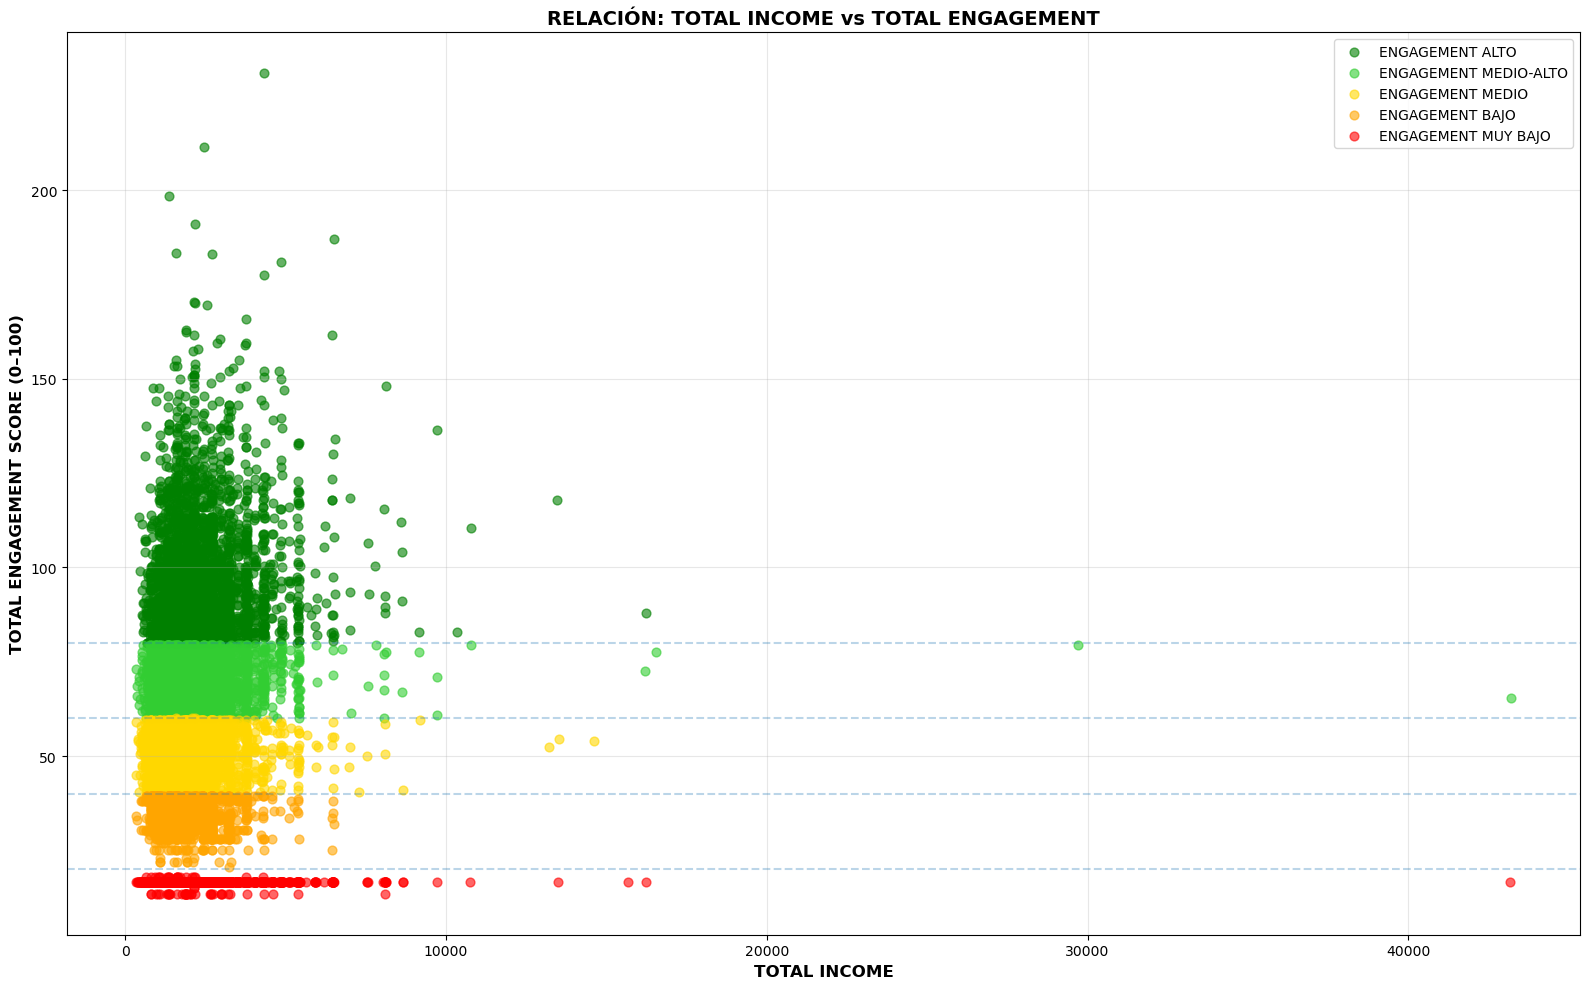

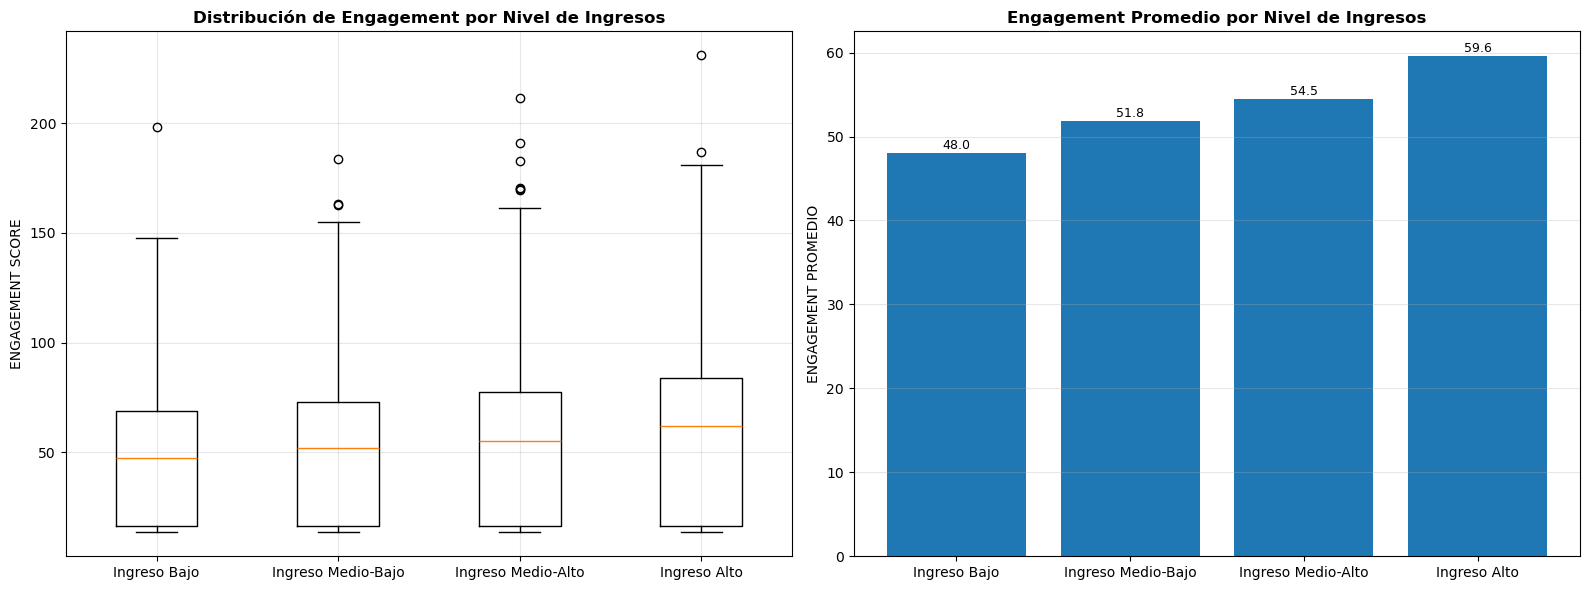


📊 ENGAGEMENT POR NIVEL DE INGRESOS
                    NUM_CLIENTES  ENGAGEMENT_PROM  ENGAGEMENT_STD  \
INCOME_SEGMENT                                                      
Ingreso Bajo                3808             48.0            28.1   
Ingreso Medio-Bajo          3665             51.8            30.6   
Ingreso Medio-Alto          3760             54.5            31.8   
Ingreso Alto                2424             59.6            34.7   

                    INGRESO_PROM  VARIEDAD_PROM  INTENSIDAD_PROM  HABITOS_PROM  
INCOME_SEGMENT                                                                  
Ingreso Bajo              1112.4           83.4             32.3          33.8  
Ingreso Medio-Bajo        1699.5           91.8             34.3          35.2  
Ingreso Medio-Alto        2375.3           97.7             36.1          35.7  
Ingreso Alto              3936.8          108.9             38.7          38.0  

✅ ANÁLISIS TOTAL_ENGAGEMENT vs TOTAL_INCOME COMPLETADO


In [16]:

from pyspark.sql import functions as F

print("="*100)
print("ANÁLISIS COMPLETO DE ENGAGEMENT DEL CLIENTE - 3 DIMENSIONES")
print("="*100)
print("Dimensiones: 1. Variedad de Uso | 2. Intensidad de Uso | 3. Hábitos Saludables")
print("="*100)

# ============================================================================
# PRIMERO: VERIFICAR QUE TENEMOS LOS DATOS NECESARIOS
# ============================================================================

print("\n1. VERIFICACIÓN DE DATOS DISPONIBLES")
print("-"*60)

# Verificar columnas disponibles en df_features
columnas_necesarias = [
    "CLIENT_ID",
    "CREDIT_CARD_DRAWINGS_ATM",
    "CREDIT_CARD_DRAWINGS_POS", 
    "CREDIT_CARD_DRAWINGS_OTHER",
    "CREDIT_CARD_DRAWINGS",
    "CREDIT_CARD_PAYMENT",
    "CREDICT_CARD_BALANCE",
    "CREDIT_CARD_LIMIT",
    "NUMBER_INSTALMENTS"
]

columnas_faltantes = [col for col in columnas_necesarias if col not in df_features.columns]

if columnas_faltantes:
    print(f"⚠️ ADVERTENCIA: Faltan columnas: {columnas_faltantes}")
    print("   El análisis puede estar incompleto.")
else:
    print("✅ Todas las columnas necesarias están disponibles")

print(f"\nTotal de registros en df_features: {df_features.count():,}")
print(f"Total de clientes únicos: {df_features.select('CLIENT_ID').distinct().count():,}")

# ============================================================================
# 1. ENGAGEMENT POR VARIEDAD DE USO
# ============================================================================

print("\n" + "="*100)
print("DIMENSIÓN 1: VARIEDAD DE USO")
print("(Mide cuántos tipos diferentes de servicios usa el cliente)")
print("="*100)

df_variedad = df_features.groupBy("CLIENT_ID").agg(
    # 1.1 Variedad de tipos de transacción (cuántos tipos diferentes usa)
    F.countDistinct(
        "CREDIT_CARD_DRAWINGS_ATM", 
        "CREDIT_CARD_DRAWINGS_POS", 
        "CREDIT_CARD_DRAWINGS_OTHER"
    ).alias("VARIEDAD_TIPO_TRANSACCION"),
    
    # 1.2 Uso de diferentes canales (ATM, POS, Otros)
    F.when(F.sum("CREDIT_CARD_DRAWINGS_ATM") > 0, 1).otherwise(0).alias("USA_ATM"),
    F.when(F.sum("CREDIT_CARD_DRAWINGS_POS") > 0, 1).otherwise(0).alias("USA_POS"),
    F.when(F.sum("CREDIT_CARD_DRAWINGS_OTHER") > 0, 1).otherwise(0).alias("USA_OTHER"),
    
    # 1.3 Profundidad de uso (monto promedio por transacción)
    F.avg("CREDIT_CARD_DRAWINGS").alias("MONTO_PROMEDIO_TRANSACCION"),
    
    # 1.4 Consistencia en pagos (qué % de su balance paga)
    F.when(F.sum("CREDICT_CARD_BALANCE") > 0,
           F.sum("CREDIT_CARD_PAYMENT") / F.sum("CREDICT_CARD_BALANCE"))
     .otherwise(0).alias("RATIO_PAGO_VS_BALANCE")
)

# Calcular Score de Variedad (0-100 puntos)
df_variedad = df_variedad.withColumn(
    "SCORE_VARIEDAD",
    # Puntos por variedad de tipos (máx 25 puntos)
    (F.col("VARIEDAD_TIPO_TRANSACCION") / 3 * 25) +  
    
    # Puntos por uso de diferentes canales (máx 25 puntos)
    ((F.col("USA_ATM") + F.col("USA_POS") + F.col("USA_OTHER")) * 25) +  
    
    # Puntos por monto promedio de transacción (máx 25 puntos)
    (F.when(F.col("MONTO_PROMEDIO_TRANSACCION") > 100, 25)
      .when(F.col("MONTO_PROMEDIO_TRANSACCION") > 50, 15)
      .when(F.col("MONTO_PROMEDIO_TRANSACCION") > 10, 5)
      .otherwise(0)) +  
    
    # Puntos por ratio de pago (máx 25 puntos)
    (F.when(F.col("RATIO_PAGO_VS_BALANCE") >= 0.8, 25)
      .when(F.col("RATIO_PAGO_VS_BALANCE") >= 0.5, 15)
      .when(F.col("RATIO_PAGO_VS_BALANCE") > 0, 5)
      .otherwise(0))
)

# Clasificar por nivel de variedad
df_variedad = df_variedad.withColumn(
    "NIVEL_VARIEDAD",
    F.when(F.col("SCORE_VARIEDAD") >= 75, "ALTA VARIEDAD")
     .when(F.col("SCORE_VARIEDAD") >= 50, "MEDIA VARIEDAD")
     .when(F.col("SCORE_VARIEDAD") >= 25, "BAJA VARIEDAD")
     .otherwise("SIN VARIEDAD")
)

print(f"✅ Variedad calculada para {df_variedad.count():,} clientes")

# ============================================================================
# 2. ENGAGEMENT POR INTENSIDAD DE USO
# ============================================================================

print("\n" + "="*100)
print("DIMENSIÓN 2: INTENSIDAD DE USO")
print("(Mide cuánto y cómo de intensamente usa los servicios)")
print("="*100)

df_intensidad = df_features.groupBy("CLIENT_ID").agg(
    # 2.1 Utilización del crédito disponible (% del límite usado)
    F.when(F.avg("CREDIT_CARD_LIMIT") > 0,
           F.avg("CREDICT_CARD_BALANCE") / F.avg("CREDIT_CARD_LIMIT"))
     .otherwise(0).alias("UTILIZACION_PROMEDIO"),
    
    # 2.2 Intensidad de transacciones (monto promedio por uso)
    F.avg("CREDIT_CARD_DRAWINGS").alias("MONTO_PROMEDIO_USO"),
    
    # 2.3 Comportamiento de pago (qué % del balance paga)
    F.when(F.sum("CREDICT_CARD_BALANCE") > 0,
           F.sum("CREDIT_CARD_PAYMENT") / F.sum("CREDICT_CARD_BALANCE"))
     .otherwise(0).alias("RATIO_PAGO"),
    
    # 2.4 Uso de pagos fraccionados
    F.when(F.count("*") > 0,
           F.sum("NUMBER_INSTALMENTS") / F.count("*"))
     .otherwise(0).alias("FRACCION_PAGOS_FRACCIONADOS")
)

# Calcular Score de Intensidad (0-100 puntos)
df_intensidad = df_intensidad.withColumn(
    "SCORE_INTENSIDAD",
    # Puntos por utilización óptima (30-70% es ideal) - máx 30 puntos
    F.when((F.col("UTILIZACION_PROMEDIO") >= 0.3) & (F.col("UTILIZACION_PROMEDIO") <= 0.7), 30)
     .when(F.col("UTILIZACION_PROMEDIO") > 0, 15)
     .otherwise(0) +
    
    # Puntos por monto promedio de uso - máx 30 puntos
    F.when(F.col("MONTO_PROMEDIO_USO") >= 500, 30)
     .when(F.col("MONTO_PROMEDIO_USO") >= 200, 20)
     .when(F.col("MONTO_PROMEDIO_USO") >= 50, 10)
     .otherwise(5) +
    
    # Puntos por ratio de pago saludable - máx 40 puntos
    F.when(F.col("RATIO_PAGO") >= 0.8, 40)
     .when(F.col("RATIO_PAGO") >= 0.5, 25)
     .when(F.col("RATIO_PAGO") > 0, 10)
     .otherwise(0)
)

# Clasificar por nivel de intensidad
df_intensidad = df_intensidad.withColumn(
    "NIVEL_INTENSIDAD",
    F.when(F.col("SCORE_INTENSIDAD") >= 80, "USO INTENSO")
     .when(F.col("SCORE_INTENSIDAD") >= 50, "USO MODERADO")
     .when(F.col("SCORE_INTENSIDAD") >= 20, "USO OCASIONAL")
     .otherwise("USO MÍNIMO")
)

print(f"✅ Intensidad calculada para {df_intensidad.count():,} clientes")

# ============================================================================
# 3. ENGAGEMENT POR HÁBITOS SALUDABLES
# ============================================================================

print("\n" + "="*100)
print("DIMENSIÓN 3: HÁBITOS SALUDABLES")
print("(Mide la salud financiera de los hábitos del cliente)")
print("="*100)

df_habitos = df_features.groupBy("CLIENT_ID").agg(
    # 3.1 Paga más del mínimo (% del balance que paga)
    F.when(F.avg("CREDICT_CARD_BALANCE") > 0,
           F.avg("CREDIT_CARD_PAYMENT") / F.avg("CREDICT_CARD_BALANCE"))
     .otherwise(0).alias("RATIO_PAGO_SOBRE_BALANCE"),
    
    # 3.2 No abusa del cash advance (% de uso en ATM)
    F.when(F.sum("CREDIT_CARD_DRAWINGS") > 0,
           F.sum("CREDIT_CARD_DRAWINGS_ATM") / F.sum("CREDIT_CARD_DRAWINGS"))
     .otherwise(0).alias("PORCENTAJE_USO_ATM"),
    
    # 3.3 Usa crédito para compras (% de uso en POS)
    F.when(F.sum("CREDIT_CARD_DRAWINGS") > 0,
           F.sum("CREDIT_CARD_DRAWINGS_POS") / F.sum("CREDIT_CARD_DRAWINGS"))
     .otherwise(0).alias("PORCENTAJE_USO_POS"),
    
    # 3.4 Mantiene balance manejable (% del límite usado)
    F.when(F.avg("CREDIT_CARD_LIMIT") > 0,
           F.avg("CREDICT_CARD_BALANCE") / F.avg("CREDIT_CARD_LIMIT"))
     .otherwise(0).alias("UTILIZACION_CREDITO"),
    
    # 3.5 No abusa de pagos fraccionados
    F.avg("NUMBER_INSTALMENTS").alias("PROMEDIO_INSTALMENTS")
)

# Calcular Score de Hábitos Saludables (0-100 puntos)
df_habitos = df_habitos.withColumn(
    "SCORE_HABITOS_SALUDABLES",
    # Puntos por buen ratio de pago - máx 30 puntos
    F.when(F.col("RATIO_PAGO_SOBRE_BALANCE") >= 0.8, 30)
     .when(F.col("RATIO_PAGO_SOBRE_BALANCE") >= 0.5, 20)
     .when(F.col("RATIO_PAGO_SOBRE_BALANCE") > 0.2, 10)
     .otherwise(0) +
    
    # Puntos por uso diversificado (no solo ATM) - máx 20 puntos
    F.when(F.col("PORCENTAJE_USO_ATM") < 0.3, 20)
     .when(F.col("PORCENTAJE_USO_ATM") < 0.6, 10)
     .otherwise(0) +
    
    # Puntos por uso para compras (POS) - máx 20 puntos
    F.when(F.col("PORCENTAJE_USO_POS") > 0.5, 20)
     .when(F.col("PORCENTAJE_USO_POS") > 0.2, 10)
     .otherwise(0) +
    
    # Puntos por utilización saludable (30-70%) - máx 20 puntos
    F.when((F.col("UTILIZACION_CREDITO") >= 0.3) & (F.col("UTILIZACION_CREDITO") <= 0.7), 20)
     .when(F.col("UTILIZACION_CREDITO") < 0.9, 10)
     .otherwise(0) +
    
    # Puntos por no abusar de pagos fraccionados - máx 10 puntos
    F.when(F.col("PROMEDIO_INSTALMENTS") < 2, 10)
     .when(F.col("PROMEDIO_INSTALMENTS") < 4, 5)
     .otherwise(0)
)

# Clasificar por nivel de hábitos
df_habitos = df_habitos.withColumn(
    "NIVEL_HABITOS",
    F.when(F.col("SCORE_HABITOS_SALUDABLES") >= 80, "HÁBITOS EXCELENTES")
     .when(F.col("SCORE_HABITOS_SALUDABLES") >= 60, "HÁBITOS BUENOS")
     .when(F.col("SCORE_HABITOS_SALUDABLES") >= 40, "HÁBITOS REGULARES")
     .otherwise("HÁBITOS A MEJORAR")
)

print(f"✅ Hábitos calculados para {df_habitos.count():,} clientes")

# ============================================================================
# 4. COMBINAR LOS 3 SCORES - ENGAGEMENT COMPLETO
# ============================================================================

print("\n" + "="*100)
print("COMBINACIÓN: ENGAGEMENT SCORE COMPLETO")
print("(Score total ponderado: 30% Variedad + 40% Intensidad + 30% Hábitos)")
print("="*100)

# Unir todos los DataFrames
df_engagement_completo = df_variedad.join(
    df_intensidad, on="CLIENT_ID", how="inner"
).join(
    df_habitos, on="CLIENT_ID", how="inner"
)

# Calcular Score Total (promedio ponderado)
df_engagement_completo = df_engagement_completo.withColumn(
    "ENGAGEMENT_SCORE_TOTAL",
    (F.col("SCORE_VARIEDAD") * 0.3) +    # 30% peso para Variedad
    (F.col("SCORE_INTENSIDAD") * 0.4) +  # 40% peso para Intensidad
    (F.col("SCORE_HABITOS_SALUDABLES") * 0.3)  # 30% peso para Hábitos
)

# Clasificar por nivel total de Engagement
df_engagement_completo = df_engagement_completo.withColumn(
    "NIVEL_ENGAGEMENT_TOTAL",
    F.when(F.col("ENGAGEMENT_SCORE_TOTAL") >= 80, "ENGAGEMENT ALTO")
     .when(F.col("ENGAGEMENT_SCORE_TOTAL") >= 60, "ENGAGEMENT MEDIO-ALTO")
     .when(F.col("ENGAGEMENT_SCORE_TOTAL") >= 40, "ENGAGEMENT MEDIO")
     .when(F.col("ENGAGEMENT_SCORE_TOTAL") >= 20, "ENGAGEMENT BAJO")
     .otherwise("ENGAGEMENT MUY BAJO")
)

# ============================================================================
# 5. RESULTADOS Y ESTADÍSTICAS
# ============================================================================

print("\n" + "="*100)
print("RESULTADOS FINALES")
print("="*100)

total_clientes = df_engagement_completo.count()
print(f"\n📊 TOTAL CLIENTES ANALIZADOS: {total_clientes:,}")

# ----------------------------------------------------------------------------
# 5.1 Distribución del Engagement Total
# ----------------------------------------------------------------------------

print("\n" + "-"*60)
print("1. DISTRIBUCIÓN DEL ENGAGEMENT TOTAL")
print("-"*60)

distribucion_total = []
for nivel in ["ENGAGEMENT ALTO", "ENGAGEMENT MEDIO-ALTO", "ENGAGEMENT MEDIO", 
              "ENGAGEMENT BAJO", "ENGAGEMENT MUY BAJO"]:
    count = df_engagement_completo.filter(F.col("NIVEL_ENGAGEMENT_TOTAL") == nivel).count()
    porcentaje = (count / total_clientes) * 100
    distribucion_total.append((nivel, count, porcentaje))
    print(f"   • {nivel}: {count:>6,} clientes ({porcentaje:5.1f}%)")

# ----------------------------------------------------------------------------
# 5.2 Distribución por cada Dimensión
# ----------------------------------------------------------------------------

print("\n" + "-"*60)
print("2. DISTRIBUCIÓN POR DIMENSIÓN")
print("-"*60)

print("\n   A. VARIEDAD DE USO:")
for nivel in ["ALTA VARIEDAD", "MEDIA VARIEDAD", "BAJA VARIEDAD", "SIN VARIEDAD"]:
    count = df_engagement_completo.filter(F.col("NIVEL_VARIEDAD") == nivel).count()
    print(f"      • {nivel}: {count:,}")

print("\n   B. INTENSIDAD DE USO:")
for nivel in ["USO INTENSO", "USO MODERADO", "USO OCASIONAL", "USO MÍNIMO"]:
    count = df_engagement_completo.filter(F.col("NIVEL_INTENSIDAD") == nivel).count()
    print(f"      • {nivel}: {count:,}")

print("\n   C. HÁBITOS SALUDABLES:")
for nivel in ["HÁBITOS EXCELENTES", "HÁBITOS BUENOS", "HÁBITOS REGULARES", "HÁBITOS A MEJORAR"]:
    count = df_engagement_completo.filter(F.col("NIVEL_HABITOS") == nivel).count()
    print(f"      • {nivel}: {count:,}")

# ----------------------------------------------------------------------------
# 5.3 Promedios de Scores
# ----------------------------------------------------------------------------

print("\n" + "-"*60)
print("3. PUNTUACIONES PROMEDIO")
print("-"*60)

stats = df_engagement_completo.agg(
    F.avg("ENGAGEMENT_SCORE_TOTAL").alias("PROMEDIO_TOTAL"),
    F.avg("SCORE_VARIEDAD").alias("PROMEDIO_VARIEDAD"),
    F.avg("SCORE_INTENSIDAD").alias("PROMEDIO_INTENSIDAD"),
    F.avg("SCORE_HABITOS_SALUDABLES").alias("PROMEDIO_HABITOS"),
    F.stddev("ENGAGEMENT_SCORE_TOTAL").alias("DESVIACION_TOTAL")
).collect()[0]

print(f"   • Engagement Total: {stats['PROMEDIO_TOTAL']:.1f}/100 (±{stats['DESVIACION_TOTAL']:.1f})")
print(f"   • Variedad: {stats['PROMEDIO_VARIEDAD']:.1f}/100")
print(f"   • Intensidad: {stats['PROMEDIO_INTENSIDAD']:.1f}/100")
print(f"   • Hábitos: {stats['PROMEDIO_HABITOS']:.1f}/100")

# ----------------------------------------------------------------------------
# 5.4 Top Clientes por cada Dimensión
# ----------------------------------------------------------------------------

print("\n" + "-"*60)
print("4. TOP CLIENTES POR DIMENSIÓN")
print("-"*60)

print("\n   🥇 MEJORES EN VARIEDAD:")
df_engagement_completo.select(
    "CLIENT_ID",
    "NIVEL_VARIEDAD",
    F.round(F.col("SCORE_VARIEDAD"), 1).alias("SCORE"),
    "VARIEDAD_TIPO_TRANSACCION"
).orderBy(F.desc("SCORE_VARIEDAD")).limit(3).show(truncate=False)

print("\n   🥇 MEJORES EN INTENSIDAD:")
df_engagement_completo.select(
    "CLIENT_ID",
    "NIVEL_INTENSIDAD",
    F.round(F.col("SCORE_INTENSIDAD"), 1).alias("SCORE"),
    F.round(F.col("MONTO_PROMEDIO_USO"), 2).alias("MONTO_PROM")
).orderBy(F.desc("SCORE_INTENSIDAD")).limit(3).show(truncate=False)

print("\n   🥇 MEJORES EN HÁBITOS:")
df_engagement_completo.select(
    "CLIENT_ID",
    "NIVEL_HABITOS",
    F.round(F.col("SCORE_HABITOS_SALUDABLES"), 1).alias("SCORE"),
    F.round(F.col("RATIO_PAGO_SOBRE_BALANCE") * 100, 1).alias("PAGO_%")
).orderBy(F.desc("SCORE_HABITOS_SALUDABLES")).limit(3).show(truncate=False)

# ----------------------------------------------------------------------------
# 5.5 Clientes Críticos (prioridad de acción)
# ----------------------------------------------------------------------------

print("\n" + "-"*60)
print("5. CLIENTES CRÍTICOS (PRIORIDAD)")
print("-"*60)

df_criticos = df_engagement_completo.filter(
    F.col("NIVEL_ENGAGEMENT_TOTAL").isin(["ENGAGEMENT MUY BAJO", "ENGAGEMENT BAJO"])
)

num_criticos = df_criticos.count()
print(f"\n   🔴 CLIENTES CRÍTICOS: {num_criticos:,} ({num_criticos/total_clientes*100:.1f}%)")

if num_criticos > 0:
    print("\n   Perfil típico del cliente crítico:")
    perfil_critico = df_criticos.agg(
        F.avg("SCORE_VARIEDAD").alias("VAR_PROM"),
        F.avg("SCORE_INTENSIDAD").alias("INT_PROM"),
        F.avg("SCORE_HABITOS_SALUDABLES").alias("HAB_PROM")
    ).collect()[0]
    
    print(f"      • Variedad: {perfil_critico['VAR_PROM']:.1f}/100")
    print(f"      • Intensidad: {perfil_critico['INT_PROM']:.1f}/100")
    print(f"      • Hábitos: {perfil_critico['HAB_PROM']:.1f}/100")
    
    print("\n   Ejemplos de clientes críticos:")
    df_criticos.select(
        "CLIENT_ID",
        "NIVEL_ENGAGEMENT_TOTAL",
        F.round(F.col("ENGAGEMENT_SCORE_TOTAL"), 1).alias("SCORE_TOTAL"),
        "NIVEL_VARIEDAD",
        "NIVEL_INTENSIDAD",
        "NIVEL_HABITOS"
    ).orderBy("ENGAGEMENT_SCORE_TOTAL").limit(5).show(truncate=False)

# ----------------------------------------------------------------------------
# 5.6 Clientes Excelentes (fidelizar)
# ----------------------------------------------------------------------------

print("\n" + "-"*60)
print("6. CLIENTES EXCELENTES (FIDELIZAR)")
print("-"*60)

df_excelentes = df_engagement_completo.filter(
    F.col("NIVEL_ENGAGEMENT_TOTAL").isin(["ENGAGEMENT ALTO", "ENGAGEMENT MEDIO-ALTO"])
)

num_excelentes = df_excelentes.count()
print(f"\n   🏆 CLIENTES EXCELENTES: {num_excelentes:,} ({num_excelentes/total_clientes*100:.1f}%)")

if num_excelentes > 0:
    print("\n   Perfil típico del cliente excelente:")
    perfil_excelente = df_excelentes.agg(
        F.avg("SCORE_VARIEDAD").alias("VAR_PROM"),
        F.avg("SCORE_INTENSIDAD").alias("INT_PROM"),
        F.avg("SCORE_HABITOS_SALUDABLES").alias("HAB_PROM")
    ).collect()[0]
    
    print(f"      • Variedad: {perfil_excelente['VAR_PROM']:.1f}/100")
    print(f"      • Intensidad: {perfil_excelente['INT_PROM']:.1f}/100")
    print(f"      • Hábitos: {perfil_excelente['HAB_PROM']:.1f}/100")
    
    print("\n   Top 3 clientes excelentes:")
    df_excelentes.select(
        "CLIENT_ID",
        "NIVEL_ENGAGEMENT_TOTAL",
        F.round(F.col("ENGAGEMENT_SCORE_TOTAL"), 1).alias("SCORE_TOTAL"),
        "NIVEL_VARIEDAD",
        "NIVEL_INTENSIDAD",
        "NIVEL_HABITOS"
    ).orderBy(F.desc("ENGAGEMENT_SCORE_TOTAL")).limit(3).show(truncate=False)

# ============================================================================
# 6. RECOMENDACIONES DE ACCIÓN
# ============================================================================

print("\n" + "="*100)
print("RECOMENDACIONES DE ACCIÓN POR SEGMENTO")
print("="*100)

print("\n📋 RESUMEN DE SEGMENTACIÓN:")
print(f"   • Total clientes: {total_clientes:,}")
print(f"   • Excelentes (fidelizar): {num_excelentes:,} ({num_excelentes/total_clientes*100:.1f}%)")
print(f"   • Críticos (acción urgente): {num_criticos:,} ({num_criticos/total_clientes*100:.1f}%)")
print(f"   • Relación Excelente:Crítico = 1:{num_criticos/num_excelentes:.1f}")

print("\n🎯 ACCIONES RECOMENDADAS:")

print("\n   1. PARA CLIENTES CON VARIEDAD BAJA:")
print("      • Ofertar nuevos productos/servicios")
print("      • Campañas cross-selling")
print("      • Bonos por uso de múltiples servicios")

print("\n   2. PARA CLIENTES CON INTENSIDAD BAJA:")
print("      • Programas de recompensas por uso frecuente")
print("      • Límites de crédito progresivos")
print("      • Recordatorios de uso periódico")

print("\n   3. PARA CLIENTES CON HÁBITOS A MEJORAR:")
print("      • Educación financiera")
print("      • Alertas de uso responsable")
print("      • Asesoramiento personalizado")

print("\n   4. PARA CLIENTES EXCELENTES:")
print("      • Programas de fidelización premium")
print("      • Tarifas preferenciales")
print("      • Acceso anticipado a nuevos productos")


print("\n" + "="*100)
print("ANÁLISIS COMPLETADO ✅")
print(f"Clientes analizados: {total_clientes:,}")
print(f"Tiempo estimado de retención: {(num_excelentes/total_clientes*100):.1f}% excelentes")
print(f"Riesgo de abandono: {(num_criticos/total_clientes*100):.1f}% críticos")
print("="*100)


from pyspark.sql import functions as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from itertools import chain
from pyspark.sql.functions import create_map

# =============================================================================
# CONFIGURACIÓN CORRECTA
# =============================================================================

CLIENT_ID_COL = "CLIENT_ID"
PRODUCT_COLUMN = "NAME_PRODUCT_TYPE"   # ✅ COLUMNA CORRECTA DEL CSV
TOTAL_INCOME = "TOTAL_INCOME"

print("="*100)
print("ANÁLISIS COMPLETO DE ENGAGEMENT DEL CLIENTE - 3 DIMENSIONES")
print("="*100)

# =============================================================================
# CARGA DE CLIENTS
# =============================================================================

df_clients = clientes_df

print("✅ CLIENTS cargado correctamente")
print(df_clients.columns)

# =============================================================================
# UNIÓN ENGAGEMENT + PRODUCTO
# =============================================================================

df_grafica_productos = df_engagement_completo.join(
    df_clients.select(
        F.col(CLIENT_ID_COL),
        F.col(PRODUCT_COLUMN).alias("PRODUCT_TYPE"),
        F.col(TOTAL_INCOME)
    ),
    on=CLIENT_ID_COL,
    how="inner"
)

print(f"Clientes con producto asignado: {df_grafica_productos.count():,}")

# =============================================================================
# CONVERTIR PRODUCT_TYPE A NUMÉRICO
# =============================================================================

product_freq = (
    df_grafica_productos
    .groupBy("PRODUCT_TYPE")
    .count()
    .orderBy(F.desc("count"))
)

product_list = [r["PRODUCT_TYPE"] for r in product_freq.collect()]
product_mapping = {p: i for i, p in enumerate(product_list)}

mapping_expr = create_map([F.lit(x) for x in chain(*product_mapping.items())])

df_grafica_productos = df_grafica_productos.withColumn(
    "PRODUCT_TYPE_NUM",
    mapping_expr[F.col("PRODUCT_TYPE")]
)

# =============================================================================
# PASAR A PANDAS (MUESTRA SI ES GRANDE)
# =============================================================================

n = df_grafica_productos.count()

df_pandas = (
    df_grafica_productos.sample(0.3).toPandas()
    if n > 30000 else
    df_grafica_productos.toPandas()
)

# =============================================================================
# SCATTER: TOTAL_INCOME vs TOTAL_ENGAGEMENT
# =============================================================================

plt.figure(figsize=(16, 10))

colors = {
    'ENGAGEMENT ALTO': 'green',
    'ENGAGEMENT MEDIO-ALTO': 'limegreen',
    'ENGAGEMENT MEDIO': 'gold',
    'ENGAGEMENT BAJO': 'orange',
    'ENGAGEMENT MUY BAJO': 'red'
}

# Evitar problemas si hay incomes muy concentrados
np.random.seed(42)
df_pandas["INCOME_JITTER"] = (
    df_pandas["TOTAL_INCOME"]
    + np.random.normal(0, df_pandas["TOTAL_INCOME"].std() * 0.02, len(df_pandas))
)

for nivel, color in colors.items():
    subset = df_pandas[df_pandas["NIVEL_ENGAGEMENT_TOTAL"] == nivel]
    plt.scatter(
        subset["INCOME_JITTER"],
        subset["ENGAGEMENT_SCORE_TOTAL"],
        alpha=0.6,
        s=40,
        c=color,
        label=nivel
    )

# Líneas de referencia de engagement
plt.axhline(80, linestyle="--", alpha=0.3)
plt.axhline(60, linestyle="--", alpha=0.3)
plt.axhline(40, linestyle="--", alpha=0.3)
plt.axhline(20, linestyle="--", alpha=0.3)

plt.xlabel("TOTAL INCOME", fontsize=12, fontweight="bold")
plt.ylabel("TOTAL ENGAGEMENT SCORE (0–100)", fontsize=12, fontweight="bold")
plt.title("RELACIÓN: TOTAL INCOME vs TOTAL ENGAGEMENT", fontsize=14, fontweight="bold")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================================
# BOXPLOT + BARRAS POR TRAMOS DE INGRESOS
# =============================================================================

# Crear tramos de ingresos (quartiles)
df_pandas["INCOME_SEGMENT"] = pd.qcut(
    df_pandas["TOTAL_INCOME"],
    q=4,
    labels=["Ingreso Bajo", "Ingreso Medio-Bajo", "Ingreso Medio-Alto", "Ingreso Alto"]
)

# Engagement promedio por tramo
income_engagement_avg = (
    df_pandas
    .groupby("INCOME_SEGMENT")["ENGAGEMENT_SCORE_TOTAL"]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BOXPLOT
axes[0].boxplot(
    [df_pandas[df_pandas["INCOME_SEGMENT"] == seg]["ENGAGEMENT_SCORE_TOTAL"]
     for seg in income_engagement_avg.index],
    labels=income_engagement_avg.index
)
axes[0].set_title("Distribución de Engagement por Nivel de Ingresos", fontweight="bold")
axes[0].set_ylabel("ENGAGEMENT SCORE")
axes[0].grid(alpha=0.3)

# BARRAS
axes[1].bar(
    income_engagement_avg.index,
    income_engagement_avg.values
)
axes[1].set_title("Engagement Promedio por Nivel de Ingresos", fontweight="bold")
axes[1].set_ylabel("ENGAGEMENT PROMEDIO")
axes[1].grid(alpha=0.3, axis="y")

# Valores en barras
for i, v in enumerate(income_engagement_avg.values):
    axes[1].text(i, v + 0.5, f"{v:.1f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# =============================================================================
# ANÁLISIS TABULAR: ENGAGEMENT VS INGRESOS
# =============================================================================

income_stats = (
    df_pandas
    .groupby("INCOME_SEGMENT")
    .agg(
        NUM_CLIENTES=("ENGAGEMENT_SCORE_TOTAL", "count"),
        ENGAGEMENT_PROM=("ENGAGEMENT_SCORE_TOTAL", "mean"),
        ENGAGEMENT_STD=("ENGAGEMENT_SCORE_TOTAL", "std"),
        INGRESO_PROM=("TOTAL_INCOME", "mean"),
        VARIEDAD_PROM=("SCORE_VARIEDAD", "mean"),
        INTENSIDAD_PROM=("SCORE_INTENSIDAD", "mean"),
        HABITOS_PROM=("SCORE_HABITOS_SALUDABLES", "mean")
    )
    .round(1)
)

print("\n📊 ENGAGEMENT POR NIVEL DE INGRESOS")
print(income_stats)

# =============================================================================
# EXPORTACIÓN
# =============================================================================

df_pandas.to_csv("engagement_vs_income.csv", index=False)
income_stats.to_csv("estadisticas_engagement_income.csv")

print("\n✅ ANÁLISIS TOTAL_ENGAGEMENT vs TOTAL_INCOME COMPLETADO")



# IET: Indice de Estabilidad de Ingresos

In [ ]:
behavioural_df.filter(F.col("CLIENT_ID")=="ES182142688D").orderBy("DATE").show()
clientes_df.filter(F.col("CLIENT_ID")=="ES182142688D").show()

+------------------+------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+
|       CONTRACT_ID|   CLIENT_ID|      DATE|CREDICT_CARD_BALANCE|CREDIT_CARD_LIMIT|CREDIT_CARD_DRAWINGS_ATM|CREDIT_CARD_DRAWINGS|CREDIT_CARD_DRAWINGS_POS|CREDIT_CARD_DRAWINGS_OTHER|CREDIT_CARD_PAYMENT|NUMBER_DRAWINGS_ATM|NUMBER_DRAWINGS|NUMBER_INSTALMENTS|
+------------------+------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+
|ES1821770118g00XXX|ES182142688D|2017-06-01|             1596.81|           1620.0|                  1620.0|              1620.0|                     0.0|                       0.0|              162.0|                4.0|        

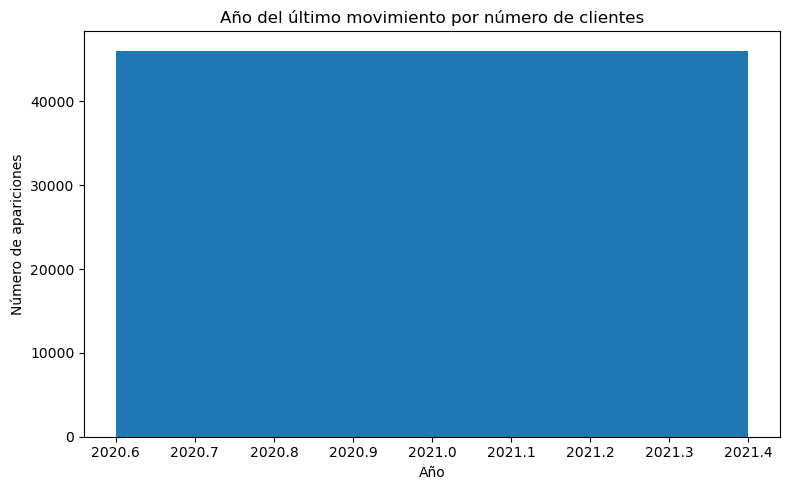

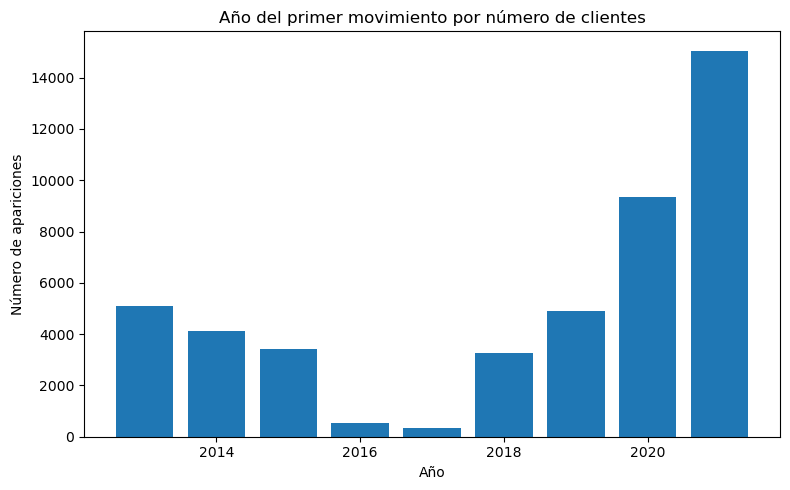

In [ ]:
#Año del primer movimiento y año del último movimiento de cada cliente

w_orderClients_lastMove = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
df_filterd_lastMove = behavioural_df.withColumn("row_num", F.row_number().over(w_orderClients_lastMove)).filter(F.col("row_num")==1).drop("row_num")
df_count_lastMove = df_filterd_lastMove.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")
pdf_lastMove = df_count_lastMove.toPandas()

w_orderClients_firstMove = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").asc())
df_filterd_firstMove = behavioural_df.withColumn("row_num", F.row_number().over(w_orderClients_firstMove)).filter(F.col("row_num")==1).drop("row_num")
df_count_firstMove = df_filterd_firstMove.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")
pdf_firstMove = df_count_firstMove.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf_lastMove["YEAR"], pdf_lastMove["count"])   # ❗ No se especifican colores
plt.xlabel("Año")
plt.ylabel("Número de apariciones")
plt.title("Año del último movimiento por número de clientes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(pdf_firstMove["YEAR"], pdf_firstMove["count"])   # ❗ No se especifican colores
plt.xlabel("Año")
plt.ylabel("Número de apariciones")
plt.title("Año del primer movimiento por número de clientes")
plt.tight_layout()
plt.show()

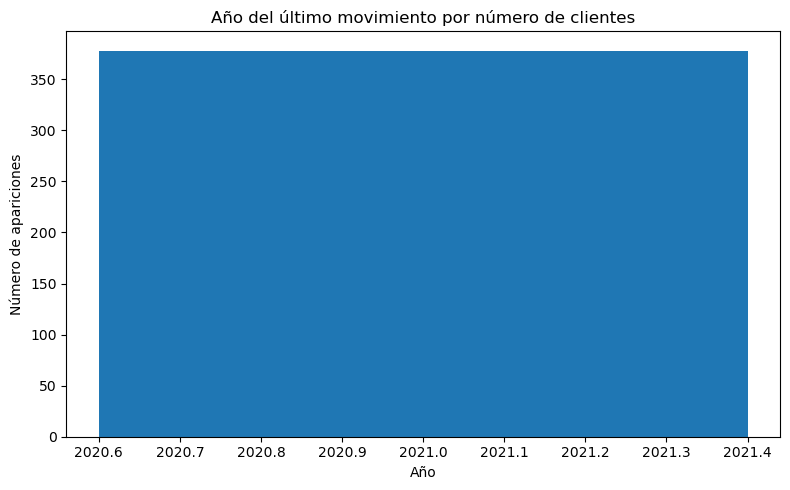

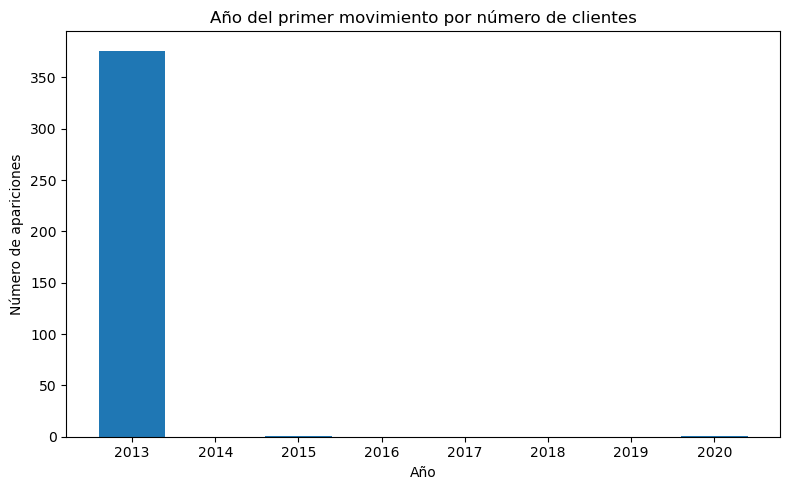

In [ ]:
#Año del primer movimiento y año del último movimiento de cada cliente

w_orderClients_lastMove = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
df_filterd_lastMove = only_behavioural_df.withColumn("row_num", F.row_number().over(w_orderClients_lastMove)).filter(F.col("row_num")==1).drop("row_num")
df_count_lastMove = df_filterd_lastMove.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")
pdf_lastMove = df_count_lastMove.toPandas()

w_orderClients_firstMove = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").asc())
df_filterd_firstMove = only_behavioural_df.withColumn("row_num", F.row_number().over(w_orderClients_firstMove)).filter(F.col("row_num")==1).drop("row_num")
df_count_firstMove = df_filterd_firstMove.withColumn("YEAR", F.year("DATE")).groupBy("YEAR").count().orderBy("YEAR")
pdf_firstMove = df_count_firstMove.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf_lastMove["YEAR"], pdf_lastMove["count"])   # ❗ No se especifican colores
plt.xlabel("Año")
plt.ylabel("Número de apariciones")
plt.title("Año del último movimiento por número de clientes")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(pdf_firstMove["YEAR"], pdf_firstMove["count"])   # ❗ No se especifican colores
plt.xlabel("Año")
plt.ylabel("Número de apariciones")
plt.title("Año del primer movimiento por número de clientes")
plt.tight_layout()
plt.show()

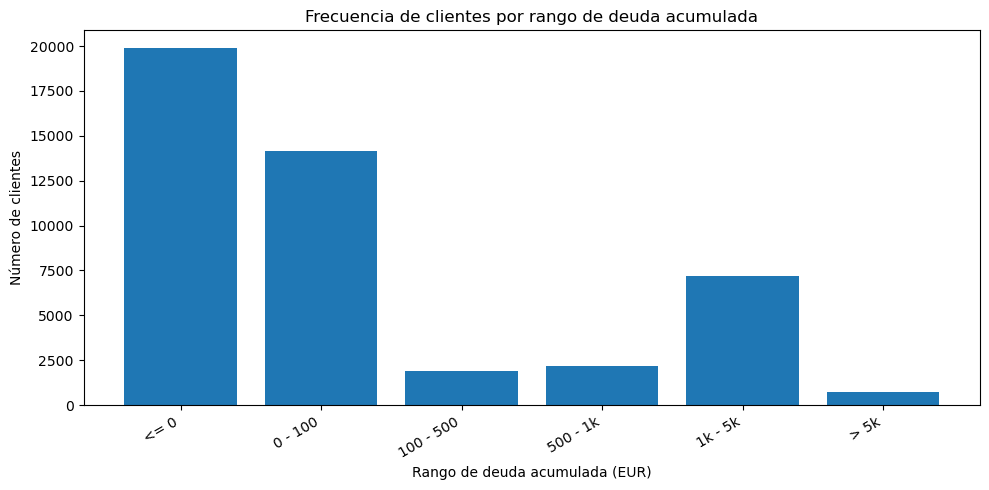

In [ ]:
# 1) Ventanas
w = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w1 = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# 2) Calcular DEBT y DEBT_CUMULED
df_con_deuda = behavioural_df \
    .withColumn("DATE", F.to_date("DATE", "dd/MM/yyyy")) \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))

# 3) Quedarnos con el registro más reciente por cliente (deuda acumulada "actual")
df_ultimos_por_cliente = df_con_deuda \
    .withColumn("row_num", F.row_number().over(w1)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")

# 4) Elegir bins (rangos). Ajusta estos límites según la dispersión de tus datos.
#    Ejemplo: cubrir desde deudas negativas (saldo a favor) hasta grandes deudas
bins = [-1e12, 0.0, 100.0, 500.0, 1000.0, 5000.0, 1e12]  # cambia si quieres otros cortes
labels = [
    "<= 0",
    "0 - 100",
    "100 - 500",
    "500 - 1k",
    "1k - 5k",
    "> 5k"
]

# 5) Usar Bucketizer para asignar cada cliente a un bin
from pyspark.ml.feature import Bucketizer
bucketizer = Bucketizer(splits=bins, inputCol="DEBT_CUMULED", outputCol="debt_bin_index")
df_binned = bucketizer.transform(df_ultimos_por_cliente)

# 6) Contar clientes por bin
df_bins_count = df_binned.groupBy("debt_bin_index").count().orderBy("debt_bin_index")

# 7) Convertir a pandas y mapear etiquetas
pdf_bins = df_bins_count.toPandas()
# Aseguramos que aparecen todos los índices (si algún bin quedó vacío puede no aparecer)
import numpy as np
all_idx = np.arange(len(labels))
pdf_full = pd.DataFrame({"debt_bin_index": all_idx})
pdf_bins = pdf_full.merge(pdf_bins, on="debt_bin_index", how="left").fillna(0)
pdf_bins["label"] = [labels[int(i)] for i in pdf_bins["debt_bin_index"]]
pdf_bins["count"] = pdf_bins["count"].astype(int)

# 8) Gráfico: barras (eje X = rango deuda, eje Y = número de clientes)
plt.figure(figsize=(10,5))
plt.bar(pdf_bins["label"], pdf_bins["count"])   # no especificamos colores
plt.xlabel("Rango de deuda acumulada (EUR)")
plt.ylabel("Número de clientes")
plt.title("Frecuencia de clientes por rango de deuda acumulada")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

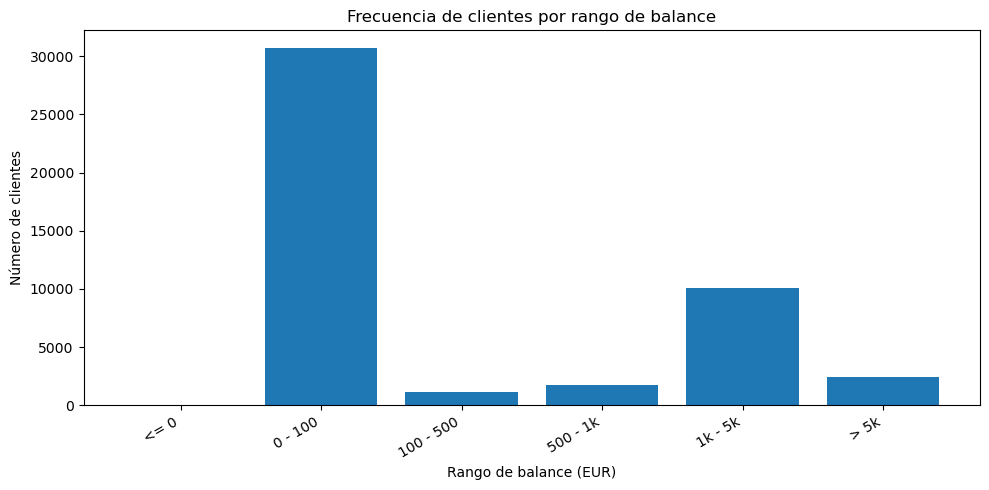

In [ ]:
# 1) Ventanas
w = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w1 = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# 2) Calcular DEBT y DEBT_CUMULED
df_con_deuda = behavioural_df \
    .withColumn("DATE", F.to_date("DATE", "dd/MM/yyyy")) \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))

# 3) Quedarnos con el registro más reciente por cliente (deuda acumulada "actual")
df_ultimos_por_cliente = df_con_deuda \
    .withColumn("row_num", F.row_number().over(w1)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")

# 4) Elegir bins (rangos). Ajusta estos límites según la dispersión de tus datos.
#    Ejemplo: cubrir desde deudas negativas (saldo a favor) hasta grandes deudas
bins = [-1e12, 0.0, 100.0, 500.0, 1000.0, 5000.0, 1e12]  # cambia si quieres otros cortes
labels = [
    "<= 0",
    "0 - 100",
    "100 - 500",
    "500 - 1k",
    "1k - 5k",
    "> 5k"
]

# 5) Usar Bucketizer para asignar cada cliente a un bin
from pyspark.ml.feature import Bucketizer
bucketizer = Bucketizer(splits=bins, inputCol="CREDICT_CARD_BALANCE", outputCol="debt_bin_index")
df_binned = bucketizer.transform(df_ultimos_por_cliente)

# 6) Contar clientes por bin
df_bins_count = df_binned.groupBy("debt_bin_index").count().orderBy("debt_bin_index")

# 7) Convertir a pandas y mapear etiquetas
pdf_bins = df_bins_count.toPandas()
# Aseguramos que aparecen todos los índices (si algún bin quedó vacío puede no aparecer)
import numpy as np
all_idx = np.arange(len(labels))
pdf_full = pd.DataFrame({"debt_bin_index": all_idx})
pdf_bins = pdf_full.merge(pdf_bins, on="debt_bin_index", how="left").fillna(0)
pdf_bins["label"] = [labels[int(i)] for i in pdf_bins["debt_bin_index"]]
pdf_bins["count"] = pdf_bins["count"].astype(int)

# 8) Gráfico: barras (eje X = rango deuda, eje Y = número de clientes)
plt.figure(figsize=(10,5))
plt.bar(pdf_bins["label"], pdf_bins["count"])   # no especificamos colores
plt.xlabel("Rango de balance (EUR)")
plt.ylabel("Número de clientes")
plt.title("Frecuencia de clientes por rango de balance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

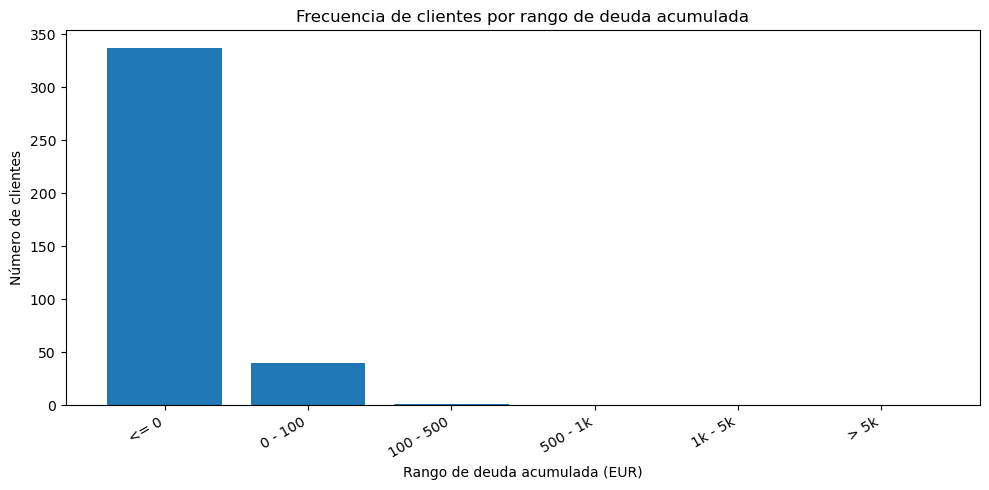

In [ ]:
# 1) Ventanas
w = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w1 = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# 2) Calcular DEBT y DEBT_CUMULED
df_con_deuda = only_behavioural_df \
    .withColumn("DATE", F.to_date("DATE", "dd/MM/yyyy")) \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))

# 3) Quedarnos con el registro más reciente por cliente (deuda acumulada "actual")
df_ultimos_por_cliente = df_con_deuda \
    .withColumn("row_num", F.row_number().over(w1)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")

# 4) Elegir bins (rangos). Ajusta estos límites según la dispersión de tus datos.
#    Ejemplo: cubrir desde deudas negativas (saldo a favor) hasta grandes deudas
bins = [-1e12, 0.0, 100.0, 500.0, 1000.0, 5000.0, 1e12]  # cambia si quieres otros cortes
labels = [
    "<= 0",
    "0 - 100",
    "100 - 500",
    "500 - 1k",
    "1k - 5k",
    "> 5k"
]

# 5) Usar Bucketizer para asignar cada cliente a un bin
from pyspark.ml.feature import Bucketizer
bucketizer = Bucketizer(splits=bins, inputCol="DEBT_CUMULED", outputCol="debt_bin_index")
df_binned = bucketizer.transform(df_ultimos_por_cliente)

# 6) Contar clientes por bin
df_bins_count = df_binned.groupBy("debt_bin_index").count().orderBy("debt_bin_index")

# 7) Convertir a pandas y mapear etiquetas
pdf_bins = df_bins_count.toPandas()
# Aseguramos que aparecen todos los índices (si algún bin quedó vacío puede no aparecer)
import numpy as np
all_idx = np.arange(len(labels))
pdf_full = pd.DataFrame({"debt_bin_index": all_idx})
pdf_bins = pdf_full.merge(pdf_bins, on="debt_bin_index", how="left").fillna(0)
pdf_bins["label"] = [labels[int(i)] for i in pdf_bins["debt_bin_index"]]
pdf_bins["count"] = pdf_bins["count"].astype(int)

# 8) Gráfico: barras (eje X = rango deuda, eje Y = número de clientes)
plt.figure(figsize=(10,5))
plt.bar(pdf_bins["label"], pdf_bins["count"])   # no especificamos colores
plt.xlabel("Rango de deuda acumulada (EUR)")
plt.ylabel("Número de clientes")
plt.title("Frecuencia de clientes por rango de deuda acumulada")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

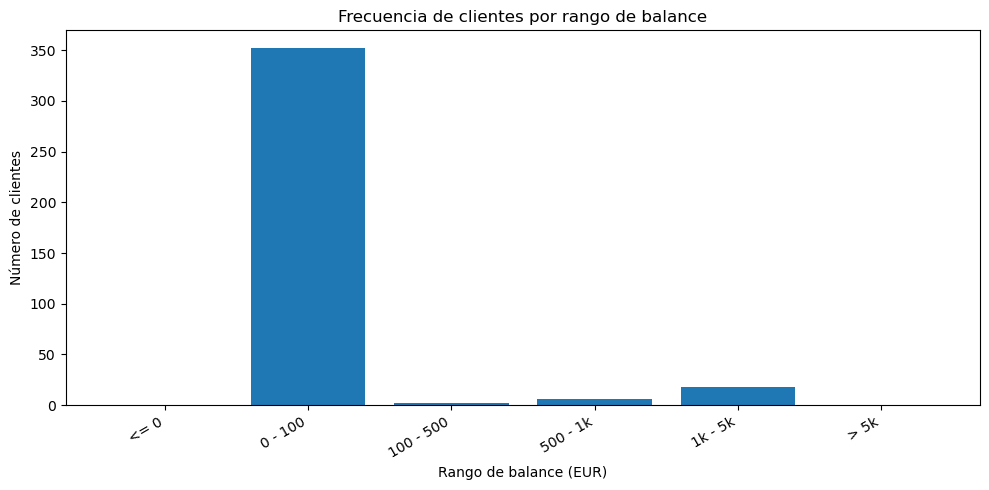

In [ ]:
# 1) Ventanas
w = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w1 = Window.partitionBy("CLIENT_ID").orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# 2) Calcular DEBT y DEBT_CUMULED
df_con_deuda = only_behavioural_df \
    .withColumn("DATE", F.to_date("DATE", "dd/MM/yyyy")) \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))

# 3) Quedarnos con el registro más reciente por cliente (deuda acumulada "actual")
df_ultimos_por_cliente = df_con_deuda \
    .withColumn("row_num", F.row_number().over(w1)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")

# 4) Elegir bins (rangos). Ajusta estos límites según la dispersión de tus datos.
#    Ejemplo: cubrir desde deudas negativas (saldo a favor) hasta grandes deudas
bins = [-1e12, 0.0, 100.0, 500.0, 1000.0, 5000.0, 1e12]  # cambia si quieres otros cortes
labels = [
    "<= 0",
    "0 - 100",
    "100 - 500",
    "500 - 1k",
    "1k - 5k",
    "> 5k"
]

# 5) Usar Bucketizer para asignar cada cliente a un bin
from pyspark.ml.feature import Bucketizer
bucketizer = Bucketizer(splits=bins, inputCol="CREDICT_CARD_BALANCE", outputCol="debt_bin_index")
df_binned = bucketizer.transform(df_ultimos_por_cliente)

# 6) Contar clientes por bin
df_bins_count = df_binned.groupBy("debt_bin_index").count().orderBy("debt_bin_index")

# 7) Convertir a pandas y mapear etiquetas
pdf_bins = df_bins_count.toPandas()
# Aseguramos que aparecen todos los índices (si algún bin quedó vacío puede no aparecer)
import numpy as np
all_idx = np.arange(len(labels))
pdf_full = pd.DataFrame({"debt_bin_index": all_idx})
pdf_bins = pdf_full.merge(pdf_bins, on="debt_bin_index", how="left").fillna(0)
pdf_bins["label"] = [labels[int(i)] for i in pdf_bins["debt_bin_index"]]
pdf_bins["count"] = pdf_bins["count"].astype(int)

# 8) Gráfico: barras (eje X = rango deuda, eje Y = número de clientes)
plt.figure(figsize=(10,5))
plt.bar(pdf_bins["label"], pdf_bins["count"])   # no especificamos colores
plt.xlabel("Rango de balance (EUR)")
plt.ylabel("Número de clientes")
plt.title("Frecuencia de clientes por rango de balance")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

+------------+------------+-------------------+---------------------+---------------------+-----------+
|CLIENT_ID   |TOTAL_INCOME|DEBT_CUMULED       |NET_INCOME_AFTER_DEBT|DEBT_TO_INCOME       |RISK_BUCKET|
+------------+------------+-------------------+---------------------+---------------------+-----------+
|ES182100023A|1080.0      |0.0                |1080.0               |0.0                  |LOW        |
|ES182100162C|1350.0      |0.0                |1350.0               |0.0                  |LOW        |
|ES182100299W|1350.0      |0.0                |1350.0               |0.0                  |LOW        |
|ES182100338P|3240.0      |304.1299999999992  |2935.870000000001    |0.09386728395061704  |LOW        |
|ES182100339K|1998.0      |-5776.389999999996 |7774.389999999996    |-2.891086086086084   |LOW        |
|ES182100468L|1350.0      |-1403.53           |2753.5299999999997   |-1.0396518518518518  |LOW        |
|ES182100491G|2322.0      |350.6700000000001  |1971.33          

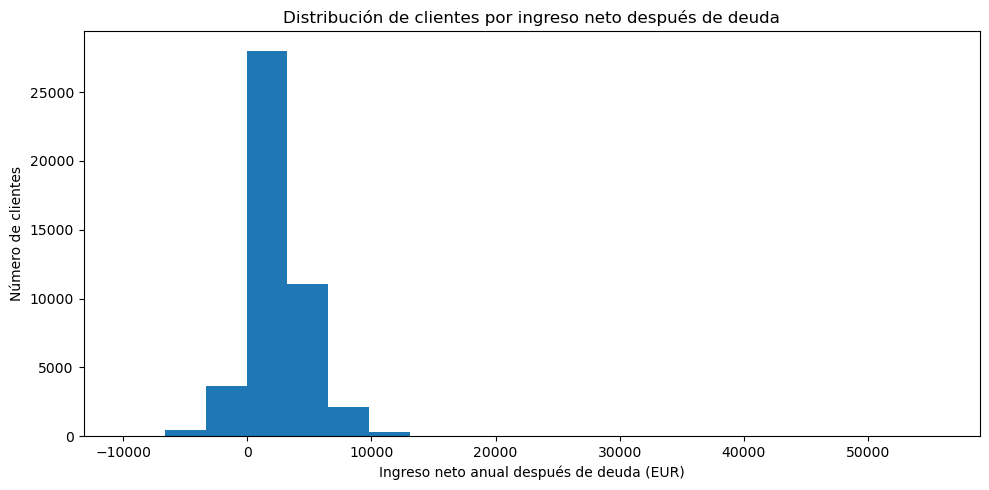

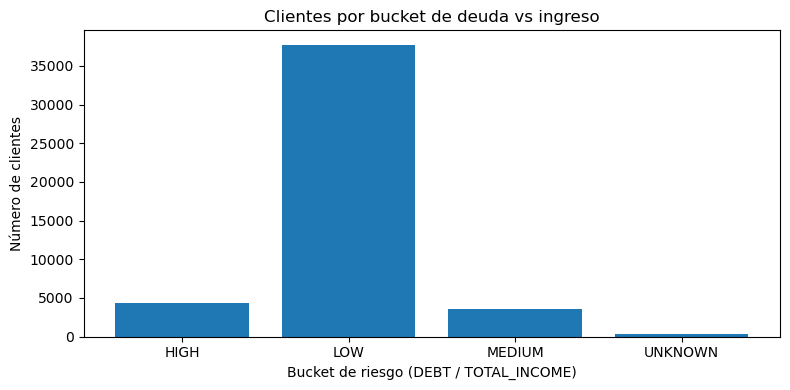

In [ ]:
# --- 1) Ventanas
w_acc = Window.partitionBy("CLIENT_ID") \
              .orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
              .rowsBetween(Window.unboundedPreceding, Window.currentRow)

w_last = Window.partitionBy("CLIENT_ID") \
               .orderBy(F.to_date("DATE", "dd/MM/yyyy").desc())

# --- 2) Calcular DEBT por fila y DEBT_CUMULED
df_debt = behavioural_df.withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
            .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w_acc))

# --- 3) Obtener el registro más reciente por cliente (para tener la deuda acumulada "actual")
df_latest = df_debt.withColumn("row_num", F.row_number().over(w_last)) \
                   .filter(F.col("row_num") == 1) \
                   .drop("row_num")

# --- 4) Obtener TOTAL_INCOME por CLIENT_ID
# Opción A: si TOTAL_INCOME ya está en behavioural_df (por ejemplo repetido en cada fila)
# usamos max (o avg) para extraer el valor por cliente:
# Si tienes un DataFrame aparte con TOTAL_INCOME, coméntalo:
income_df = clientes_df.select("CLIENT_ID", "TOTAL_INCOME")

# --- 5) Unir deuda actual con ingresos
df_join = df_latest.join(income_df, on="CLIENT_ID", how="left")

# --- 6) Calcular métricas: neto, ratio y categoría (evitando división por cero / nulos)
df_result = df_join.withColumn(
    "NET_INCOME_AFTER_DEBT",
    F.col("TOTAL_INCOME") - F.col("DEBT_CUMULED")
).withColumn(
    "DEBT_TO_INCOME",
    F.when(
        (F.col("TOTAL_INCOME").isNull()) | (F.col("TOTAL_INCOME") == 0),
        None
    ).otherwise(F.col("DEBT_CUMULED") / F.col("TOTAL_INCOME"))
).withColumn(
    "RISK_BUCKET",
    F.when(F.col("DEBT_TO_INCOME").isNull(), "UNKNOWN")
     .when(F.col("DEBT_TO_INCOME") <= 0.5, "LOW")
     .when((F.col("DEBT_TO_INCOME") > 0.5) & (F.col("DEBT_TO_INCOME") <= 1.0), "MEDIUM")
     .when(F.col("DEBT_TO_INCOME") > 1.0, "HIGH")
     .otherwise("UNKNOWN")
)

# Mostrar ejemplo
df_result.select("CLIENT_ID", "TOTAL_INCOME", "DEBT_CUMULED", "NET_INCOME_AFTER_DEBT",
                 "DEBT_TO_INCOME", "RISK_BUCKET").show(20, False)

# --- 7) Agregados útiles: conteo por bucket
df_buckets = df_result.groupBy("RISK_BUCKET").count().orderBy("RISK_BUCKET")
df_buckets.show()

# --- 8) Convertir a pandas para graficar la distribución de NET_INCOME_AFTER_DEBT (histograma por rangos)
pdf = df_result.select("CLIENT_ID", "NET_INCOME_AFTER_DEBT").toPandas()

# Si hay NaNs, puedes limpiarlos o imputarlos; aquí los quitamos para el histograma:
pdf_plot = pdf.dropna(subset=["NET_INCOME_AFTER_DEBT"])

# Histograma con matplotlib (bins ajustables)
plt.figure(figsize=(10,5))
plt.hist(pdf_plot["NET_INCOME_AFTER_DEBT"], bins=20)   # no se especifican colores
plt.xlabel("Ingreso neto anual después de deuda (EUR)")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por ingreso neto después de deuda")
plt.tight_layout()
plt.show()

# --- 9) También: gráfico de barras del RISK_BUCKET
pdf_buckets = df_buckets.toPandas()
plt.figure(figsize=(8,4))
plt.bar(pdf_buckets["RISK_BUCKET"], pdf_buckets["count"])
plt.xlabel("Bucket de riesgo (DEBT / TOTAL_INCOME)")
plt.ylabel("Número de clientes")
plt.title("Clientes por bucket de deuda vs ingreso")
plt.tight_layout()
plt.show()

+------------------+------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+------------------+------------------+
|       CONTRACT_ID|   CLIENT_ID|      DATE|CREDICT_CARD_BALANCE|CREDIT_CARD_LIMIT|CREDIT_CARD_DRAWINGS_ATM|CREDIT_CARD_DRAWINGS|CREDIT_CARD_DRAWINGS_POS|CREDIT_CARD_DRAWINGS_OTHER|CREDIT_CARD_PAYMENT|NUMBER_DRAWINGS_ATM|NUMBER_DRAWINGS|NUMBER_INSTALMENTS|       UTILIZATION|          UTIL_avg|
+------------------+------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+------------------+------------------+
|ES1821999597r00XXX|ES182155492Z|2021-12-31|             4617.29|           1890.0|                     0.0|       

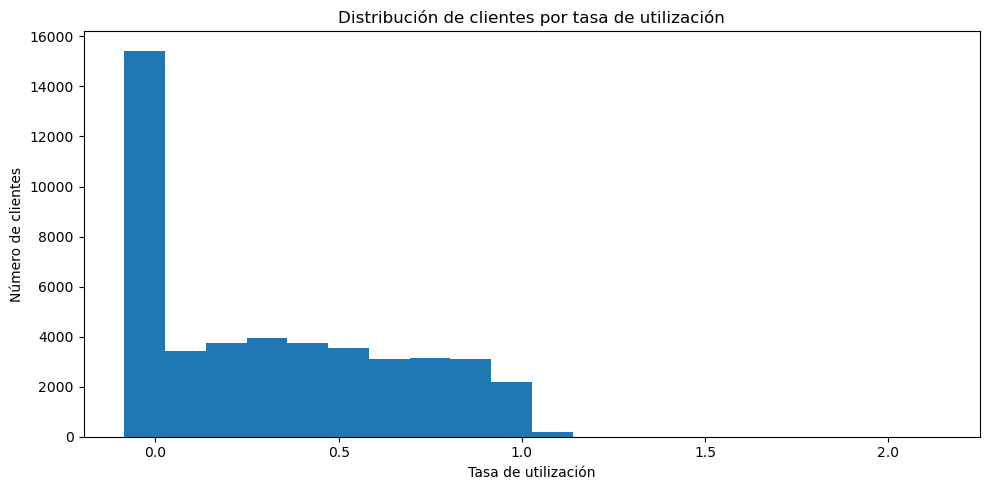

In [ ]:
w_acc = Window.partitionBy("CLIENT_ID") \
              .orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
              .rowsBetween(Window.unboundedPreceding, Window.currentRow)

# Cálculo de tasa de utilización
df_util = (
    behavioural_df
    .withColumn("UTILIZATION", F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))
    .withColumn("UTIL_avg", F.avg("UTILIZATION").over(w_acc))
)

w = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())         

df_util_latest = (
    df_util
    .withColumn("row_num", F.row_number().over(w))
    .filter(F.col("row_num") == 1)
    .drop("row_num")
)

df_util_latest.orderBy(F.col("UTIL_avg").desc()).show()

pdf = df_util_latest.select("CLIENT_ID", "UTIL_avg").toPandas()

# Histograma con matplotlib (bins ajustables)
plt.figure(figsize=(10,5))
plt.hist(pdf["UTIL_avg"], bins=20)   # no se especifican colores
plt.xlabel("Tasa de utilización")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por tasa de utilización")
plt.tight_layout()
plt.show()

+------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+-------------------+------------------+
|   CLIENT_ID|       CONTRACT_ID|      DATE|CREDICT_CARD_BALANCE|CREDIT_CARD_LIMIT|CREDIT_CARD_DRAWINGS_ATM|CREDIT_CARD_DRAWINGS|CREDIT_CARD_DRAWINGS_POS|CREDIT_CARD_DRAWINGS_OTHER|CREDIT_CARD_PAYMENT|NUMBER_DRAWINGS_ATM|NUMBER_DRAWINGS|NUMBER_INSTALMENTS|        UTILIZATION|          UTIL_avg|
+------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+-------------------+------------------+
|ES182296262M|ES1822116691y00XXX|2021-11-30|             2177.27|           2160.0|                   108.0|    

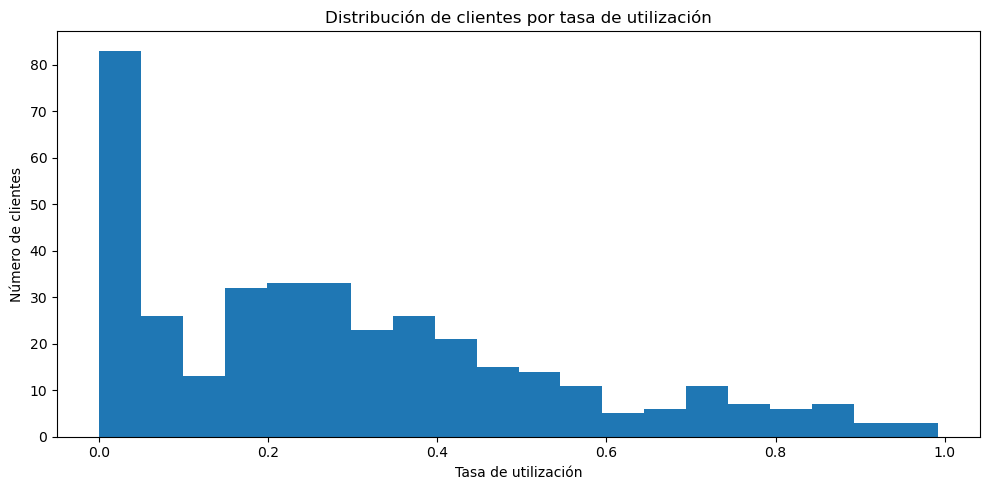

In [ ]:
w_acc = Window.partitionBy("CLIENT_ID") \
              .orderBy(F.to_date("DATE", "dd/MM/yyyy")) \
              .rowsBetween(Window.unboundedPreceding, Window.currentRow)

# Cálculo de tasa de utilización
df_util = (
    only_behavioural_df
    .withColumn("UTILIZATION", F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))
    .withColumn("UTIL_avg", F.avg("UTILIZATION").over(w_acc))
)

w = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())         

df_util_latest = (
    df_util
    .withColumn("row_num", F.row_number().over(w))
    .filter(F.col("row_num") == 1)
    .drop("row_num")
)

df_util_latest.orderBy(F.col("UTIL_avg").desc()).show()

pdf = df_util_latest.select("CLIENT_ID", "UTIL_avg").toPandas()

# Histograma con matplotlib (bins ajustables)
plt.figure(figsize=(10,5))
plt.hist(pdf["UTIL_avg"], bins=20)   # no se especifican colores
plt.xlabel("Tasa de utilización")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por tasa de utilización")
plt.tight_layout()
plt.show()

+------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+-------+-------------------+------------+--------------------+
|   CLIENT_ID|       CONTRACT_ID|      DATE|CREDICT_CARD_BALANCE|CREDIT_CARD_LIMIT|CREDIT_CARD_DRAWINGS_ATM|CREDIT_CARD_DRAWINGS|CREDIT_CARD_DRAWINGS_POS|CREDIT_CARD_DRAWINGS_OTHER|CREDIT_CARD_PAYMENT|NUMBER_DRAWINGS_ATM|NUMBER_DRAWINGS|NUMBER_INSTALMENTS|   DEBT|       DEBT_CUMULED|TOTAL_INCOME|         UTILIZATION|
+------------+------------------+----------+--------------------+-----------------+------------------------+--------------------+------------------------+--------------------------+-------------------+-------------------+---------------+------------------+-------+-------------------+------------+--------------------+
|ES182206730V|ES1822458054m00XXX|2021-10-30

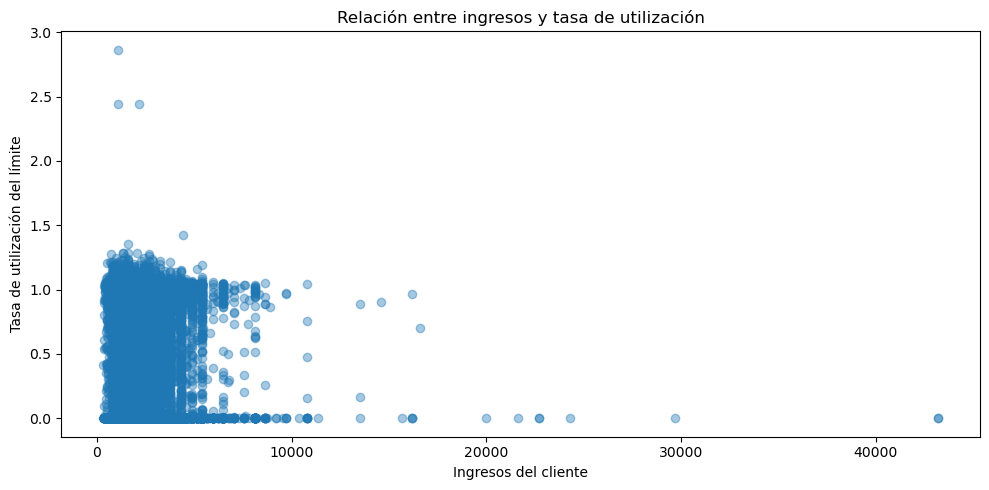

In [ ]:
# Ventana para acumular deuda por cliente a lo largo del tiempo
w = Window.partitionBy("CLIENT_ID") \
          .orderBy(F.col("DATE").asc()) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_deuda = behavioural_df \
    .withColumn("DEBT", F.col("CREDIT_CARD_DRAWINGS") - F.col("CREDIT_CARD_PAYMENT")) \
    .withColumn("DEBT_CUMULED", F.sum("DEBT").over(w))


# =============================================
# 2. Extraer el registro más reciente por cliente
# =============================================

w_desc = Window.partitionBy("CLIENT_ID") \
               .orderBy(F.col("DATE").desc())

df_ultima_deuda = df_deuda \
    .withColumn("row_num", F.row_number().over(w_desc)) \
    .filter(F.col("row_num") == 1) \
    .drop("row_num")


# ===========================
# 3. Unir con ingresos
# ===========================

income_df = clientes_df.select("CLIENT_ID", "TOTAL_INCOME")
df_merged = df_ultima_deuda.join(income_df, on="CLIENT_ID", how="left")


# =============================================
# 4. Calcular tasa de utilización del límite
# =============================================

df_merged = df_merged.withColumn("UTILIZATION", F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT"))

df_merged.orderBy(F.col("TOTAL_INCOME")).show()

# ===========================
# 5. Convertir a pandas
# ===========================

pdf = df_merged.select("TOTAL_INCOME", "UTILIZATION") \
               .toPandas()


# ===========================
# 6. Graficar
# ===========================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.scatter(pdf["TOTAL_INCOME"], pdf["UTILIZATION"], alpha=0.4)

plt.xlabel("Ingresos del cliente")
plt.ylabel("Tasa de utilización del límite")
plt.title("Relación entre ingresos y tasa de utilización")

plt.tight_layout()
plt.show()

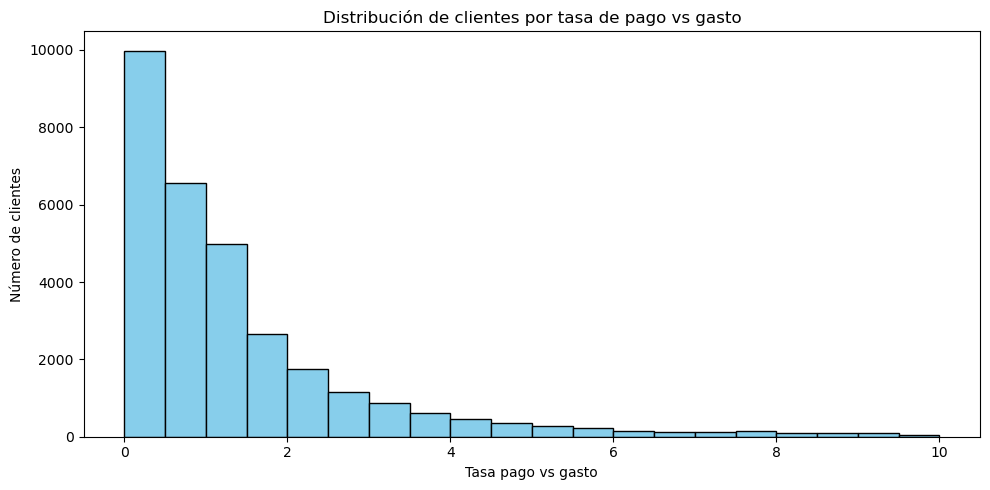

count    31639.000000
mean         3.973530
std        120.778540
min         -4.136757
25%          0.346419
50%          0.934444
75%          1.910342
max      13735.346846
Name: PAY/DRAW_avg, dtype: float64

In [ ]:
# Cálculo de tasa de utilización
w = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
w1 = Window.partitionBy("CLIENT_ID") \
          .orderBy(F.col("DATE").asc()) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_util = behavioural_df \
    .withColumn("PAY/DRAW", F.when(F.col("CREDIT_CARD_DRAWINGS") != 0,
                                F.col("CREDIT_CARD_PAYMENT") / F.col("CREDIT_CARD_DRAWINGS"))
                           .otherwise(None)) \
    .withColumn("PAY/DRAW_avg", F.avg("PAY/DRAW").over(w1))

df_util_latest = (
    df_util
    .withColumn("row_num", F.row_number().over(w))
    .filter(F.col("row_num") == 1)
    .drop("row_num")
)

pdf = df_util_latest.select("CLIENT_ID", "PAY/DRAW_avg").toPandas()

# Histograma con matplotlib (bins ajustables)
plt.figure(figsize=(10,5))
plt.hist(pdf["PAY/DRAW_avg"], bins=20, range=(0,10), color='skyblue', edgecolor='black')
plt.xlabel("Tasa pago vs gasto")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por tasa de pago vs gasto")
plt.tight_layout()
plt.show()


pdf["PAY/DRAW_avg"].describe()

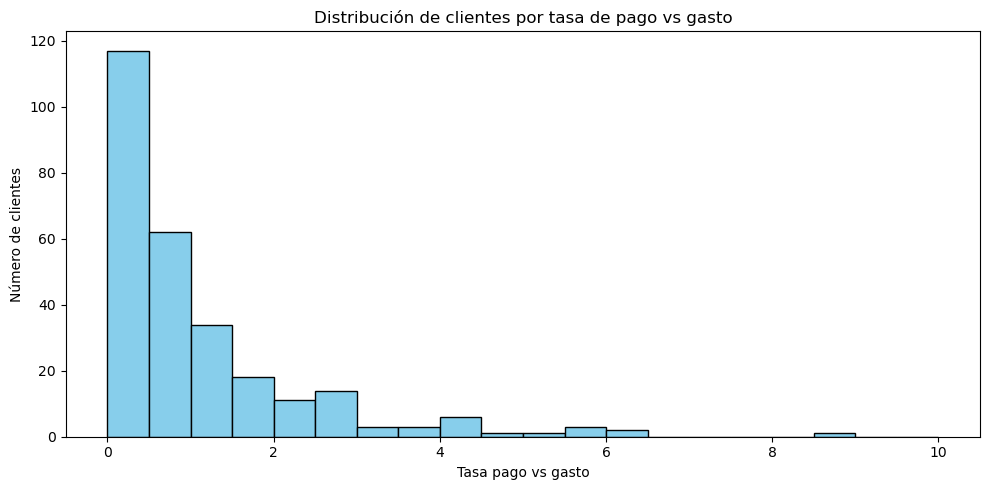

count    280.000000
mean       1.469044
std        4.156279
min        0.000000
25%        0.239871
50%        0.634079
75%        1.416191
max       60.600000
Name: PAY/DRAW_avg, dtype: float64

In [ ]:
# Cálculo de tasa de utilización
w = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())
w1 = Window.partitionBy("CLIENT_ID") \
          .orderBy(F.col("DATE").asc()) \
          .rowsBetween(Window.unboundedPreceding, Window.currentRow)

df_util = only_behavioural_df \
    .withColumn("PAY/DRAW", F.when(F.col("CREDIT_CARD_DRAWINGS") != 0,
                                F.col("CREDIT_CARD_PAYMENT") / F.col("CREDIT_CARD_DRAWINGS"))
                           .otherwise(None)) \
    .withColumn("PAY/DRAW_avg", F.avg("PAY/DRAW").over(w1))

df_util_latest = (
    df_util
    .withColumn("row_num", F.row_number().over(w))
    .filter(F.col("row_num") == 1)
    .drop("row_num")
)

pdf = df_util_latest.select("CLIENT_ID", "PAY/DRAW_avg").toPandas()

# Histograma con matplotlib (bins ajustables)
plt.figure(figsize=(10,5))
plt.hist(pdf["PAY/DRAW_avg"], bins=20, range=(0,10), color='skyblue', edgecolor='black')
plt.xlabel("Tasa pago vs gasto")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por tasa de pago vs gasto")
plt.tight_layout()
plt.show()


pdf["PAY/DRAW_avg"].describe()

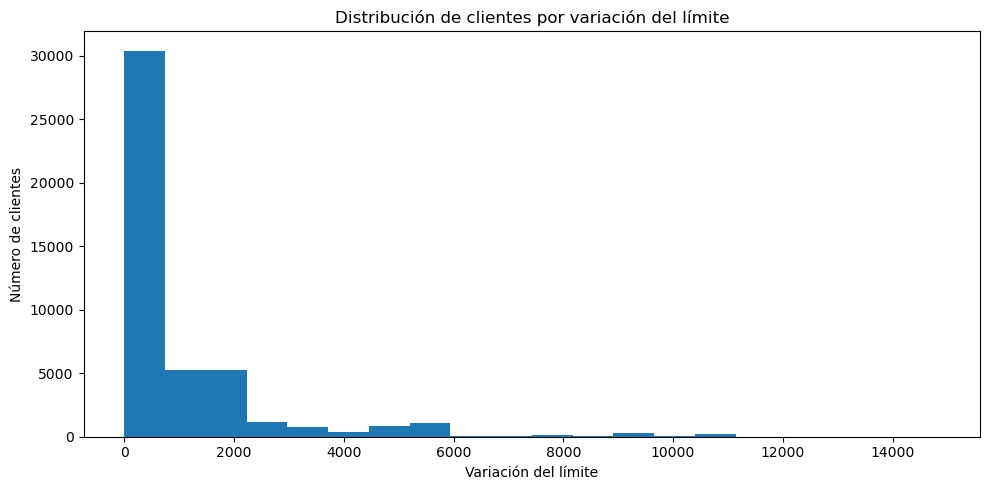

In [ ]:
# -----------------------------------------
# 1. Límite máximo por cliente
# -----------------------------------------
df_max_limit = behavioural_df.groupBy("CLIENT_ID") \
    .agg(F.max("CREDIT_CARD_LIMIT").alias("MAX_LIMIT"))

# -----------------------------------------
# 2. Límite más reciente por cliente
# -----------------------------------------
w_recent = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())

df_recent_limit = (
    behavioural_df
        .withColumn("rn", F.row_number().over(w_recent))
        .filter(F.col("rn") == 1)
        .select("CLIENT_ID", "CREDIT_CARD_LIMIT")
        .withColumnRenamed("CREDIT_CARD_LIMIT", "RECENT_LIMIT")
)

# -----------------------------------------
# 3. Cálculo de la variación del límite
# -----------------------------------------
df_limit_variation = (
    df_max_limit
        .join(df_recent_limit, on="CLIENT_ID")
        .withColumn("LIMIT_VARIATION", F.col("MAX_LIMIT") - F.col("RECENT_LIMIT"))
)

# -----------------------------------------
# 5. Convertir a Pandas para graficar
# -----------------------------------------
pdf = df_limit_variation.select("CLIENT_ID", "LIMIT_VARIATION").toPandas()

# -----------------------------------------
# 6. Gráfico final
# -----------------------------------------
plt.figure(figsize=(10,5))
plt.hist(pdf["LIMIT_VARIATION"], bins=20)   # no se especifican colores
plt.xlabel("Variación del límite")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por variación del límite")
plt.tight_layout()
plt.show()

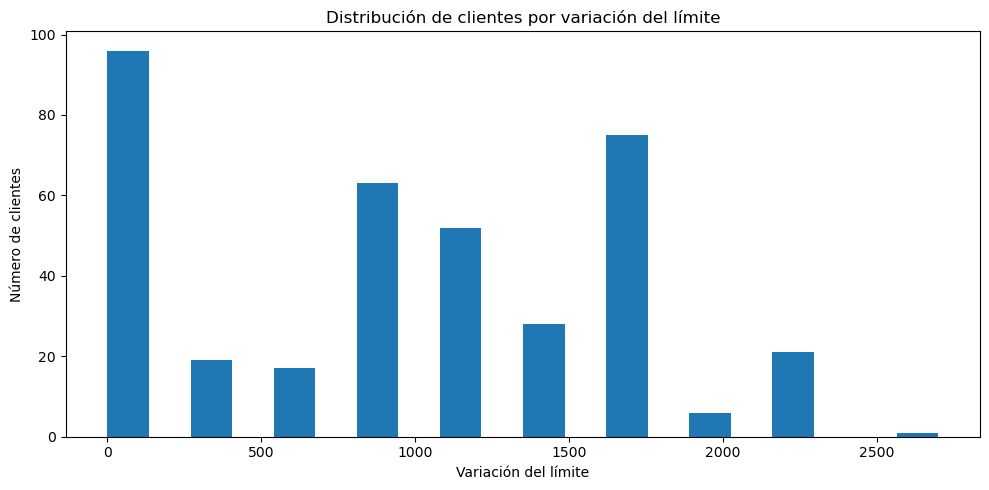

In [ ]:
# -----------------------------------------
# 1. Límite máximo por cliente
# -----------------------------------------
df_max_limit = only_behavioural_df.groupBy("CLIENT_ID") \
    .agg(F.max("CREDIT_CARD_LIMIT").alias("MAX_LIMIT"))

# -----------------------------------------
# 2. Límite más reciente por cliente
# -----------------------------------------
w_recent = Window.partitionBy("CLIENT_ID").orderBy(F.col("DATE").desc())

df_recent_limit = (
    only_behavioural_df
        .withColumn("rn", F.row_number().over(w_recent))
        .filter(F.col("rn") == 1)
        .select("CLIENT_ID", "CREDIT_CARD_LIMIT")
        .withColumnRenamed("CREDIT_CARD_LIMIT", "RECENT_LIMIT")
)

# -----------------------------------------
# 3. Cálculo de la variación del límite
# -----------------------------------------
df_limit_variation = (
    df_max_limit
        .join(df_recent_limit, on="CLIENT_ID")
        .withColumn("LIMIT_VARIATION", F.col("MAX_LIMIT") - F.col("RECENT_LIMIT"))
)

# -----------------------------------------
# 5. Convertir a Pandas para graficar
# -----------------------------------------
pdf = df_limit_variation.select("CLIENT_ID", "LIMIT_VARIATION").toPandas()

# -----------------------------------------
# 6. Gráfico final
# -----------------------------------------
plt.figure(figsize=(10,5))
plt.hist(pdf["LIMIT_VARIATION"], bins=20)   # no se especifican colores
plt.xlabel("Variación del límite")
plt.ylabel("Número de clientes")
plt.title("Distribución de clientes por variación del límite")
plt.tight_layout()
plt.show()

# ÁNGELA

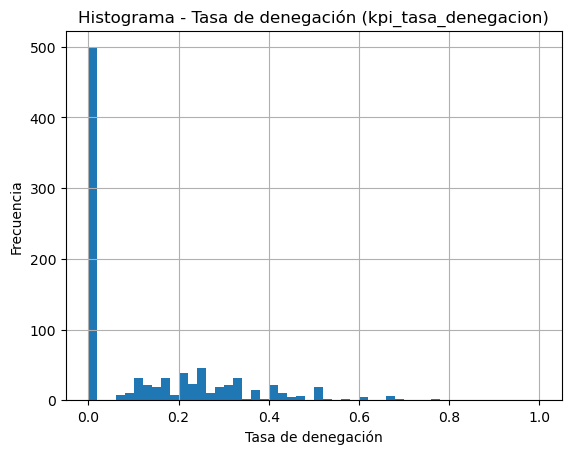

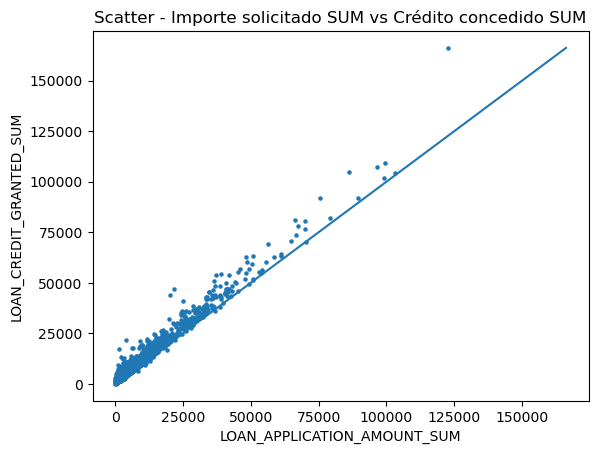

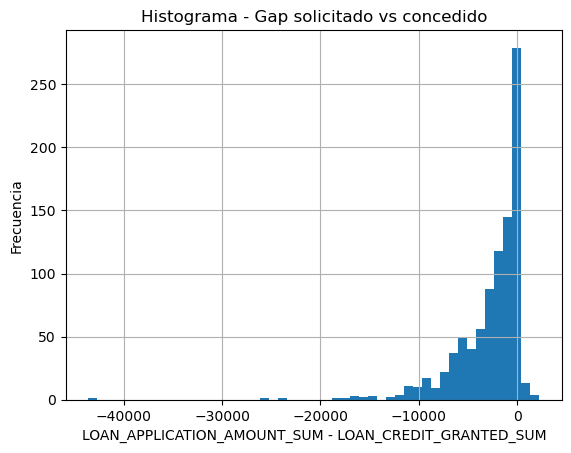

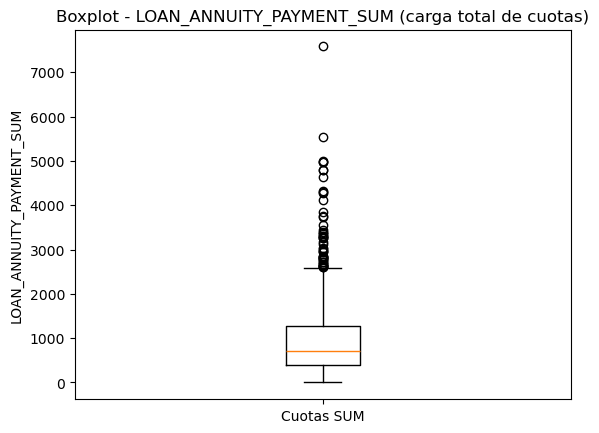

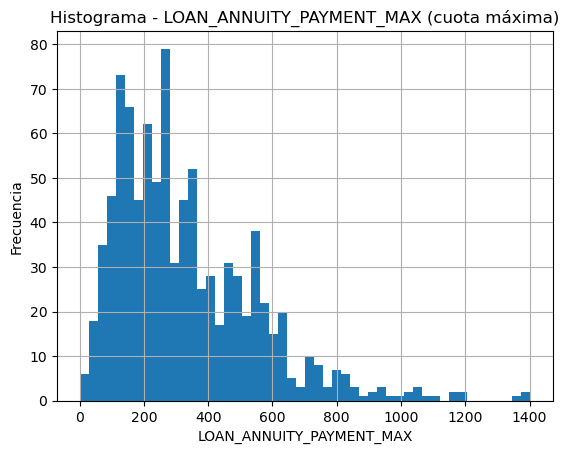

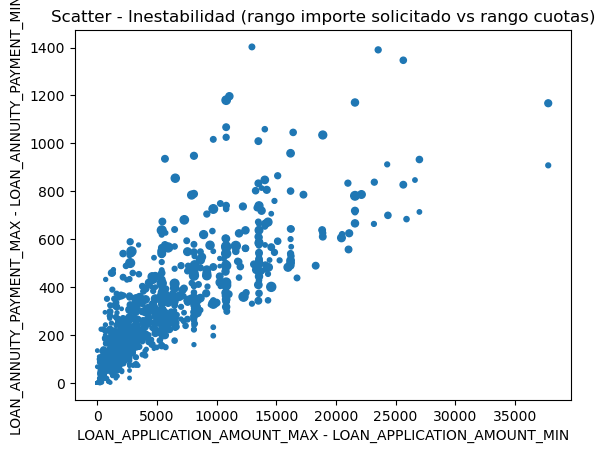

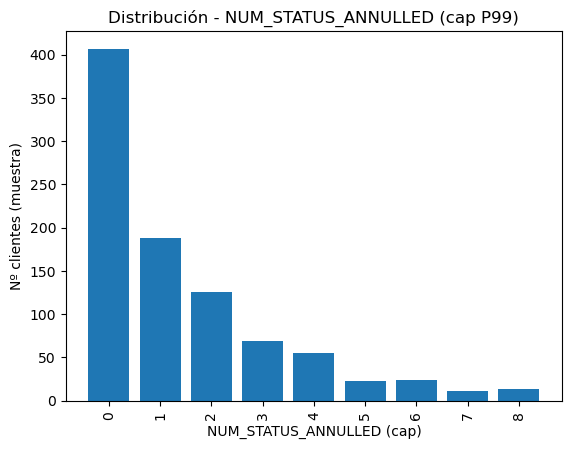

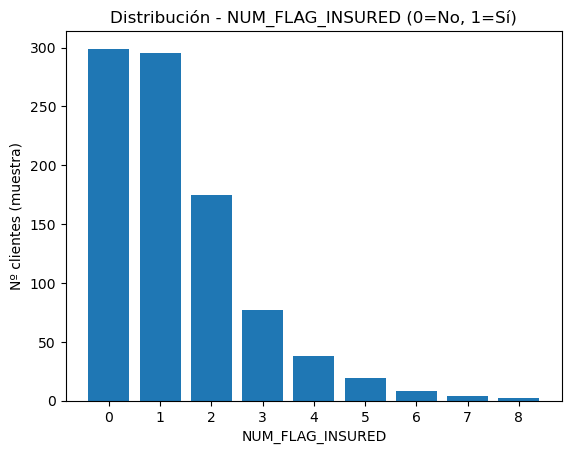

In [ ]:
from pyspark.sql import functions as F

# =========================
# 1) KPIs (sin cambiar datos base)
# =========================
df_kpi = (
    comunes_df
    .withColumn(
        "kpi_tasa_denegacion",
        F.when(F.col("NUM_PREVIOUS_LOAN_APP") > 0,
               F.col("NUM_STATUS_DENIED") / F.col("NUM_PREVIOUS_LOAN_APP")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_ratio_concesion",
        F.when(F.col("LOAN_APPLICATION_AMOUNT_SUM") > 0,
               F.col("LOAN_CREDIT_GRANTED_SUM") / F.col("LOAN_APPLICATION_AMOUNT_SUM")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_gap_solicitado_concedido",
        F.col("LOAN_APPLICATION_AMOUNT_SUM") - F.col("LOAN_CREDIT_GRANTED_SUM")
    )
    .withColumn(
        "kpi_rango_importe_solicitado",
        F.col("LOAN_APPLICATION_AMOUNT_MAX") - F.col("LOAN_APPLICATION_AMOUNT_MIN")
    )
    .withColumn(
        "kpi_rango_cuotas",
        F.col("LOAN_ANNUITY_PAYMENT_MAX") - F.col("LOAN_ANNUITY_PAYMENT_MIN")
    )
    .withColumn(
        "kpi_rango_tipo_variable",
        F.col("LOAN_VARIABLE_RATE_MAX") - F.col("LOAN_VARIABLE_RATE_MIN")
    )
    .withColumn(
        "kpi_ratio_anulados",
        F.when(F.col("NUM_PREVIOUS_LOAN_APP") > 0,
               F.col("NUM_STATUS_ANNULLED") / F.col("NUM_PREVIOUS_LOAN_APP")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_ratio_not_used",
        F.when(F.col("NUM_PREVIOUS_LOAN_APP") > 0,
               F.col("NUM_STATUS_NOT_USED") / F.col("NUM_PREVIOUS_LOAN_APP")
        ).otherwise(F.lit(None))
    )
)

# =========================
# 2) Muestreo para plot (ajusta frac si hace falta)
# =========================
cols_plot = [
    "CLIENT_ID",
    "NUM_PREVIOUS_LOAN_APP",
    "NUM_FLAG_INSURED",
    "LOAN_APPLICATION_AMOUNT_SUM",
    "LOAN_CREDIT_GRANTED_SUM",
    "LOAN_ANNUITY_PAYMENT_SUM",
    "LOAN_ANNUITY_PAYMENT_MAX",
    "NUM_STATUS_ANNULLED",
    "NUM_STATUS_DENIED",
    "kpi_tasa_denegacion",
    "kpi_ratio_concesion",
    "kpi_gap_solicitado_concedido",
    "kpi_rango_importe_solicitado",
    "kpi_rango_cuotas",
]

# Para datasets grandes: sample + limit
df_sample = (
    df_kpi.select(*[c for c in cols_plot if c in df_kpi.columns])
    .sample(withReplacement=False, fraction=0.02, seed=42)  # 2% (ajusta)
    .limit(200_000)  # tope por seguridad
)

pdf = df_sample.toPandas()

# =========================
# 3) Plots (matplotlib, sin seaborn)
# =========================
import matplotlib.pyplot as plt

def _clean_series(s):
    return s.dropna()

# 3.1 Histograma - Tasa de denegación
plt.figure()
_clean_series(pdf["kpi_tasa_denegacion"]).hist(bins=50)
plt.title("Histograma - Tasa de denegación (kpi_tasa_denegacion)")
plt.xlabel("Tasa de denegación")
plt.ylabel("Frecuencia")
plt.show()

# 3.2 Scatter - Solicitado vs Concedido + línea y=x
plt.figure()
x = _clean_series(pdf["LOAN_APPLICATION_AMOUNT_SUM"])
y = pdf.loc[x.index, "LOAN_CREDIT_GRANTED_SUM"].dropna()
idx = y.index.intersection(x.index)
plt.scatter(pdf.loc[idx, "LOAN_APPLICATION_AMOUNT_SUM"], pdf.loc[idx, "LOAN_CREDIT_GRANTED_SUM"], s=5)

# línea y=x con el rango común (no cambia colores)
mn = min(pdf.loc[idx, "LOAN_APPLICATION_AMOUNT_SUM"].min(), pdf.loc[idx, "LOAN_CREDIT_GRANTED_SUM"].min())
mx = max(pdf.loc[idx, "LOAN_APPLICATION_AMOUNT_SUM"].max(), pdf.loc[idx, "LOAN_CREDIT_GRANTED_SUM"].max())
plt.plot([mn, mx], [mn, mx])

plt.title("Scatter - Importe solicitado SUM vs Crédito concedido SUM")
plt.xlabel("LOAN_APPLICATION_AMOUNT_SUM")
plt.ylabel("LOAN_CREDIT_GRANTED_SUM")
plt.show()

# 3.3 Histograma - Gap solicitado vs concedido
plt.figure()
_clean_series(pdf["kpi_gap_solicitado_concedido"]).hist(bins=50)
plt.title("Histograma - Gap solicitado vs concedido")
plt.xlabel("LOAN_APPLICATION_AMOUNT_SUM - LOAN_CREDIT_GRANTED_SUM")
plt.ylabel("Frecuencia")
plt.show()

# 3.4 Boxplot - Carga total de cuotas
plt.figure()
plt.boxplot(_clean_series(pdf["LOAN_ANNUITY_PAYMENT_SUM"]), vert=True, showfliers=True)
plt.title("Boxplot - LOAN_ANNUITY_PAYMENT_SUM (carga total de cuotas)")
plt.ylabel("LOAN_ANNUITY_PAYMENT_SUM")
plt.xticks([1], ["Cuotas SUM"])
plt.show()

# 3.5 Histograma - Cuota máxima
plt.figure()
_clean_series(pdf["LOAN_ANNUITY_PAYMENT_MAX"]).hist(bins=50)
plt.title("Histograma - LOAN_ANNUITY_PAYMENT_MAX (cuota máxima)")
plt.xlabel("LOAN_ANNUITY_PAYMENT_MAX")
plt.ylabel("Frecuencia")
plt.show()

# 3.6 Scatter - Inestabilidad: rango importes vs rango cuotas (tamaño por nº solicitudes si está)
plt.figure()
mask = pdf["kpi_rango_importe_solicitado"].notna() & pdf["kpi_rango_cuotas"].notna()
sizes = None
if "NUM_PREVIOUS_LOAN_APP" in pdf.columns:
    # tamaño proporcional (acotado)
    s = pdf.loc[mask, "NUM_PREVIOUS_LOAN_APP"].fillna(0)
    sizes = (s.clip(lower=0, upper=s.quantile(0.99)) + 1) * 2

plt.scatter(
    pdf.loc[mask, "kpi_rango_importe_solicitado"],
    pdf.loc[mask, "kpi_rango_cuotas"],
    s=5 if sizes is None else sizes
)
plt.title("Scatter - Inestabilidad (rango importe solicitado vs rango cuotas)")
plt.xlabel("LOAN_APPLICATION_AMOUNT_MAX - LOAN_APPLICATION_AMOUNT_MIN")
plt.ylabel("LOAN_ANNUITY_PAYMENT_MAX - LOAN_ANNUITY_PAYMENT_MIN")
plt.show()

# 3.7 Bar - Productos anulados (distribución)
plt.figure()
# Conteo por valor (si hay demasiados valores distintos, lo acotamos al percentil 99)
v = _clean_series(pdf["NUM_STATUS_ANNULLED"]).astype(int)
cap = int(v.quantile(0.99))
v2 = v.clip(upper=cap)
counts = v2.value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)
plt.title("Distribución - NUM_STATUS_ANNULLED (cap P99)")
plt.xlabel("NUM_STATUS_ANNULLED (cap)")
plt.ylabel("Nº clientes (muestra)")
plt.xticks(rotation=90)
plt.show()

# 3.8 Bar - Vinculación (NUM_FLAG_INSURED)
if "NUM_FLAG_INSURED" in pdf.columns:
    plt.figure()
    v = _clean_series(pdf["NUM_FLAG_INSURED"]).astype(int)
    counts = v.value_counts().sort_index()
    plt.bar(counts.index.astype(str), counts.values)
    plt.title("Distribución - NUM_FLAG_INSURED (0=No, 1=Sí)")
    plt.xlabel("NUM_FLAG_INSURED")
    plt.ylabel("Nº clientes (muestra)")
    plt.show()


1. Histograma – Tasa de denegación
Lo que se observa

Pico muy fuerte en 0

Cola larga hasta valores altos (≈0.6–1)

Consecuencia

La mayoría de los clientes comunes no experimenta denegaciones, pero existe un subconjunto relevante con tasas de denegación elevadas.

Interpretación de abandono

Clientes con tasa de denegación > 0.3 son outliers de frustración crediticia

Este grupo es altamente vulnerable al churn

📌 Indicio fuerte: la frustración no es generalizada, pero cuando aparece es intensa y concentrada.

2. Scatter – Importe solicitado vs crédito concedido
Lo que se observa

Fuerte correlación (línea casi y = x)

Muchos puntos sistemáticamente por debajo de la diagonal

Algunos casos extremos de alta solicitud y menor concesión

Consecuencia

Aunque el banco concede crédito de forma proporcional, existe un patrón claro de infrafinanciación para un subconjunto de clientes.

Interpretación de abandono

Clientes lejos de la diagonal (solicitan mucho más de lo que reciben) son:

Clientes insatisfechos

Con mayor probabilidad de buscar financiación externa

📌 Indicio muy fuerte: el gap persistente es uno de los mejores predictores de abandono.

3. Histograma – Gap solicitado vs concedido

(valores negativos = se concede menos de lo solicitado)

Lo que se observa

Distribución claramente sesgada a valores negativos

Cola larga de gaps muy grandes

Consecuencia

El banco concede sistemáticamente menos crédito del solicitado en muchos casos, y para algunos clientes la diferencia es muy elevada.

Interpretación de abandono

Gaps grandes y repetidos ⇒ percepción de rechazo

Especialmente crítico cuando se combina con:

muchas solicitudes

denegaciones previas

📌 Indicio crítico cuando el gap es estructural, no puntual.

4. Boxplot – LOAN_ANNUITY_PAYMENT_SUM (carga total de cuotas)
Lo que se observa

Mediana relativamente baja

Muchísimos outliers altos

Distribución muy asimétrica

Consecuencia

Existe un grupo reducido de clientes con una carga financiera significativamente superior al resto.

Interpretación de abandono

Estos clientes:

tienen estrés financiero

son sensibles a condiciones (intereses, refinanciación)

pueden irse si no se les ofrece alivio

📌 Indicio medio–alto: no todos abandonan, pero es un perfil inestable.

5. Histograma – LOAN_ANNUITY_PAYMENT_MAX
Lo que se observa

Distribución sesgada a la derecha

Cuotas máximas muy altas para pocos clientes

Consecuencia

Algunos clientes afrontan picos de cuota muy elevados, aunque su media no sea extrema.

Interpretación de abandono

Picos de cuota generan:

estrés puntual

mala experiencia

cancelaciones posteriores

📌 Indicio complementario: refuerza el estrés financiero observado antes.

6. Scatter – Inestabilidad (rango importes vs rango cuotas)
Lo que se observa

Relación positiva clara

Nube muy dispersa

Algunos clientes extremadamente inestables

Consecuencia

Existe un segmento de clientes con comportamiento financiero altamente volátil.

Interpretación de abandono

Inestabilidad implica:

necesidades cambiantes

menor fidelidad

mayor probabilidad de cambiar de banco

📌 Indicio medio, pero muy relevante cuando se combina con frustración crediticia.

7. Distribución – NUM_STATUS_ANNULLED
Lo que se observa

Gran masa en 0

Descenso progresivo, pero con clientes que acumulan muchas anulaciones

Consecuencia

La mayoría no cancela productos, pero los que lo hacen suelen hacerlo repetidamente.

Interpretación de abandono

Cancelar productos es una señal clara de desvinculación

Repetición ⇒ pérdida de confianza

📌 Indicio muy fuerte: la desvinculación precede al abandono.

8. Distribución – NUM_FLAG_INSURED
Lo que se observa

Muchos clientes con valores bajos

Muy pocos con alta vinculación

Consecuencia

La vinculación con productos adicionales es baja para la mayoría de clientes.

Interpretación de abandono

Baja vinculación ⇒ bajo coste de salida

Clientes sin productos asociados se van más fácilmente

📌 Indicio estructural de churn.

CONCLUSIÓN GLOBAL (de estas gráficas)

Puedes afirmar con seguridad:

El abandono potencial no es masivo ni aleatorio, sino que se concentra en clientes con frustración crediticia persistente, infrafinanciación, alta carga o inestabilidad financiera y baja vinculación con productos del banco.

Jerarquía de riesgo (según lo observado)

Frustración crediticia (denegaciones + gap) 🔴

Desvinculación (anulaciones, baja vinculación) 🔴

Estrés financiero 🟠

Inestabilidad 🟠

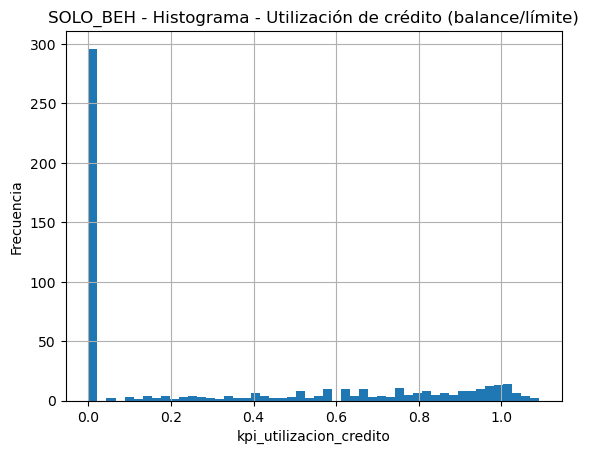

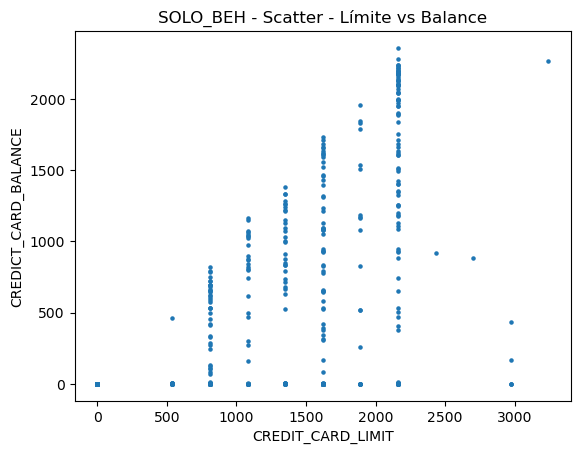

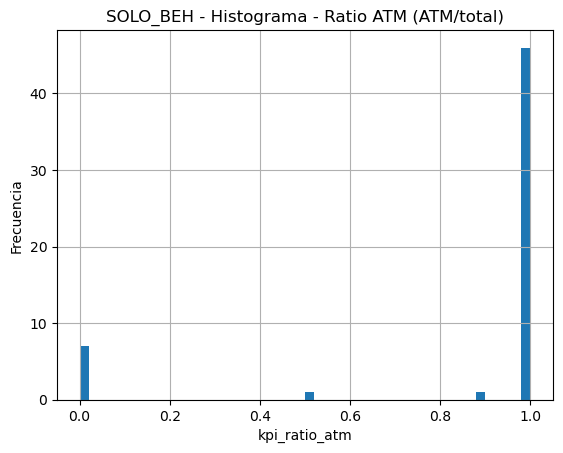

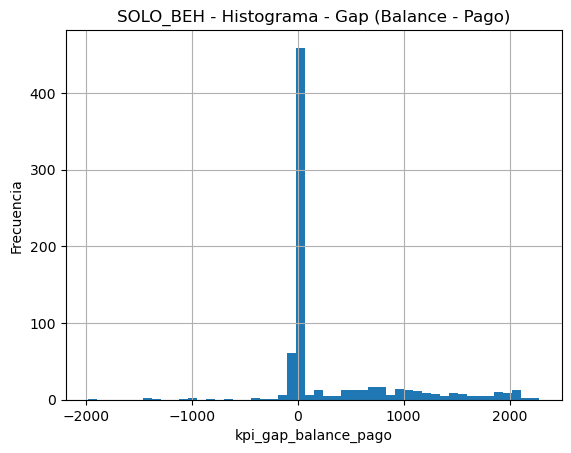

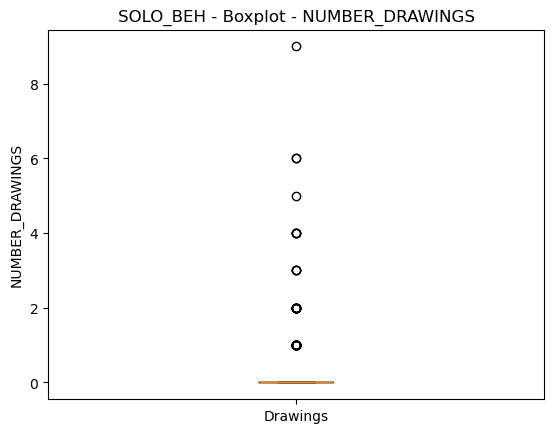

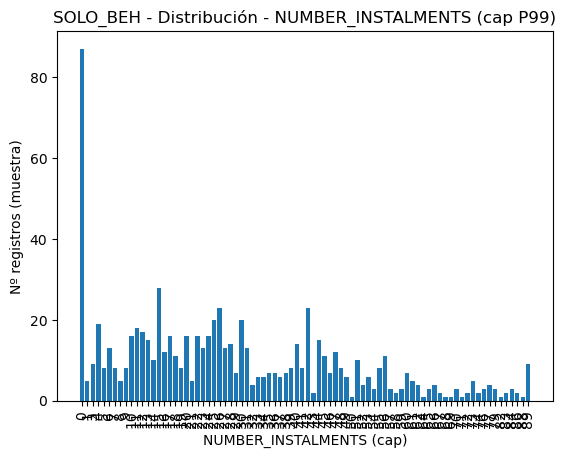

In [ ]:
from pyspark.sql import functions as F
import matplotlib.pyplot as plt

# =========================
# 0) INPUT
# =========================
df_in = only_behavioural_df

# (opcional) ver columnas disponibles
# print(df_in.columns)

# =========================
# 1) KPIs (solo con columnas que existen en only_behavioural_df)
# =========================
df_kpi = (
    df_in
    .withColumn(
        "kpi_utilizacion_credito",
        F.when(F.col("CREDIT_CARD_LIMIT") > 0,
               F.col("CREDICT_CARD_BALANCE") / F.col("CREDIT_CARD_LIMIT")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_ratio_atm",
        F.when(F.col("NUMBER_DRAWINGS") > 0,
               F.col("NUMBER_DRAWINGS_ATM") / F.col("NUMBER_DRAWINGS")
        ).otherwise(F.lit(None))
    )
    .withColumn(
        "kpi_gap_balance_pago",
        F.col("CREDICT_CARD_BALANCE") - F.col("CREDIT_CARD_PAYMENT")
    )
    .withColumn("kpi_instalments", F.col("NUMBER_INSTALMENTS"))
)

# =========================
# 2) Muestreo para plot (seguro para datasets grandes)
# =========================
cols_plot = [
    "CREDIT_CARD_LIMIT", "CREDICT_CARD_BALANCE", "CREDIT_CARD_PAYMENT",
    "NUMBER_DRAWINGS", "NUMBER_DRAWINGS_ATM", "NUMBER_INSTALMENTS",
    "kpi_utilizacion_credito", "kpi_ratio_atm", "kpi_gap_balance_pago"
]

df_sample = (
    df_kpi.select(*cols_plot)
    .sample(withReplacement=False, fraction=0.02, seed=42)  # ajusta 0.005 si va lento
    .limit(200_000)
)

pdf = df_sample.toPandas()

def _clean(s):
    return s.dropna()

# =========================
# 3) PLOTS
# =========================

# 3.1 Histograma - Utilización de crédito
plt.figure()
_clean(pdf["kpi_utilizacion_credito"]).hist(bins=50)
plt.title("SOLO_BEH - Histograma - Utilización de crédito (balance/límite)")
plt.xlabel("kpi_utilizacion_credito")
plt.ylabel("Frecuencia")
plt.show()

# 3.2 Scatter - Límite vs Balance
plt.figure()
mask = pdf["CREDIT_CARD_LIMIT"].notna() & pdf["CREDICT_CARD_BALANCE"].notna()
plt.scatter(pdf.loc[mask, "CREDIT_CARD_LIMIT"], pdf.loc[mask, "CREDICT_CARD_BALANCE"], s=5)
plt.title("SOLO_BEH - Scatter - Límite vs Balance")
plt.xlabel("CREDIT_CARD_LIMIT")
plt.ylabel("CREDICT_CARD_BALANCE")
plt.show()

# 3.3 Histograma - Ratio ATM
plt.figure()
_clean(pdf["kpi_ratio_atm"]).hist(bins=50)
plt.title("SOLO_BEH - Histograma - Ratio ATM (ATM/total)")
plt.xlabel("kpi_ratio_atm")
plt.ylabel("Frecuencia")
plt.show()

# 3.4 Histograma - Gap (Balance - Pago)
plt.figure()
_clean(pdf["kpi_gap_balance_pago"]).hist(bins=50)
plt.title("SOLO_BEH - Histograma - Gap (Balance - Pago)")
plt.xlabel("kpi_gap_balance_pago")
plt.ylabel("Frecuencia")
plt.show()

# 3.5 Boxplot - NUMBER_DRAWINGS
plt.figure()
plt.boxplot(_clean(pdf["NUMBER_DRAWINGS"]), vert=True, showfliers=True)
plt.title("SOLO_BEH - Boxplot - NUMBER_DRAWINGS")
plt.ylabel("NUMBER_DRAWINGS")
plt.xticks([1], ["Drawings"])
plt.show()

# 3.6 Bar - NUMBER_INSTALMENTS (cap P99)
plt.figure()
v = _clean(pdf["NUMBER_INSTALMENTS"]).astype(int)
cap = int(v.quantile(0.99)) if len(v) > 0 else 0
v2 = v.clip(upper=cap)
counts = v2.value_counts().sort_index()

plt.bar(counts.index.astype(str), counts.values)
plt.title("SOLO_BEH - Distribución - NUMBER_INSTALMENTS (cap P99)")
plt.xlabel("NUMBER_INSTALMENTS (cap)")
plt.ylabel("Nº registros (muestra)")
plt.xticks(rotation=90)
plt.show()


=== KPIs ===
Clientes: 154207
Tasa incumplimiento: 0.0824
Exposición total (€): 1094744812.79
Exposición incumplidores (€): 84593652.79
Importe medio (€): 7099.19
Importe mediana (€): 6112.8
Num productos medio: 1.99
Num productos mediana: 2.0

=== Incumplimiento por producto (top) ===
+-----------------+---------+-------------------+------------------+-------------+
|NAME_PRODUCT_TYPE|n_clients|non_compliant_rate |amount_mean       |amount_median|
+-----------------+---------+-------------------+------------------+-------------+
|PRODUCT 1        |140256   |0.08496606205795118|7453.252857524947 |6470.77      |
|PRODUCT 2        |13951    |0.05705684180345495|3539.6301340405707|3240.0       |
+-----------------+---------+-------------------+------------------+-------------+


=== Incumplimiento por NUMBER_OF_PRODUCTS ===
+------------------+---------+-------------------+------------------+
|NUMBER_OF_PRODUCTS|n_clients|non_compliant_rate |amount_mean       |
+------------------+-------

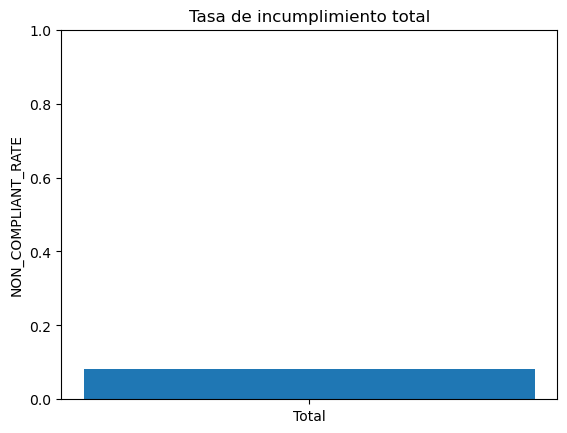

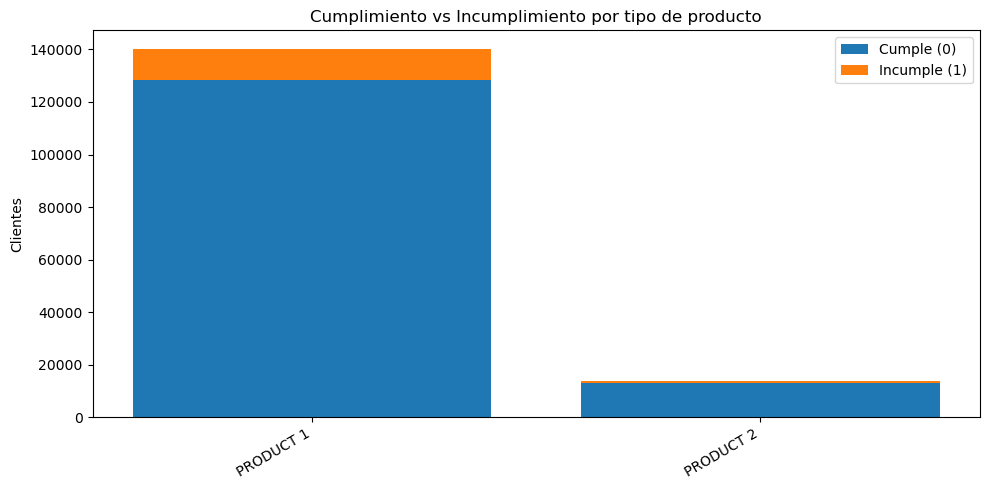

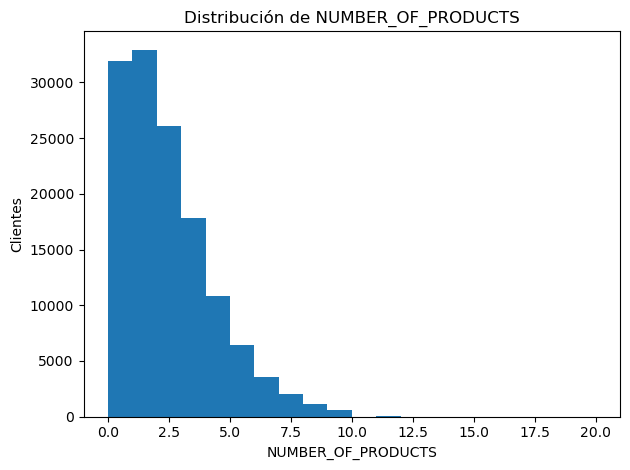

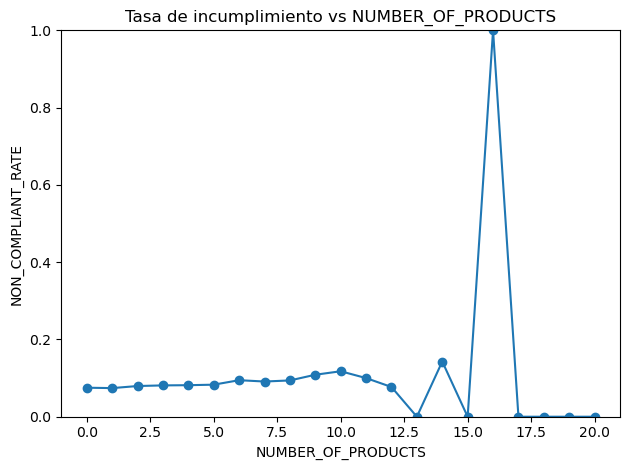

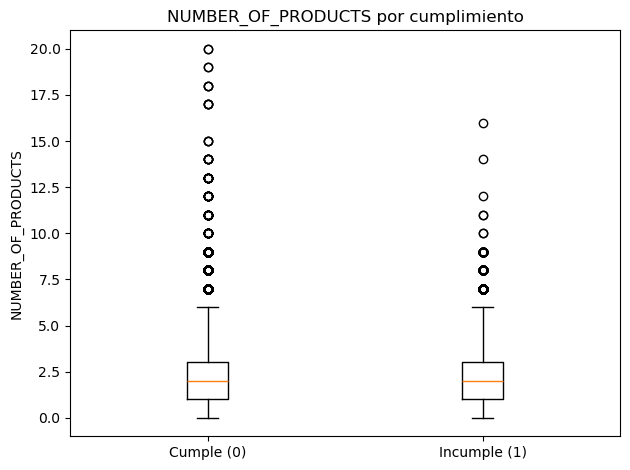

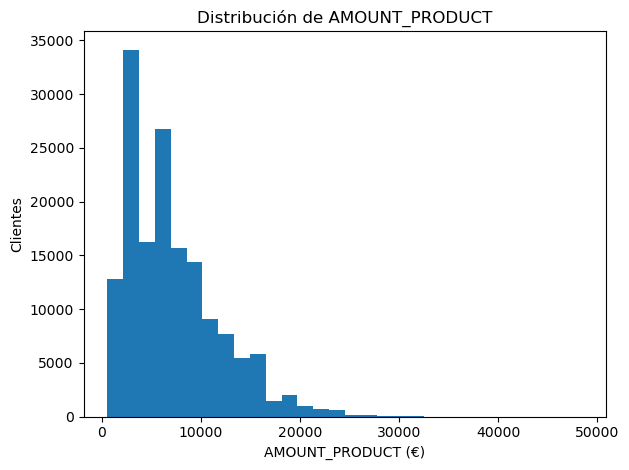

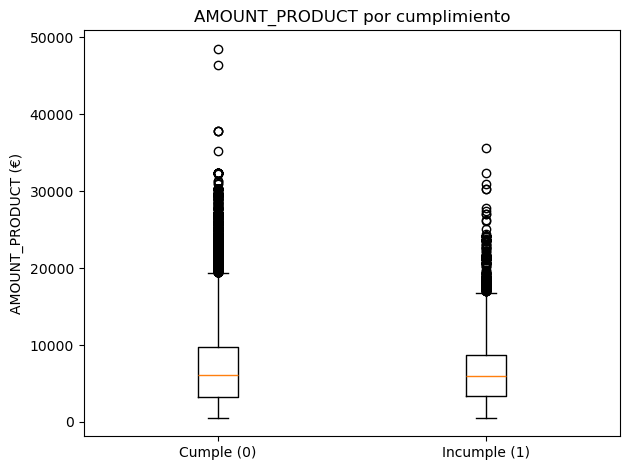

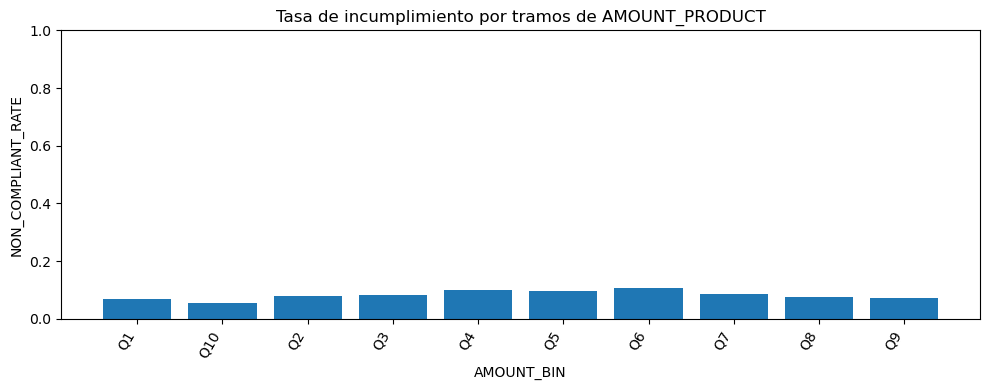

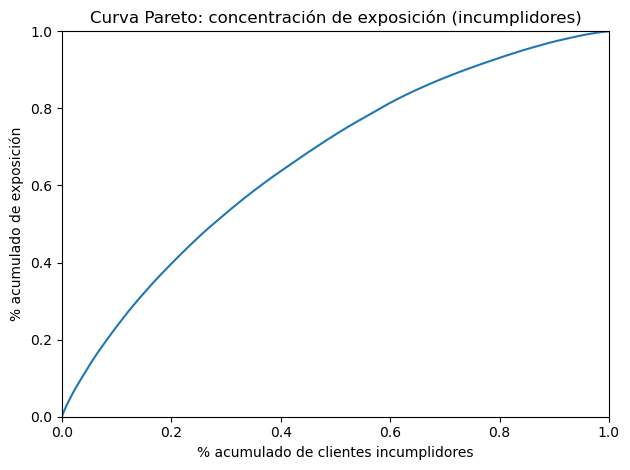

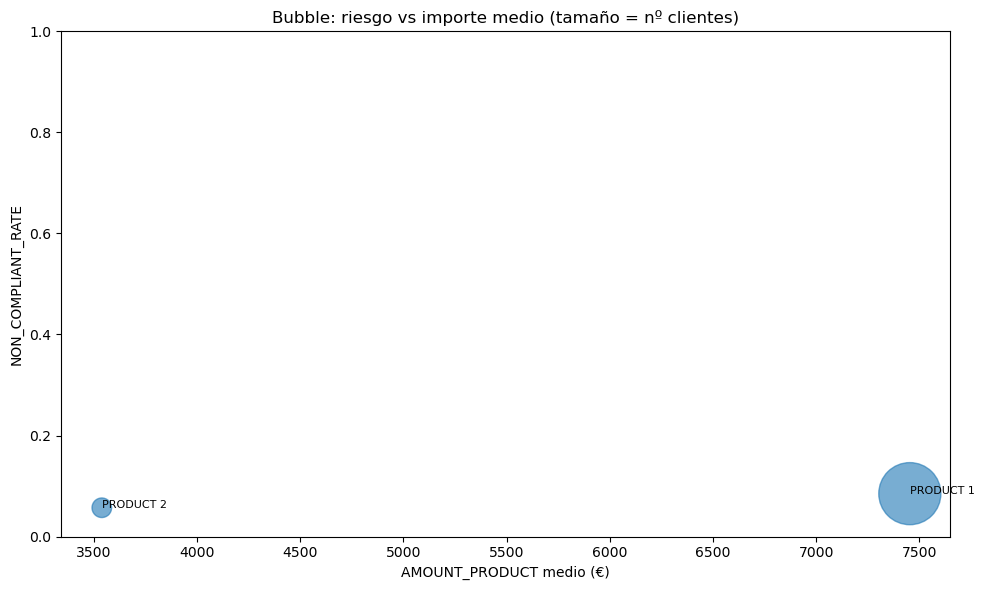

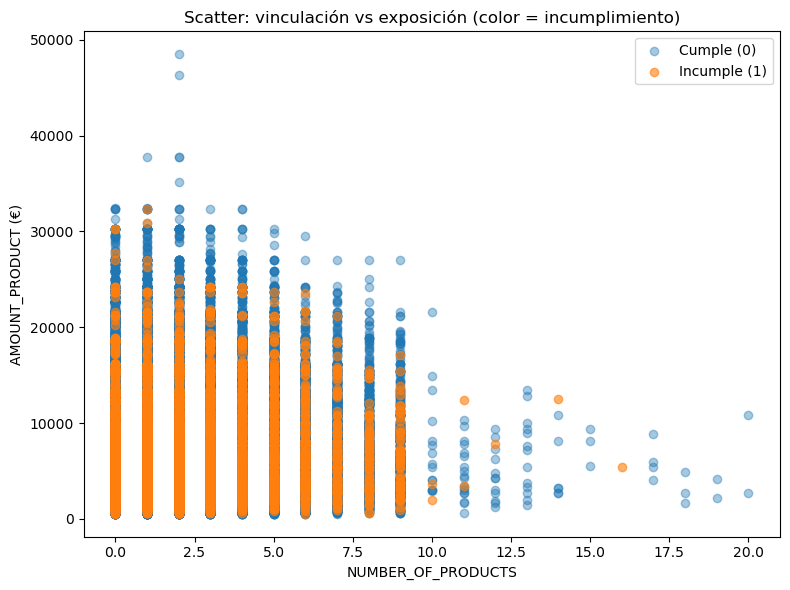

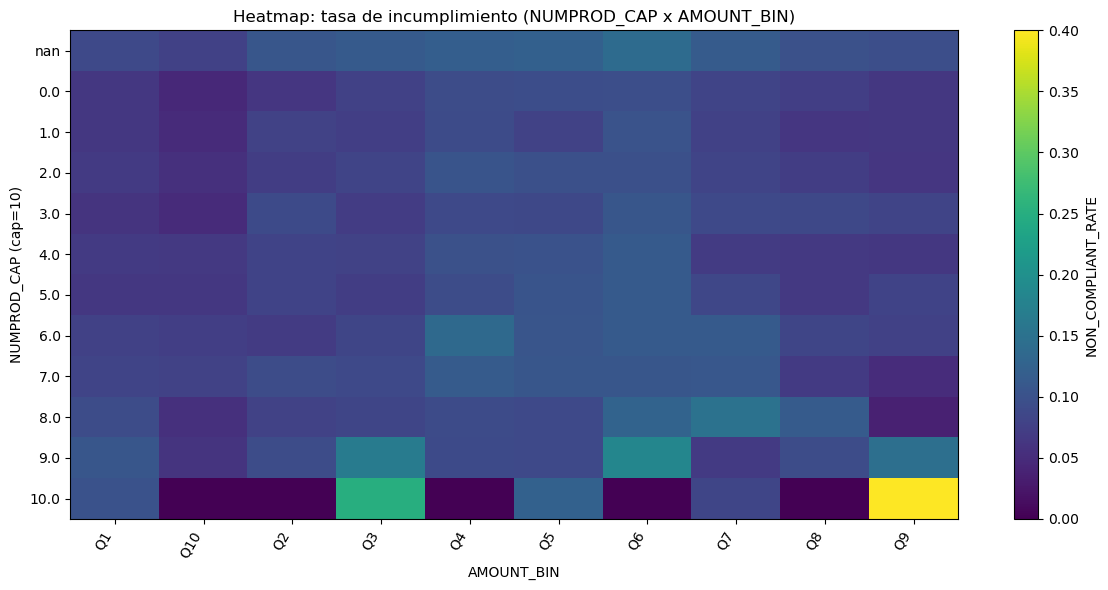


Listo: métricas calculadas y gráficos generados.


In [ ]:
# =========================
# SCRIPT COMPLETO 100% PYSPARK (plot con matplotlib -> pandas temporal)
# =========================

# -------------------------
# 1) CARGA / VALIDACIÓN
# -------------------------
df = clientes_df  # spark DataFrame

required = ["NON_COMPLIANT_CONTRACT", "NAME_PRODUCT_TYPE", "AMOUNT_PRODUCT", "NUMBER_OF_PRODUCTS"]
for c in required:
    if c not in df.columns:
        raise ValueError(f"Falta la columna: {c}")

# -------------------------
# 2) LIMPIEZA Y CASTINGS
# -------------------------
df = df.withColumn(
    "NON_COMPLIANT_CONTRACT",
    F.when(F.lower(F.col("NON_COMPLIANT_CONTRACT").cast("string"))
           .isin("1","true","t","yes","y","si","sí"), 1).otherwise(0)
)

df = df.withColumn("AMOUNT_PRODUCT", F.col("AMOUNT_PRODUCT").cast("double"))
df = df.withColumn("NUMBER_OF_PRODUCTS", F.col("NUMBER_OF_PRODUCTS").cast("int"))
df = df.withColumn("NAME_PRODUCT_TYPE", F.col("NAME_PRODUCT_TYPE").cast("string"))

# Filtrar nulos en importe
df = df.filter(F.col("AMOUNT_PRODUCT").isNotNull())

# -------------------------
# 3) BINS POR CUANTILES (10)
# -------------------------
# calcular cuantiles aproximados
quantiles = df.approxQuantile("AMOUNT_PRODUCT", [i/10 for i in range(11)], 0.001)

# función para asignar decil
def amount_bin_expr(col):
    expr = None
    # build chained when expressions
    for i in range(1, 10):
        q = quantiles[i]
        label = f"Q{i}"
        if expr is None:
            expr = F.when(col <= q, label)
        else:
            expr = expr.when(col <= q, label)
    expr = expr.otherwise("Q10")
    return expr

df = df.withColumn("AMOUNT_BIN", amount_bin_expr(F.col("AMOUNT_PRODUCT")))

# Cap de número de productos
df = df.withColumn("NUMPROD_CAP", F.when(F.col("NUMBER_OF_PRODUCTS") > 10, 10).otherwise(F.col("NUMBER_OF_PRODUCTS")))

# -------------------------
# 4) KPIs RESUMEN
# -------------------------
n_clients = df.count()
noncomp_rate = df.agg(F.mean("NON_COMPLIANT_CONTRACT")).first()[0] or 0.0
exposure_total = df.agg(F.sum("AMOUNT_PRODUCT")).first()[0] or 0.0
exposure_noncomp = df.filter(F.col("NON_COMPLIANT_CONTRACT") == 1).agg(F.sum("AMOUNT_PRODUCT")).first()[0] or 0.0
amount_mean = df.agg(F.mean("AMOUNT_PRODUCT")).first()[0] or 0.0
amount_median_global = df.approxQuantile("AMOUNT_PRODUCT", [0.5], 0.001)[0] if n_clients>0 else None
numprod_mean = df.agg(F.mean("NUMBER_OF_PRODUCTS")).first()[0] or 0.0
numprod_median = df.approxQuantile("NUMBER_OF_PRODUCTS", [0.5], 0.001)[0] if n_clients>0 else None

print("=== KPIs ===")
print("Clientes:", n_clients)
print("Tasa incumplimiento:", round(noncomp_rate, 4))
print("Exposición total (€):", round(exposure_total, 2))
print("Exposición incumplidores (€):", round(exposure_noncomp, 2))
print("Importe medio (€):", round(amount_mean, 2))
print("Importe mediana (€):", round(amount_median_global, 2) if amount_median_global is not None else None)
print("Num productos medio:", round(numprod_mean, 2))
print("Num productos mediana:", round(numprod_median, 2) if numprod_median is not None else None)

# -------------------------
# 5) TABLAS (por producto, número productos, tramos)
# -------------------------
by_product = df.groupBy("NAME_PRODUCT_TYPE").agg(
    F.count("*").alias("n_clients"),
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate"),
    F.mean("AMOUNT_PRODUCT").alias("amount_mean"),
    F.expr("percentile_approx(AMOUNT_PRODUCT, 0.5)").alias("amount_median")
).orderBy(F.col("non_compliant_rate").desc())

by_numprod = df.groupBy("NUMBER_OF_PRODUCTS").agg(
    F.count("*").alias("n_clients"),
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate"),
    F.mean("AMOUNT_PRODUCT").alias("amount_mean")
).orderBy("NUMBER_OF_PRODUCTS")

by_amountbin = df.groupBy("AMOUNT_BIN").agg(
    F.count("*").alias("n_clients"),
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate"),
    F.mean("AMOUNT_PRODUCT").alias("amount_mean")
).orderBy("AMOUNT_BIN")

# Mostrar resumenes (opcional)
print("\n=== Incumplimiento por producto (top) ===")
by_product.show(20, truncate=False)
print("\n=== Incumplimiento por NUMBER_OF_PRODUCTS ===")
by_numprod.show(50, truncate=False)
print("\n=== Incumplimiento por AMOUNT_BIN ===")
by_amountbin.show(50, truncate=False)

# -------------------------
# 6) PLOTS: convertimos a pandas solo para pintar
# -------------------------

# 6.1 Bar: tasa incumplimiento total
plt.figure()
plt.bar(["Total"], [noncomp_rate])
plt.title("Tasa de incumplimiento total")
plt.ylabel("NON_COMPLIANT_RATE")
plt.ylim(0, 1)
plt.show()

# 6.2 Barras apiladas: cumplimiento vs incumplimiento por producto
pdf_ct = df.groupBy("NAME_PRODUCT_TYPE", "NON_COMPLIANT_CONTRACT").count().toPandas()
# pivot similar a crosstab normalize index
pivot_ct = pdf_ct.pivot_table(index="NAME_PRODUCT_TYPE", columns="NON_COMPLIANT_CONTRACT", values="count", fill_value=0)
# aseguramos ambas columnas 0 y 1
if 0 not in pivot_ct.columns: pivot_ct[0] = 0
if 1 not in pivot_ct.columns: pivot_ct[1] = 0
pivot_ct = pivot_ct[[0,1]]
labels = pivot_ct.index.tolist()
cumple = pivot_ct[0].values
incumple = pivot_ct[1].values

plt.figure(figsize=(10,5))
plt.bar(labels, cumple, label="Cumple (0)")
plt.bar(labels, incumple, bottom=cumple, label="Incumple (1)")
plt.title("Cumplimiento vs Incumplimiento por tipo de producto")
plt.ylabel("Clientes")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

# 6.3 Histogram: NUMBER_OF_PRODUCTS
pdf_numprod = df.select("NUMBER_OF_PRODUCTS").toPandas()
plt.figure()
plt.hist(pdf_numprod["NUMBER_OF_PRODUCTS"].dropna(), bins=20)
plt.title("Distribución de NUMBER_OF_PRODUCTS")
plt.xlabel("NUMBER_OF_PRODUCTS")
plt.ylabel("Clientes")
plt.tight_layout()
plt.show()

# 6.4 Line plot: incumplimiento vs número de productos
pdf_by_numprod = by_numprod.toPandas().set_index("NUMBER_OF_PRODUCTS")
plt.figure()
plt.plot(pdf_by_numprod.index, pdf_by_numprod["non_compliant_rate"], marker="o")
plt.title("Tasa de incumplimiento vs NUMBER_OF_PRODUCTS")
plt.xlabel("NUMBER_OF_PRODUCTS")
plt.ylabel("NON_COMPLIANT_RATE")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 6.5 Boxplot: NUMBER_OF_PRODUCTS por cumplimiento
pdf_np = df.select("NON_COMPLIANT_CONTRACT", "NUMBER_OF_PRODUCTS").toPandas()
data_np = [
    pdf_np.loc[pdf_np["NON_COMPLIANT_CONTRACT"] == 0, "NUMBER_OF_PRODUCTS"].dropna(),
    pdf_np.loc[pdf_np["NON_COMPLIANT_CONTRACT"] == 1, "NUMBER_OF_PRODUCTS"].dropna()
]
plt.figure()
plt.boxplot(data_np, labels=["Cumple (0)", "Incumple (1)"])
plt.title("NUMBER_OF_PRODUCTS por cumplimiento")
plt.ylabel("NUMBER_OF_PRODUCTS")
plt.tight_layout()
plt.show()

# 6.6 Histogram: AMOUNT_PRODUCT
pdf_amount = df.select("AMOUNT_PRODUCT").toPandas()
plt.figure()
plt.hist(pdf_amount["AMOUNT_PRODUCT"].dropna(), bins=30)
plt.title("Distribución de AMOUNT_PRODUCT")
plt.xlabel("AMOUNT_PRODUCT (€)")
plt.ylabel("Clientes")
plt.tight_layout()
plt.show()

# 6.7 Boxplot: AMOUNT_PRODUCT por cumplimiento
pdf_amt = df.select("NON_COMPLIANT_CONTRACT", "AMOUNT_PRODUCT").toPandas()
data_amt = [
    pdf_amt.loc[pdf_amt["NON_COMPLIANT_CONTRACT"] == 0, "AMOUNT_PRODUCT"].dropna(),
    pdf_amt.loc[pdf_amt["NON_COMPLIANT_CONTRACT"] == 1, "AMOUNT_PRODUCT"].dropna()
]
plt.figure()
plt.boxplot(data_amt, labels=["Cumple (0)", "Incumple (1)"])
plt.title("AMOUNT_PRODUCT por cumplimiento")
plt.ylabel("AMOUNT_PRODUCT (€)")
plt.tight_layout()
plt.show()

# 6.8 Bar: incumplimiento por tramos de importe (AMOUNT_BIN)
pdf_by_amountbin = by_amountbin.toPandas().set_index("AMOUNT_BIN").sort_index()
plt.figure(figsize=(10,4))
plt.bar(pdf_by_amountbin.index.astype(str), pdf_by_amountbin["non_compliant_rate"].values)
plt.title("Tasa de incumplimiento por tramos de AMOUNT_PRODUCT")
plt.xlabel("AMOUNT_BIN")
plt.ylabel("NON_COMPLIANT_RATE")
plt.ylim(0,1)
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# 6.9 Pareto: exposición de incumplidores (concentración)
pdf_non = df.filter(F.col("NON_COMPLIANT_CONTRACT") == 1).select("AMOUNT_PRODUCT").toPandas()
if len(pdf_non) > 0:
    pdf_non = pdf_non.sort_values("AMOUNT_PRODUCT", ascending=False).reset_index(drop=True)
    pdf_non["cum_exposure_share"] = pdf_non["AMOUNT_PRODUCT"].cumsum() / pdf_non["AMOUNT_PRODUCT"].sum()
    pdf_non["cum_clients_share"] = (np.arange(1, len(pdf_non) + 1) / len(pdf_non))
    plt.figure()
    plt.plot(pdf_non["cum_clients_share"], pdf_non["cum_exposure_share"])
    plt.title("Curva Pareto: concentración de exposición (incumplidores)")
    plt.xlabel("% acumulado de clientes incumplidores")
    plt.ylabel("% acumulado de exposición")
    plt.ylim(0,1)
    plt.xlim(0,1)
    plt.tight_layout()
    plt.show()
else:
    plt.figure()
    plt.text(0.1, 0.5, "No hay incumplidores en los datos")
    plt.title("Pareto exposición (incumplidores)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# 6.10 Bubble chart: producto (importe medio vs riesgo, tamaño=nº clientes)
pdf_bp = by_product.toPandas().set_index("NAME_PRODUCT_TYPE")
x = pdf_bp["amount_mean"].values
y = pdf_bp["non_compliant_rate"].values
n_clients_vals = pdf_bp["n_clients"].values
sizes = (n_clients_vals / n_clients_vals.max()) * 2000 if n_clients_vals.max() > 0 else np.ones_like(n_clients_vals)*100
labels = pdf_bp.index.tolist()

plt.figure(figsize=(10,6))
plt.scatter(x, y, s=sizes, alpha=0.6)
for i, lab in enumerate(labels):
    plt.text(x[i], y[i], lab, fontsize=8)
plt.title("Bubble: riesgo vs importe medio (tamaño = nº clientes)")
plt.xlabel("AMOUNT_PRODUCT medio (€)")
plt.ylabel("NON_COMPLIANT_RATE")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

# 6.11 Scatter: NUMBER_OF_PRODUCTS vs AMOUNT_PRODUCT, coloreado por incumplimiento
pdf_scatter = df.select("NUMBER_OF_PRODUCTS", "AMOUNT_PRODUCT", "NON_COMPLIANT_CONTRACT").toPandas()
plt.figure(figsize=(8,6))
mask0 = pdf_scatter["NON_COMPLIANT_CONTRACT"] == 0
mask1 = pdf_scatter["NON_COMPLIANT_CONTRACT"] == 1
plt.scatter(pdf_scatter.loc[mask0, "NUMBER_OF_PRODUCTS"], pdf_scatter.loc[mask0, "AMOUNT_PRODUCT"], alpha=0.4, label="Cumple (0)")
plt.scatter(pdf_scatter.loc[mask1, "NUMBER_OF_PRODUCTS"], pdf_scatter.loc[mask1, "AMOUNT_PRODUCT"], alpha=0.6, label="Incumple (1)")
plt.title("Scatter: vinculación vs exposición (color = incumplimiento)")
plt.xlabel("NUMBER_OF_PRODUCTS")
plt.ylabel("AMOUNT_PRODUCT (€)")
plt.legend()
plt.tight_layout()
plt.show()

# 6.12 Heatmap: tasa de incumplimiento vs (NUMPROD_CAP x AMOUNT_BIN)
# Creamos pivot en pandas porque matplolib usa matrices
pdf_pivot = df.groupBy("NUMPROD_CAP", "AMOUNT_BIN").agg(
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate")
).toPandas()

if not pdf_pivot.empty:
    pivot_table = pdf_pivot.pivot(index="NUMPROD_CAP", columns="AMOUNT_BIN", values="non_compliant_rate").fillna(0)
    plt.figure(figsize=(12,6))
    plt.imshow(pivot_table.values, aspect="auto", interpolation='nearest')
    plt.title("Heatmap: tasa de incumplimiento (NUMPROD_CAP x AMOUNT_BIN)")
    plt.xlabel("AMOUNT_BIN")
    plt.ylabel("NUMPROD_CAP (cap=10)")
    plt.xticks(ticks=np.arange(pivot_table.shape[1]), labels=pivot_table.columns, rotation=60, ha="right")
    plt.yticks(ticks=np.arange(pivot_table.shape[0]), labels=pivot_table.index)
    plt.colorbar(label="NON_COMPLIANT_RATE")
    plt.tight_layout()
    plt.show()
else:
    plt.figure()
    plt.text(0.1,0.5,"No hay datos para heatmap")
    plt.axis("off")
    plt.show()

print("\nListo: métricas calculadas y gráficos generados.")


=== KPIs ===
Clientes: 45668
Tasa incumplimiento: 0.0876
Exposición total (€): 340290403.41
Exposición incumplidores (€): 27934742.38
Importe medio (€): 7451.4
Importe mediana (€): 6533.89
Num productos medio: 2.85
Num productos mediana: 3.0

=== Incumplimiento por producto (top) ===
+-----------------+---------+-------------------+-----------------+-------------+
|NAME_PRODUCT_TYPE|n_clients|non_compliant_rate |amount_mean      |amount_median|
+-----------------+---------+-------------------+-----------------+-------------+
|PRODUCT 1        |44932    |0.08797738805305795|7508.326880730984|6540.48      |
|PRODUCT 2        |736      |0.06657608695652174|3975.896739130435|3240.0       |
+-----------------+---------+-------------------+-----------------+-------------+


=== Incumplimiento por NUMBER_OF_PRODUCTS ===
+------------------+---------+-------------------+------------------+
|NUMBER_OF_PRODUCTS|n_clients|non_compliant_rate |amount_mean       |
+------------------+---------+-----

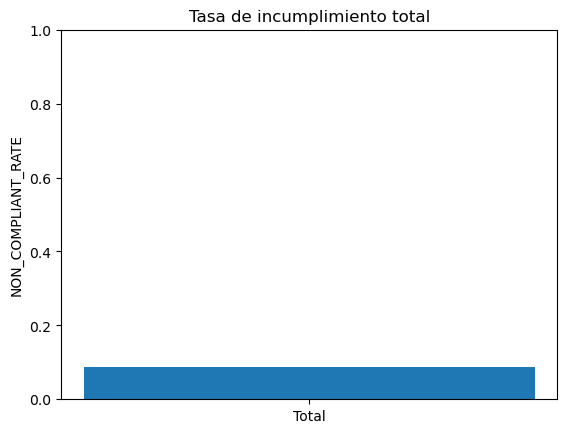

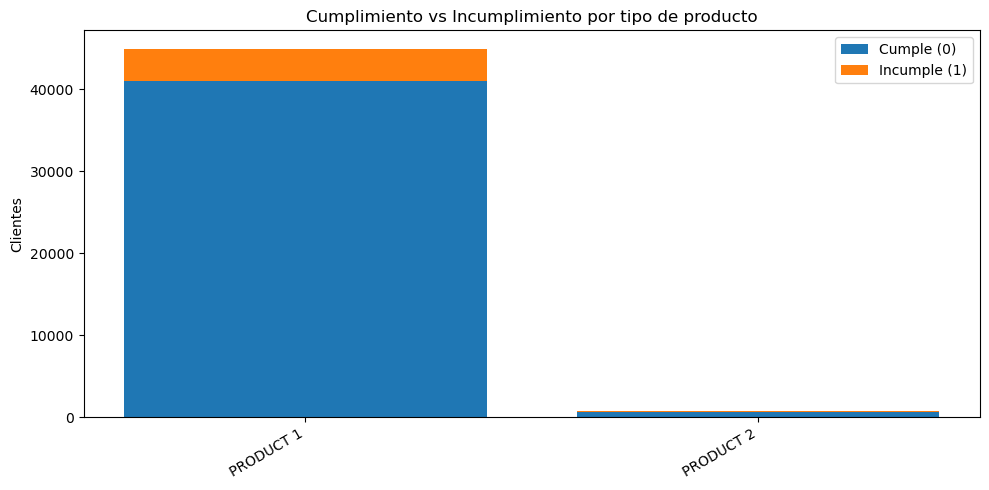

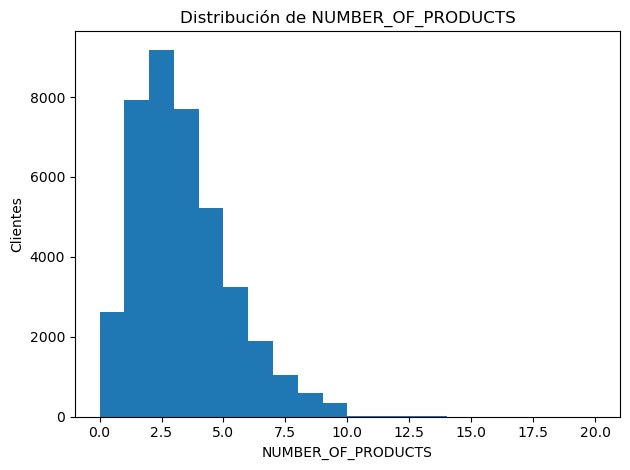

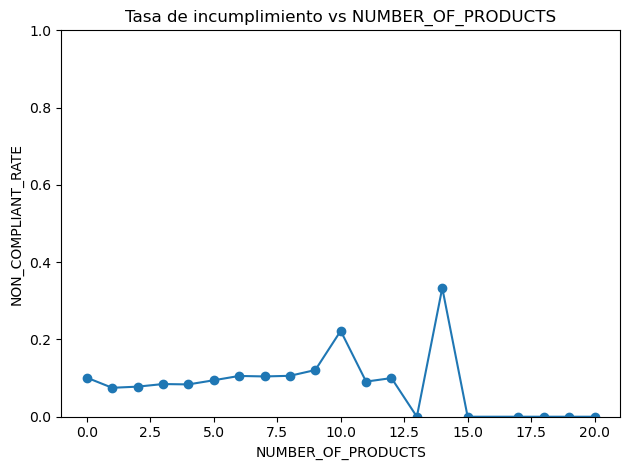

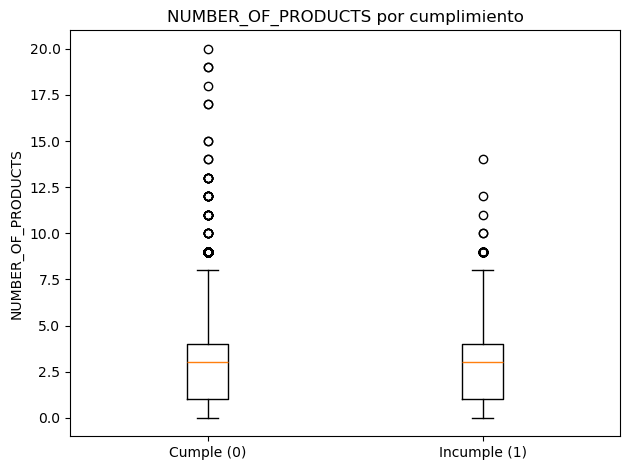

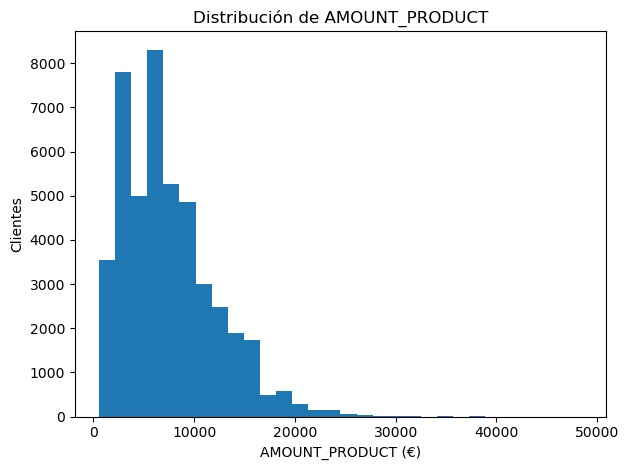

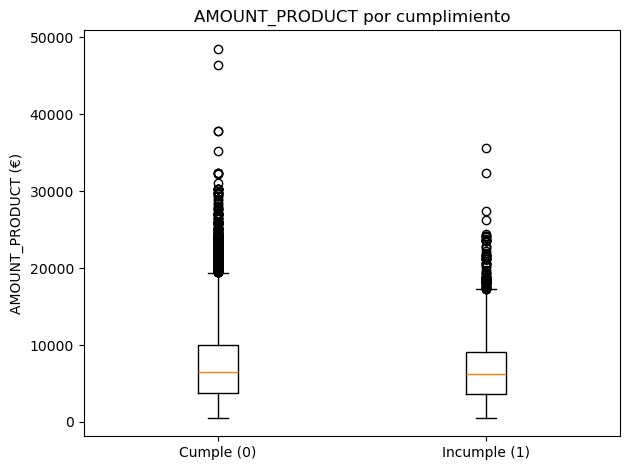

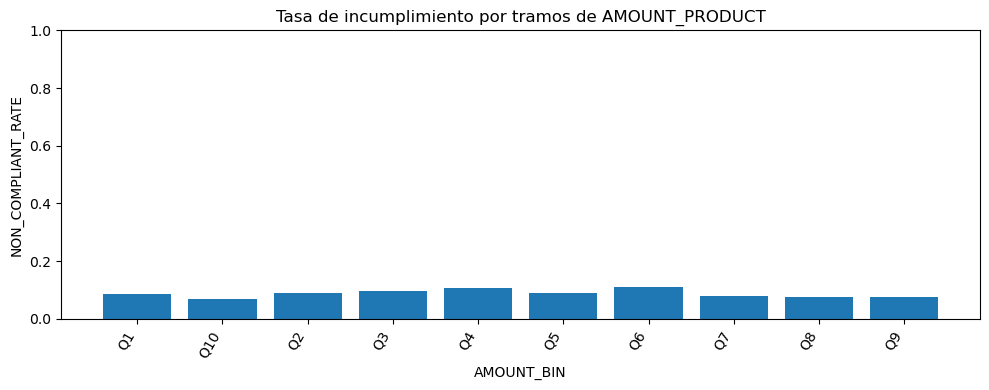

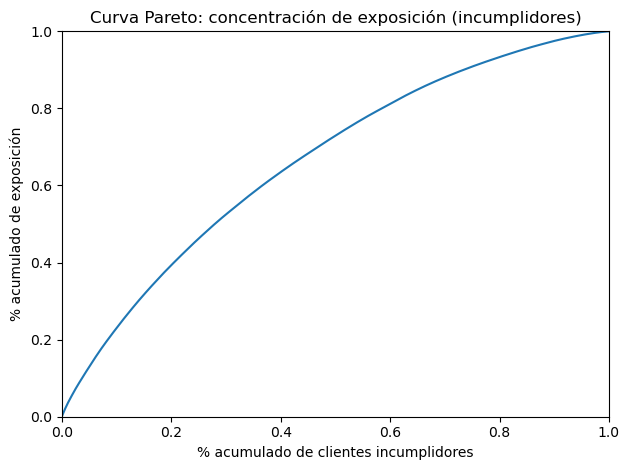

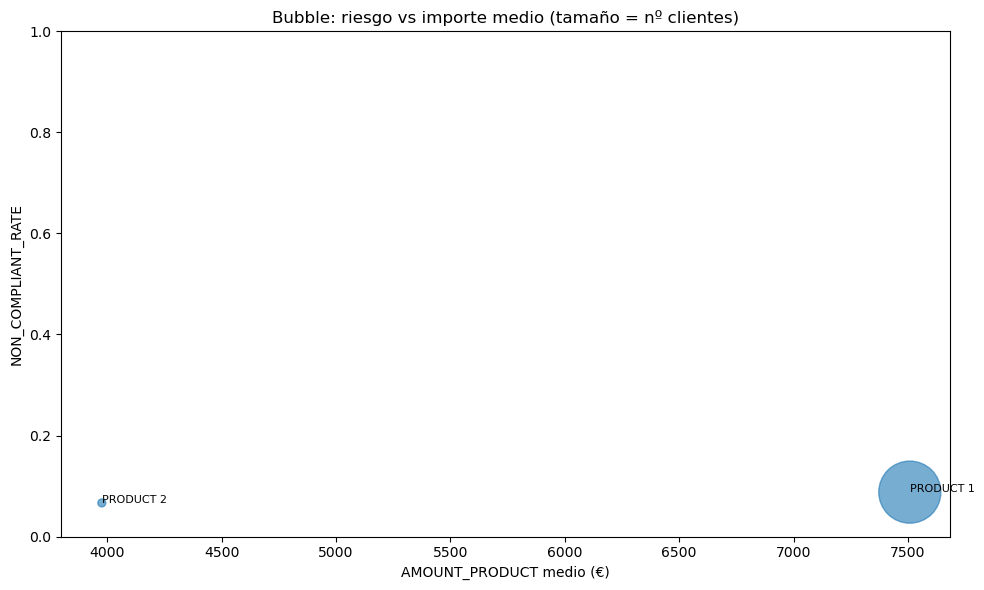

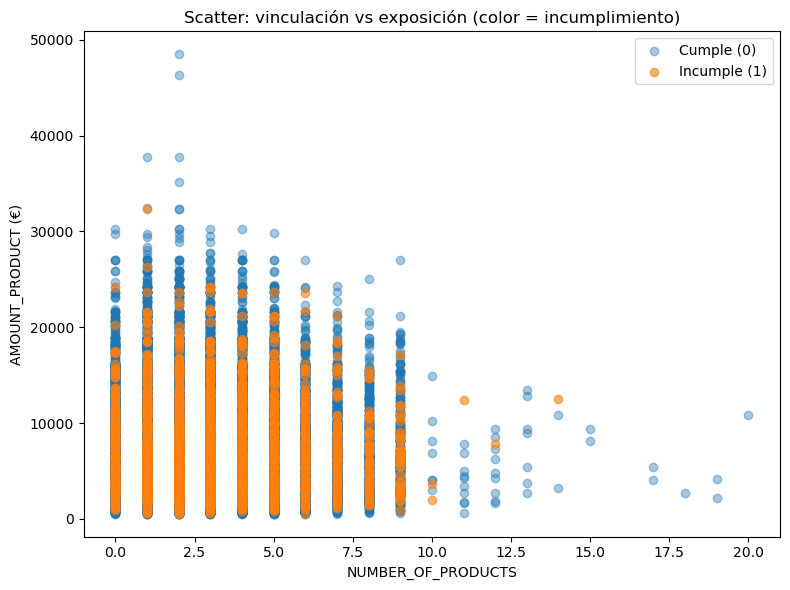

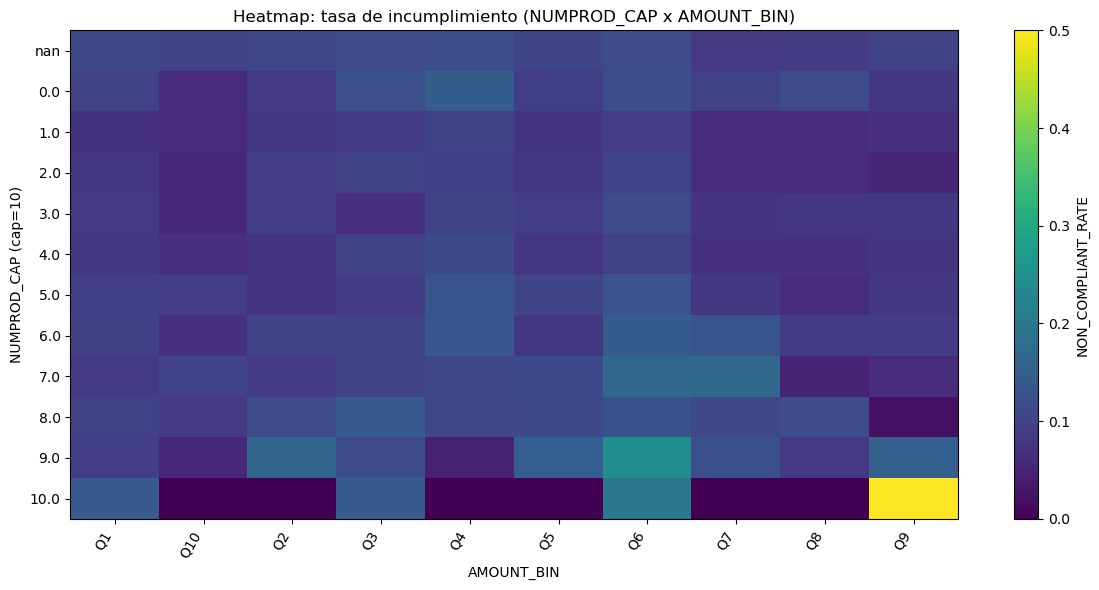


Listo: métricas calculadas y gráficos generados.


In [ ]:
# =========================
# SCRIPT COMPLETO 100% PYSPARK (plot con matplotlib -> pandas temporal)
# =========================

# -------------------------
# 1) CARGA / VALIDACIÓN
# -------------------------
df = comunes_df  # spark DataFrame

required = ["NON_COMPLIANT_CONTRACT", "NAME_PRODUCT_TYPE", "AMOUNT_PRODUCT", "NUMBER_OF_PRODUCTS"]
for c in required:
    if c not in df.columns:
        raise ValueError(f"Falta la columna: {c}")

# -------------------------
# 2) LIMPIEZA Y CASTINGS
# -------------------------
df = df.withColumn(
    "NON_COMPLIANT_CONTRACT",
    F.when(F.lower(F.col("NON_COMPLIANT_CONTRACT").cast("string"))
           .isin("1","true","t","yes","y","si","sí"), 1).otherwise(0)
)

df = df.withColumn("AMOUNT_PRODUCT", F.col("AMOUNT_PRODUCT").cast("double"))
df = df.withColumn("NUMBER_OF_PRODUCTS", F.col("NUMBER_OF_PRODUCTS").cast("int"))
df = df.withColumn("NAME_PRODUCT_TYPE", F.col("NAME_PRODUCT_TYPE").cast("string"))

# Filtrar nulos en importe
df = df.filter(F.col("AMOUNT_PRODUCT").isNotNull())

# -------------------------
# 3) BINS POR CUANTILES (10)
# -------------------------
# calcular cuantiles aproximados
quantiles = df.approxQuantile("AMOUNT_PRODUCT", [i/10 for i in range(11)], 0.001)

# función para asignar decil
def amount_bin_expr(col):
    expr = None
    # build chained when expressions
    for i in range(1, 10):
        q = quantiles[i]
        label = f"Q{i}"
        if expr is None:
            expr = F.when(col <= q, label)
        else:
            expr = expr.when(col <= q, label)
    expr = expr.otherwise("Q10")
    return expr

df = df.withColumn("AMOUNT_BIN", amount_bin_expr(F.col("AMOUNT_PRODUCT")))

# Cap de número de productos
df = df.withColumn("NUMPROD_CAP", F.when(F.col("NUMBER_OF_PRODUCTS") > 10, 10).otherwise(F.col("NUMBER_OF_PRODUCTS")))

# -------------------------
# 4) KPIs RESUMEN
# -------------------------
n_clients = df.count()
noncomp_rate = df.agg(F.mean("NON_COMPLIANT_CONTRACT")).first()[0] or 0.0
exposure_total = df.agg(F.sum("AMOUNT_PRODUCT")).first()[0] or 0.0
exposure_noncomp = df.filter(F.col("NON_COMPLIANT_CONTRACT") == 1).agg(F.sum("AMOUNT_PRODUCT")).first()[0] or 0.0
amount_mean = df.agg(F.mean("AMOUNT_PRODUCT")).first()[0] or 0.0
amount_median_global = df.approxQuantile("AMOUNT_PRODUCT", [0.5], 0.001)[0] if n_clients>0 else None
numprod_mean = df.agg(F.mean("NUMBER_OF_PRODUCTS")).first()[0] or 0.0
numprod_median = df.approxQuantile("NUMBER_OF_PRODUCTS", [0.5], 0.001)[0] if n_clients>0 else None

print("=== KPIs ===")
print("Clientes:", n_clients)
print("Tasa incumplimiento:", round(noncomp_rate, 4))
print("Exposición total (€):", round(exposure_total, 2))
print("Exposición incumplidores (€):", round(exposure_noncomp, 2))
print("Importe medio (€):", round(amount_mean, 2))
print("Importe mediana (€):", round(amount_median_global, 2) if amount_median_global is not None else None)
print("Num productos medio:", round(numprod_mean, 2))
print("Num productos mediana:", round(numprod_median, 2) if numprod_median is not None else None)

# -------------------------
# 5) TABLAS (por producto, número productos, tramos)
# -------------------------
by_product = df.groupBy("NAME_PRODUCT_TYPE").agg(
    F.count("*").alias("n_clients"),
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate"),
    F.mean("AMOUNT_PRODUCT").alias("amount_mean"),
    F.expr("percentile_approx(AMOUNT_PRODUCT, 0.5)").alias("amount_median")
).orderBy(F.col("non_compliant_rate").desc())

by_numprod = df.groupBy("NUMBER_OF_PRODUCTS").agg(
    F.count("*").alias("n_clients"),
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate"),
    F.mean("AMOUNT_PRODUCT").alias("amount_mean")
).orderBy("NUMBER_OF_PRODUCTS")

by_amountbin = df.groupBy("AMOUNT_BIN").agg(
    F.count("*").alias("n_clients"),
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate"),
    F.mean("AMOUNT_PRODUCT").alias("amount_mean")
).orderBy("AMOUNT_BIN")

# Mostrar resumenes (opcional)
print("\n=== Incumplimiento por producto (top) ===")
by_product.show(20, truncate=False)
print("\n=== Incumplimiento por NUMBER_OF_PRODUCTS ===")
by_numprod.show(50, truncate=False)
print("\n=== Incumplimiento por AMOUNT_BIN ===")
by_amountbin.show(50, truncate=False)

# -------------------------
# 6) PLOTS: convertimos a pandas solo para pintar
# -------------------------

# 6.1 Bar: tasa incumplimiento total
plt.figure()
plt.bar(["Total"], [noncomp_rate])
plt.title("Tasa de incumplimiento total")
plt.ylabel("NON_COMPLIANT_RATE")
plt.ylim(0, 1)
plt.show()

# 6.2 Barras apiladas: cumplimiento vs incumplimiento por producto
pdf_ct = df.groupBy("NAME_PRODUCT_TYPE", "NON_COMPLIANT_CONTRACT").count().toPandas()
# pivot similar a crosstab normalize index
pivot_ct = pdf_ct.pivot_table(index="NAME_PRODUCT_TYPE", columns="NON_COMPLIANT_CONTRACT", values="count", fill_value=0)
# aseguramos ambas columnas 0 y 1
if 0 not in pivot_ct.columns: pivot_ct[0] = 0
if 1 not in pivot_ct.columns: pivot_ct[1] = 0
pivot_ct = pivot_ct[[0,1]]
labels = pivot_ct.index.tolist()
cumple = pivot_ct[0].values
incumple = pivot_ct[1].values

plt.figure(figsize=(10,5))
plt.bar(labels, cumple, label="Cumple (0)")
plt.bar(labels, incumple, bottom=cumple, label="Incumple (1)")
plt.title("Cumplimiento vs Incumplimiento por tipo de producto")
plt.ylabel("Clientes")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

# 6.3 Histogram: NUMBER_OF_PRODUCTS
pdf_numprod = df.select("NUMBER_OF_PRODUCTS").toPandas()
plt.figure()
plt.hist(pdf_numprod["NUMBER_OF_PRODUCTS"].dropna(), bins=20)
plt.title("Distribución de NUMBER_OF_PRODUCTS")
plt.xlabel("NUMBER_OF_PRODUCTS")
plt.ylabel("Clientes")
plt.tight_layout()
plt.show()

# 6.4 Line plot: incumplimiento vs número de productos
pdf_by_numprod = by_numprod.toPandas().set_index("NUMBER_OF_PRODUCTS")
plt.figure()
plt.plot(pdf_by_numprod.index, pdf_by_numprod["non_compliant_rate"], marker="o")
plt.title("Tasa de incumplimiento vs NUMBER_OF_PRODUCTS")
plt.xlabel("NUMBER_OF_PRODUCTS")
plt.ylabel("NON_COMPLIANT_RATE")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# 6.5 Boxplot: NUMBER_OF_PRODUCTS por cumplimiento
pdf_np = df.select("NON_COMPLIANT_CONTRACT", "NUMBER_OF_PRODUCTS").toPandas()
data_np = [
    pdf_np.loc[pdf_np["NON_COMPLIANT_CONTRACT"] == 0, "NUMBER_OF_PRODUCTS"].dropna(),
    pdf_np.loc[pdf_np["NON_COMPLIANT_CONTRACT"] == 1, "NUMBER_OF_PRODUCTS"].dropna()
]
plt.figure()
plt.boxplot(data_np, labels=["Cumple (0)", "Incumple (1)"])
plt.title("NUMBER_OF_PRODUCTS por cumplimiento")
plt.ylabel("NUMBER_OF_PRODUCTS")
plt.tight_layout()
plt.show()

# 6.6 Histogram: AMOUNT_PRODUCT
pdf_amount = df.select("AMOUNT_PRODUCT").toPandas()
plt.figure()
plt.hist(pdf_amount["AMOUNT_PRODUCT"].dropna(), bins=30)
plt.title("Distribución de AMOUNT_PRODUCT")
plt.xlabel("AMOUNT_PRODUCT (€)")
plt.ylabel("Clientes")
plt.tight_layout()
plt.show()

# 6.7 Boxplot: AMOUNT_PRODUCT por cumplimiento
pdf_amt = df.select("NON_COMPLIANT_CONTRACT", "AMOUNT_PRODUCT").toPandas()
data_amt = [
    pdf_amt.loc[pdf_amt["NON_COMPLIANT_CONTRACT"] == 0, "AMOUNT_PRODUCT"].dropna(),
    pdf_amt.loc[pdf_amt["NON_COMPLIANT_CONTRACT"] == 1, "AMOUNT_PRODUCT"].dropna()
]
plt.figure()
plt.boxplot(data_amt, labels=["Cumple (0)", "Incumple (1)"])
plt.title("AMOUNT_PRODUCT por cumplimiento")
plt.ylabel("AMOUNT_PRODUCT (€)")
plt.tight_layout()
plt.show()

# 6.8 Bar: incumplimiento por tramos de importe (AMOUNT_BIN)
pdf_by_amountbin = by_amountbin.toPandas().set_index("AMOUNT_BIN").sort_index()
plt.figure(figsize=(10,4))
plt.bar(pdf_by_amountbin.index.astype(str), pdf_by_amountbin["non_compliant_rate"].values)
plt.title("Tasa de incumplimiento por tramos de AMOUNT_PRODUCT")
plt.xlabel("AMOUNT_BIN")
plt.ylabel("NON_COMPLIANT_RATE")
plt.ylim(0,1)
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# 6.9 Pareto: exposición de incumplidores (concentración)
pdf_non = df.filter(F.col("NON_COMPLIANT_CONTRACT") == 1).select("AMOUNT_PRODUCT").toPandas()
if len(pdf_non) > 0:
    pdf_non = pdf_non.sort_values("AMOUNT_PRODUCT", ascending=False).reset_index(drop=True)
    pdf_non["cum_exposure_share"] = pdf_non["AMOUNT_PRODUCT"].cumsum() / pdf_non["AMOUNT_PRODUCT"].sum()
    pdf_non["cum_clients_share"] = (np.arange(1, len(pdf_non) + 1) / len(pdf_non))
    plt.figure()
    plt.plot(pdf_non["cum_clients_share"], pdf_non["cum_exposure_share"])
    plt.title("Curva Pareto: concentración de exposición (incumplidores)")
    plt.xlabel("% acumulado de clientes incumplidores")
    plt.ylabel("% acumulado de exposición")
    plt.ylim(0,1)
    plt.xlim(0,1)
    plt.tight_layout()
    plt.show()
else:
    plt.figure()
    plt.text(0.1, 0.5, "No hay incumplidores en los datos")
    plt.title("Pareto exposición (incumplidores)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# 6.10 Bubble chart: producto (importe medio vs riesgo, tamaño=nº clientes)
pdf_bp = by_product.toPandas().set_index("NAME_PRODUCT_TYPE")
x = pdf_bp["amount_mean"].values
y = pdf_bp["non_compliant_rate"].values
n_clients_vals = pdf_bp["n_clients"].values
sizes = (n_clients_vals / n_clients_vals.max()) * 2000 if n_clients_vals.max() > 0 else np.ones_like(n_clients_vals)*100
labels = pdf_bp.index.tolist()

plt.figure(figsize=(10,6))
plt.scatter(x, y, s=sizes, alpha=0.6)
for i, lab in enumerate(labels):
    plt.text(x[i], y[i], lab, fontsize=8)
plt.title("Bubble: riesgo vs importe medio (tamaño = nº clientes)")
plt.xlabel("AMOUNT_PRODUCT medio (€)")
plt.ylabel("NON_COMPLIANT_RATE")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

# 6.11 Scatter: NUMBER_OF_PRODUCTS vs AMOUNT_PRODUCT, coloreado por incumplimiento
pdf_scatter = df.select("NUMBER_OF_PRODUCTS", "AMOUNT_PRODUCT", "NON_COMPLIANT_CONTRACT").toPandas()
plt.figure(figsize=(8,6))
mask0 = pdf_scatter["NON_COMPLIANT_CONTRACT"] == 0
mask1 = pdf_scatter["NON_COMPLIANT_CONTRACT"] == 1
plt.scatter(pdf_scatter.loc[mask0, "NUMBER_OF_PRODUCTS"], pdf_scatter.loc[mask0, "AMOUNT_PRODUCT"], alpha=0.4, label="Cumple (0)")
plt.scatter(pdf_scatter.loc[mask1, "NUMBER_OF_PRODUCTS"], pdf_scatter.loc[mask1, "AMOUNT_PRODUCT"], alpha=0.6, label="Incumple (1)")
plt.title("Scatter: vinculación vs exposición (color = incumplimiento)")
plt.xlabel("NUMBER_OF_PRODUCTS")
plt.ylabel("AMOUNT_PRODUCT (€)")
plt.legend()
plt.tight_layout()
plt.show()

# 6.12 Heatmap: tasa de incumplimiento vs (NUMPROD_CAP x AMOUNT_BIN)
# Creamos pivot en pandas porque matplolib usa matrices
pdf_pivot = df.groupBy("NUMPROD_CAP", "AMOUNT_BIN").agg(
    F.mean("NON_COMPLIANT_CONTRACT").alias("non_compliant_rate")
).toPandas()

if not pdf_pivot.empty:
    pivot_table = pdf_pivot.pivot(index="NUMPROD_CAP", columns="AMOUNT_BIN", values="non_compliant_rate").fillna(0)
    plt.figure(figsize=(12,6))
    plt.imshow(pivot_table.values, aspect="auto", interpolation='nearest')
    plt.title("Heatmap: tasa de incumplimiento (NUMPROD_CAP x AMOUNT_BIN)")
    plt.xlabel("AMOUNT_BIN")
    plt.ylabel("NUMPROD_CAP (cap=10)")
    plt.xticks(ticks=np.arange(pivot_table.shape[1]), labels=pivot_table.columns, rotation=60, ha="right")
    plt.yticks(ticks=np.arange(pivot_table.shape[0]), labels=pivot_table.index)
    plt.colorbar(label="NON_COMPLIANT_RATE")
    plt.tight_layout()
    plt.show()
else:
    plt.figure()
    plt.text(0.1,0.5,"No hay datos para heatmap")
    plt.axis("off")
    plt.show()

print("\nListo: métricas calculadas y gráficos generados.")